# 0. Installing the libraries

In [0]:
!pip install --upgrade pip

  Using cached pip-25.1.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 21.2.4
    Uninstalling pip-21.2.4:
      Successfully uninstalled pip-21.2.4


In [0]:
!pip install gdown cartopy geopandas tqdm load_dotenv --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scipy 1.7.3 requires numpy<1.23.0,>=1.16.5, but you have numpy 2.0.2 which is incompatible.


In [0]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import pandas as pd
import numpy as np
from tqdm import tqdm
from dotenv import load_dotenv
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [0]:
import pyspark

#1.  Downloading Data from Drive

In [0]:
# these are the outputs of sections below. I could not figure out a way to add those in the Databricks markdown cell.
# so, instead, will use matplotlib to show the image directly
# I originally added screenshots to markdown cell as I did pyspark on my computer. But, moving those photos from markdown cells while running  on databricks was trickly. So, I uploaded those to drive and will include those screenshots using matplotlib.
!gdown '1n52Ik_3cJnZUKGBCHlo1cBeRGvexn-57'
!gdown '1JZkHrMdcrVSgRzKXwVH1H8Cm5-Z5p1Zo'
!gdown '1ZxZ-7TpXj1GG4d1wiOX-yI-nK2XvcXMh'
!gdown '1kCqeHRbgA8A92BQTG0T-Q7f3RRyHW8F-'
!gdown '1k6Che0KdcZVSHPPsPch292ktw6jMNV_i'
!gdown '1GWlcaMgkN2iA1k6kzCkh0ezOnHMKgwiL'
!gdown '1H9k8nphn9U815mkS45UGFjOX531bzSl4'

Downloading...
From: https://drive.google.com/uc?id=1n52Ik_3cJnZUKGBCHlo1cBeRGvexn-57
To: /databricks/driver/1.png
100%|████████████████████████████████████████| 115k/115k [00:00<00:00, 5.70MB/s]
Downloading...
From: https://drive.google.com/uc?id=1JZkHrMdcrVSgRzKXwVH1H8Cm5-Z5p1Zo
To: /databricks/driver/2.png
100%|████████████████████████████████████████| 245k/245k [00:00<00:00, 11.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1ZxZ-7TpXj1GG4d1wiOX-yI-nK2XvcXMh
To: /databricks/driver/3.png
100%|████████████████████████████████████████| 634k/634k [00:00<00:00, 13.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1kCqeHRbgA8A92BQTG0T-Q7f3RRyHW8F-
To: /databricks/driver/4.png
100%|██████████████████████████████████████| 55.4k/55.4k [00:00<00:00, 51.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1k6Che0KdcZVSHPPsPch292ktw6jMNV_i
To: /databricks/driver/5.png
100%|████████████████████████████████████████| 192k/192k [00:00<00:00, 9.24MB/s]
Downloading...
From:

In [0]:
spark

SparkSession - hive 
 
 
 SparkContext 

 Spark UI 

 
 Version 
 v3.3.2 
 Master 
 local[8] 
 AppName 
 Databricks Shell

In [0]:
spark.sparkContext.defaultParallelism

Out[7]: 8

# 2. Preparing NO2 Data

For NO2 data, I will be using OMI NO2 from NASA. This dataset is daily-level ar roughly 0.1deg * 0.1deg resolution. OMI instrument present in a satellite orbits the Earth 14 to 15 times a day and calculate NO2 vertical column density. Vertical Column Density or VCD refers to the total amount of NO2 molecules present from earth surface to the top of the atmosphere. NO2 pollution would be in tons that can be calculated from surface concentrations (NO2 molecules present on earth surface). This can be done using ground based sensors from EPA or PANDORA. 

Even though the data I am using is vertical columns, it still is a very good indicator of NO2 pollution. It is satellite-based data, which means we can do global-level data analysis and evaluation. Besides, the presence of sensors is very scarce and it is not possible to place ground-based sensors throughout the world. That's where satellite-based evaluation come in handy.

<b> Higher OMI NO2 VCD indicates more NO2 emissions from burning of fuel (cars), industries, etc. Furthermore, NO2 irritates the airways in our lungs and nose, causing inflammation and swelling, and is one of the top pollutants to cause respiratory disease like Asthma</b>

I wil be using `OMI_MINDS_NO2` dataset from NASA. You can find more about it from the following link: https://disc.gsfc.nasa.gov/datasets/OMI_MINDS_NO2_1.1/summary?keywords=OMI_MINDS_NO2_1.1


This data is also available on S3. I will be reading the files directly from S3. 

<b> I will comment the code of this section because you will need to generate NASA's earthdata token to access the data from S3. I have included the code which you can run to get this data.

In [0]:
# load_dotenv()

In [0]:
# '''
# This is how we can fetch temporary credentials from NASA's Earthdata to access AWS S3 bucket.
# These expire after 1 hour. And, you need an active earthdata account to get the credentials.
# This code is present on NASA's website:

# https://archive.podaac.earthdata.nasa.gov/s3credentialsREADME
# '''

# s3_endpoint = "https://data.gesdisc.earthdata.nasa.gov/s3credentials"
# username = os.getenv("EARTHDATA_USERNAME")
# password = os.getenv("EARTHDATA_PASSWORD")


# login_resp = requests.get(s3_endpoint, allow_redirects=False)
# login_resp.raise_for_status()

# auth = f"{username}:{password}"
# encoded_auth = base64.b64encode(auth.encode('ascii'))

# auth_redirect = requests.post(
#     login_resp.headers['location'],
#     data={"credentials": encoded_auth},
#     headers={"Origin": s3_endpoint},
#     allow_redirects=False
# )
# auth_redirect.raise_for_status()

# final = requests.get(auth_redirect.headers['location'], allow_redirects=False)
# final.raise_for_status()

# results = requests.get(s3_endpoint, cookies={'accessToken': final.cookies['accessToken']})
# results.raise_for_status()

# creds = json.loads(results.content)

In [0]:
# # creating s3fs object to access the bucket using the retrieved temporaty credentials
# s3_fs = s3fs.S3FileSystem(
#         key = creds['accessKeyId'],
#         secret = creds['secretAccessKey'],
#         token = creds['sessionToken'],
#     )

In [0]:
# '''
# The name of the S3 bucket that contains OMI NO2 data is gesdisc-cumulus-prod-protected.
# Let's quickly test if we can connect to the bucket or not.
# '''

# try:
#     files = s3_fs.ls("s3://gesdisc-cumulus-prod-protected")
#     print("Connection successful! Files found:")
# except Exception as e:
#     print(f"Connection failed: {e}")

We have set up our s3fs object and connected it to NASA's s3 bucket. Next thing will be to go on the NASA GESC DISC website and get the text file containing links to the s3 files for OMI NO2 from 2018 to 2022. The data is present inside `gesdisc-cumulus-prod-protected` bucket.

We can directly stream the data object into our RAM using `Xarray` python library. 

In [0]:
# ''''
# These are the S3 links to OMI NO2 data files from year 2018 to 2022. I got this from NASA's GESC DISC.
# You can get these links from the following URL:

# https://disc.gsfc.nasa.gov/datasets/OMI_MINDS_NO2_1.1/summary?keywords=OMI_MINDS_NO2_1.1
# '''

# with open("OMI_NO2_S3_Links.txt", "r") as file:
#     omi_no2_links = file.readlines()

# omi_no2_links = [line.strip() for line in omi_no2_links]
# omi_no2_links = [link for link in omi_no2_links if link.endswith(".nc")]
# print("TOTAL NUMBER OF FILES IS: ", len(omi_no2_links))
# omi_no2_links[:10]

Each file is roughly ~10mb in size (some can be larger and some can be smaller). With 23084 files, the total data size that we will be streaming will be ~250 GB. However, these files contain global data and we will filter data only for the US bounding cordinates. 

In [0]:
def is_over_us_state(lat: np.array, lon: np.array):
    """Returns True if (lat, lon) is inside any of the 50 US states (excluding territories)."""
    
    # Continental U.S. (CON 48 states)
    conus = (
        (24.5 <= lat <= 49.5) &  
        (-125.0 <= lon <= -66.95)  
    )
    
    # Alaska 
    alaska = (
        (51.0 <= lat <= 71.4) &  
        ((-170.0 <= lon <= -129.9)) 
    )
    
    # Hawaii
    hawaii = (
        (17.9 <= lat <= 26) &  
        (-162.0 <= lon <= -154.5)  
    )
    
    return conus | alaska | hawaii


In [0]:
# global_latitude = []
# global_longitude = []
# global_ColumnAmountNO2 = []
# global_cloudFraction = []
# global_LAT1 = []
# global_LAT2 = []
# global_LAT3 = []
# global_LAT4 = []
# global_LON1 = []
# global_LON2 = []
# global_LON3 = []
# global_LON4 = []
# global_date = []

# for current_file in tqdm(omi_no2_links[:30]):
#     with s3_fs.open(current_file, mode="rb") as f:
#         dataset = nc.Dataset("in-memory.nc", memory=f.read())

#     filename = os.path.basename(current_file)
#     date = filename.split("OMI-Aura_L2-OMI_MINDS_NO2_")[1][:9]
#     ColumnAmountNO2 = dataset.groups["SCIENCE_DATA"]["ColumnAmountNO2"][:].filled(np.nan).reshape(-1)
#     cloudFraction = dataset.groups["ANCILLARY_DATA"]["CloudFraction"][:].filled(np.nan).reshape(-1)
#     latitude = dataset.groups["GEOLOCATION_DATA"]["Latitude"][:].filled(np.nan).reshape(-1)
#     longitude = dataset.groups["GEOLOCATION_DATA"]["Longitude"][:].filled(np.nan).reshape(-1)
#     corner_latitude = dataset.groups["GEOLOCATION_DATA"]["FoV75CornerLatitude"][:].reshape(-1, 4)
#     corner_longitude = dataset.groups["GEOLOCATION_DATA"]["FoV75CornerLongitude"][:].reshape(-1, 4)
#     LAT1 = corner_latitude[:, 0]
#     LAT2 = corner_latitude[:, 1]
#     LAT3 = corner_latitude[:, 2]
#     LAT4 = corner_latitude[:, 3]
#     LON1 = corner_longitude[:, 0]
#     LON2 = corner_longitude[:, 1]
#     LON3 = corner_longitude[:, 2]
#     LON4 = corner_longitude[:, 3]
#     date = np.repeat(date, ColumnAmountNO2.shape[0])

#     boolean_mask = np.array([is_over_us_state(lat, lon) for lat, lon in zip(latitude, longitude)])

#     ColumnAmountNO2 = ColumnAmountNO2[boolean_mask]
#     cloudFraction = cloudFraction[boolean_mask]
#     latitude = latitude[boolean_mask]
#     longitude = longitude[boolean_mask]
#     LAT1 = LAT1[boolean_mask]
#     LAT2 = LAT2[boolean_mask]
#     LAT3 = LAT3[boolean_mask]
#     LAT4 = LAT4[boolean_mask]
#     LON1 = LON1[boolean_mask]
#     LON2 = LON2[boolean_mask]
#     LON3 = LON3[boolean_mask]
#     LON4 = LON4[boolean_mask]
#     date = date[boolean_mask]

#     global_latitude.extend(latitude)
#     global_longitude.extend(longitude)
#     global_ColumnAmountNO2.extend(ColumnAmountNO2)
#     global_cloudFraction.extend(cloudFraction)
#     global_LAT1.extend(LAT1)
#     global_LAT2.extend(LAT2)
#     global_LAT3.extend(LAT3)
#     global_LAT4.extend(LAT4)
#     global_LON1.extend(LON1)
#     global_LON2.extend(LON2)
#     global_LON3.extend(LON3)
#     global_LON4.extend(LON4)
#     global_date.extend(date)

#     dataset.close()

In [0]:
# global_latitude = np.array(global_latitude)
# global_longitude = np.array(global_longitude)
# global_ColumnAmountNO2 = np.array(global_ColumnAmountNO2)
# global_cloudFraction = np.array(global_cloudFraction)
# global_LAT1 = np.array(global_LAT1)
# global_LAT2 = np.array(global_LAT2)
# global_LAT3 = np.array(global_LAT3)
# global_LAT4 = np.array(global_LAT4)
# global_LON1 = np.array(global_LON1)
# global_LON2 = np.array(global_LON2)
# global_LON3 = np.array(global_LON3)
# global_LON4 = np.array(global_LON4)
# global_date = np.array(global_date)

In [0]:
# fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={"projection": ccrs.PlateCarree()})
# ax.set_extent([-180, -50, 10, 75], crs=ccrs.PlateCarree())
# ax.add_feature(cfeature.BORDERS, linestyle=':')
# ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.STATES, edgecolor='gray')

# bounding_boxes = {
#     "Continental US": [[24.5, 49.5], [-125.0, -66.95]],
#     "Alaska": [[51.0, 71.4], [-170.0, -129.9]], 
#     "Hawaii": [[17.9, 26], [-162.0, -154.5]]
# }

# for region, ((lat_min, lat_max), (lon_min, lon_max)) in bounding_boxes.items():
#     lats = [lat_min, lat_max, lat_max, lat_min, lat_min]
#     lons = [lon_min, lon_min, lon_max, lon_max, lon_min]
#     ax.plot(lons, lats, transform=ccrs.PlateCarree(), label=region)

# ax.legend()
# plt.title("US Bounding Boxes Visualization")
# plt.show()


This is how the output of the previous cell looks like:

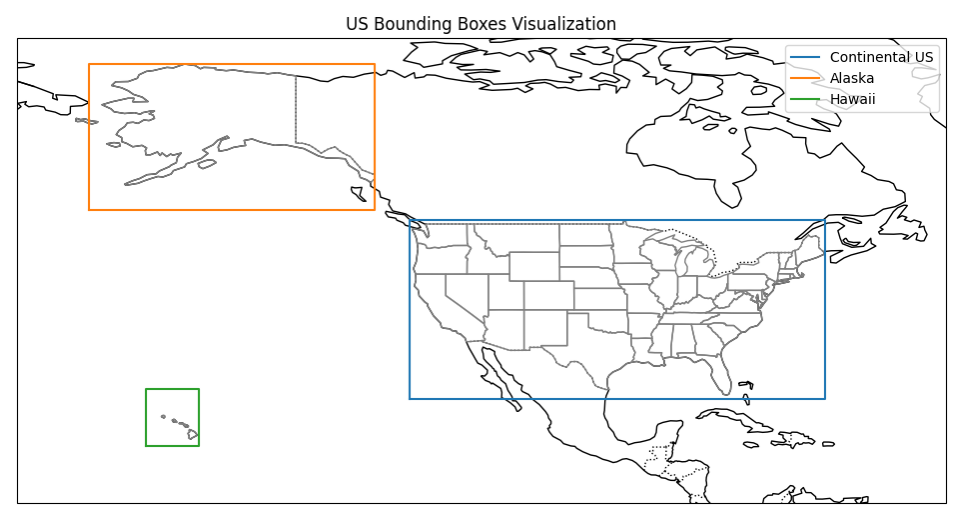

In [0]:
import matplotlib.image as mpimg

img = mpimg.imread('/databricks/driver/1.png')
plt.figure(figsize=(17, 10))
plt.imshow(img)
plt.axis('off') 
plt.show()


In [0]:
# plt.figure(figsize=(12, 6))
# ax = plt.axes(projection=ccrs.PlateCarree())
# ax.set_extent([-170, -50, 5, 85], crs=ccrs.PlateCarree()) 
# ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=0.5)
# ax.add_feature(cfeature.COASTLINE, alpha=0.5)
# scatter = ax.scatter(global_longitude, global_latitude, c=global_cloudFraction, s=1, cmap='jet', transform=ccrs.PlateCarree(), alpha=0.5)
# plt.colorbar(scatter, label='NO₂ Column Amount (molec/cm²)', orientation='vertical')
# plt.title('OMI NO₂ over US States')
# plt.show()

This is the output of our previous cell:

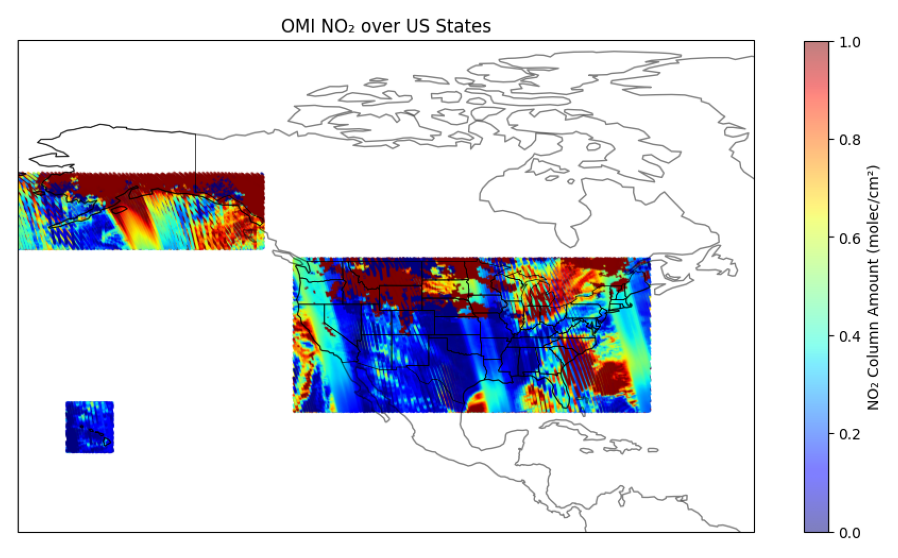

In [0]:
img = mpimg.imread('/databricks/driver/2.png')
plt.figure(figsize=(17, 10))
plt.imshow(img)
plt.axis('off') 
plt.show()

Perfect. Our bounding box and data filtration logic is valid. Lets process data files one month at a time and export them to not run out of memory.

In [0]:
# import random

# random.sample(omi_no2_links, 10)

In [0]:
# def get_s3links_for_selected_date(year: str, month:str) -> list[str]:
#     """
#     Get the S3 links for a specific year and month.
#     """
#     month_str = f"{int(month):02d}"
#     pattern = re.compile(rf'.*OMI_MINDS_NO2_{year}m{month_str}\d{{2}}t\d{{4}}.*\.nc$')
#     files = sorted([file for file in omi_no2_links if pattern.search(file)])
#     return files

In [0]:
# def process_data_monthly(year: str, month: str):
#     '''
#     Read the OMI NO2 data files for a specific month and year from S3 bucket and export it.
#     '''
#     try:
#         omi_no2_links_for_selected_YYYYMM = get_s3links_for_selected_date(year, month)
        
#         dfs = []

#         for current_file in tqdm(omi_no2_links_for_selected_YYYYMM):
#             try:
#                 with s3_fs.open(current_file, mode="rb") as f:
#                     with nc.Dataset("in-memory.nc", memory=f.read()) as dataset:
#                         filename = os.path.basename(current_file)
#                         date = filename.split("OMI-Aura_L2-OMI_MINDS_NO2_")[1][:9]
                        
#                         # Extract data
#                         ColumnAmountNO2 = dataset.groups["SCIENCE_DATA"]["ColumnAmountNO2"][:].filled(np.nan).reshape(-1)
#                         cloudFraction = dataset.groups["ANCILLARY_DATA"]["CloudFraction"][:].filled(np.nan).reshape(-1)
#                         latitude = dataset.groups["GEOLOCATION_DATA"]["Latitude"][:].filled(np.nan).reshape(-1)
#                         longitude = dataset.groups["GEOLOCATION_DATA"]["Longitude"][:].filled(np.nan).reshape(-1)
#                         corner_latitude = dataset.groups["GEOLOCATION_DATA"]["FoV75CornerLatitude"][:].reshape(-1, 4)
#                         corner_longitude = dataset.groups["GEOLOCATION_DATA"]["FoV75CornerLongitude"][:].reshape(-1, 4)
                        
#                         # Create boolean mask
#                         boolean_mask = np.array([is_over_us_state(lat, lon) for lat, lon in zip(latitude, longitude)])
                        
#                         # Filter data
#                         filtered_data = {
#                             "latitude": latitude[boolean_mask],
#                             "longitude": longitude[boolean_mask],
#                             "ColumnAmountNO2": ColumnAmountNO2[boolean_mask],
#                             "cloudFraction": cloudFraction[boolean_mask],
#                             "LAT1": corner_latitude[:, 0][boolean_mask],
#                             "LAT2": corner_latitude[:, 1][boolean_mask],
#                             "LAT3": corner_latitude[:, 2][boolean_mask],
#                             "LAT4": corner_latitude[:, 3][boolean_mask],
#                             "LON1": corner_longitude[:, 0][boolean_mask],
#                             "LON2": corner_longitude[:, 1][boolean_mask],
#                             "LON3": corner_longitude[:, 2][boolean_mask],
#                             "LON4": corner_longitude[:, 3][boolean_mask],
#                             "date": np.repeat(date, np.sum(boolean_mask))
#                         }
                        
#                         dfs.append(pd.DataFrame(filtered_data))
            
#             except Exception as e:
#                 print(f"Error processing file {current_file}: {str(e)}")
#                 continue

#         if dfs:
#             final_df = pd.concat(dfs, ignore_index=True)
#             output_path = f"omi_no2_data_{year}_{month}.parquet"
#             final_df.dropna(inplace=True)
#             final_df.reset_index(drop=True, inplace=True)
#             final_df.to_parquet(output_path)
#         else:
#             print("No valid data processed for the given month.")

#         return True 
#     except Exception as e:
#         print(f"Error processing data for {year}-{month}: {str(e)}")
#         return False

In [0]:
# from joblib import Parallel, delayed

It is taking roughly 3 minutes to process one month of data. Therefore, I will utilize joblib to parallize this process. This way, I can process data for multiple months simultaneously to reduce the total processing time. Each daily file is ~10 MB and reading though them, filtering exporting month file takes some time. Each exported monthly file is ~30MB.

In [0]:
def proces_data_in_parallel(year_selected: str, num_cores= 6):
    """
    This function will process multiple months in parallel for a given year
    """
    months = ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11", "12"]
    Parallel(n_jobs=num_cores)(delayed(process_data_monthly)(year, month) for year in [year_selected] for month in months)

In [0]:
# proces_data_in_parallel("2018")
# proces_data_in_parallel("2019")
# proces_data_in_parallel("2020")
# proces_data_in_parallel("2020")
# proces_data_in_parallel("2021")
# proces_data_in_parallel("2022")
# proces_data_in_parallel("2023")
# proces_data_in_parallel("2024")

Now, we have a file for each Year-Month which is exported as parquet file, which I will import directly in the next sections.

# 3. NO2 Pollution Analysis


After extracting the OMI NO2 data, I uploaded the csv files to create Tables to read in spark.

In [0]:
%sql
SHOW TABLES;

database,tableName,isTemporary
default,epa_2019_hourly_no2_2_csv,false
default,epa_2020_hourly_no2_1_csv,false
default,epa_2021_hourly_no2_1_csv,false
default,omi_no2_1_csv,false
default,station_data_extract_pipe_delimited_cleandata_2019_1_txt,false
default,station_data_extract_pipe_delimited_cleandata_2020_1_txt,false
default,station_data_extract_pipe_delimited_cleandata_2021_1_txt,false
default,trafficdata_2019_eastcoast_1_csv,false
default,trafficdata_2020_eastcoast_1_csv,false
default,trafficdata_2020_eastcoast_2_csv,false


In [0]:
# reading the processed OMI NO2 data
df = spark.read.table('omi_no2_1_csv')

In [0]:
df.show(10)

+---------+----------+---------------+-------------------+-------+-------+-------+-------+--------+--------+--------+--------+---------+
| latitude| longitude|ColumnAmountNO2|      cloudFraction|   LAT1|   LAT2|   LAT3|   LAT4|    LON1|    LON2|    LON3|    LON4|     date|
+---------+----------+---------------+-------------------+-------+-------+-------+-------+--------+--------+--------+--------+---------+
|35.054005|-76.120094|   3.5645533E15|              0.185|34.9601|35.0182| 35.147|35.0897|-76.2421|-75.9567|-75.9976|-76.2837|2018m0101|
|35.050556|-76.746704|    6.252209E15|              0.123|34.9518|35.0175|35.1481|35.0836|-76.8763| -76.574|-76.6165|-76.9198|2018m0101|
|35.113728| -76.44831|   5.0609135E15|               0.17|35.0175|35.0793|35.2089|35.1481| -76.574|-76.2804|-76.3222|-76.6165|2018m0101|
|35.173218| -76.15825|   1.2852143E15|0.14200000000000002|35.0793|35.1374|35.2662|35.2089|-76.2804|-75.9946|-76.0357|-76.3222|2018m0101|
|35.030117| -77.41357|   2.6264938E15|0.1

Here, latitude, longitude and their corner cordinates are geographical information that can be used to perform spatial analysis. ColumnAmountNO2 is the OMI NO2 vertical column density whereas cloudFraction refers to the percentage/fraction of sky covered with clouds at the specific cordinates. If the value of cloud fraction is large, the OMI instrument's NO2 column values will not be accurate as cloud reflects sunlight and the measurement become inaacurate. Therefore, we will later only use data where cloud fraction is less than 0.5. The higher the threshold we set, the more data we loose. 

In [0]:
df.printSchema()

root
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- ColumnAmountNO2: double (nullable = true)
 |-- cloudFraction: double (nullable = true)
 |-- LAT1: double (nullable = true)
 |-- LAT2: double (nullable = true)
 |-- LAT3: double (nullable = true)
 |-- LAT4: double (nullable = true)
 |-- LON1: double (nullable = true)
 |-- LON2: double (nullable = true)
 |-- LON3: double (nullable = true)
 |-- LON4: double (nullable = true)
 |-- date: string (nullable = true)



In [0]:
from pyspark.sql.functions import col

In [0]:
# columns_to_type_cast = df.columns
# columns_to_type_cast.remove("date")

# df = df.select([
#     col(c).cast("float").alias(c) if c in columns_to_type_cast else col(c)
#     for c in df.columns
# ])

<span style="color:red">
Spark DataFrames do not support Shapely geometry objects like Point and Polygons. Therefore, I have used GeoPandas for this. 
Wherever I need to do some spatial operation, I convert PySpark dataframe to GeoPandas DataFrame and apply the spatial operation. 
I tried to learn Sedona but, given the time constraints, I found it very difficult to learn.
</span>


In [0]:
# this is the selected east coast bounding box that will be used for analysis

min_lat = 35
max_lat = 42
min_lon = -80
max_lon = -70.5

import geopandas as gpd
from shapely.geometry import Polygon

bounding_box = Polygon([(min_lon, min_lat), (max_lon, min_lat), (max_lon, max_lat), (min_lon, max_lat)])
bounding_box = gpd.GeoDataFrame(index=[0], crs="EPSG:4326", geometry=[bounding_box])

In [0]:
!pip install osmnx --quiet

In [0]:
import osmnx as ox

'''
I will use OpenStreetMap python library to get the geometry of relevant states; This returns GeoDataFrame.
'''
maryland = ox.geocode_to_gdf("maryland, USA")[["name", "geometry"]]


states = [
    "New York",
    "New Jersey",
    "Pennsylvania",
    "Delaware",
    "Maryland",
    "Virginia",
    "West Virginia",
    "North Carolina",
    "District of Columbia" # not a state but this is also our region of interest
]


us_states = []

for state in tqdm(states):
    state_gdf = ox.geocode_to_gdf(f"{state}, USA")[["name", "geometry"]]
    us_states.append(state_gdf)

100%|██████████| 9/9 [00:00<00:00, 23.37it/s]


In [0]:
us_states = pd.concat(us_states, ignore_index=True) # concatenating GeoDataFrames for each city

In [0]:
import geopandas as gpd
from shapely.geometry import Point

In [0]:
# centroid of the major cities
cities = {
    "Baltimore": (39.2904, -76.6122),
    "Philadelphia": (39.9526, -75.1652),
    "Washington, D.C.": (38.9072, -77.0369),
    "Richmond": (37.5407, -77.4360),
    "New York City": (40.7128, -74.0060)
}

geometry = [Point(lon, lat) for lat, lon in cities.values()]
city_names = list(cities.keys())
major_cities_points = gpd.GeoDataFrame({"City": city_names}, geometry=geometry, crs="EPSG:4326")

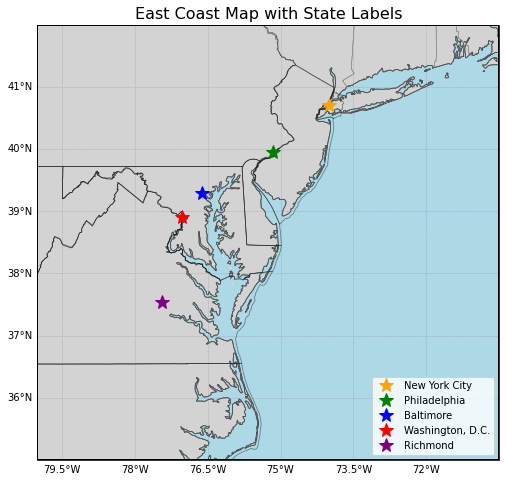

In [0]:
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=0.5)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# Plot Maryland boundary
us_states.geometry.boundary.plot(ax=ax, color='black', linewidth=0.75, alpha=0.45, transform=ccrs.PlateCarree())
bounding_box.geometry.boundary.plot(ax=ax, color='black', linewidth=2, alpha=1, transform=ccrs.PlateCarree())

colors = ['blue', 'green', 'red', 'purple', 'orange']
for color, (idx, row) in zip(colors, major_cities_points.iterrows()):
    ax.plot(row.geometry.x, row.geometry.y, marker='*', markersize=15, color=color, alpha=1,
            transform=ccrs.PlateCarree())

from matplotlib.lines import Line2D
city_handles = [
    Line2D([0], [0], marker='*', linestyle='None', markerfacecolor='orange',
              markeredgecolor='orange', label='New York City', markersize=15),

    Line2D([0], [0], marker='*', linestyle='None', markerfacecolor='green',
           markeredgecolor='green', label='Philadelphia', markersize=15),
        
    Line2D([0], [0], marker='*', linestyle='None', markerfacecolor='blue',
           markeredgecolor='blue', label='Baltimore', markersize=15),
    
    Line2D([0], [0], marker='*', linestyle='None', markerfacecolor='red',
           markeredgecolor='red', label='Washington, D.C.', markersize=15),
    Line2D([0], [0], marker='*', linestyle='None', markerfacecolor='purple',
           markeredgecolor='purple', label='Richmond', markersize=15),

]
ax.legend(handles=city_handles, loc='lower right', fontsize=10, frameon=True)
plt.title("East Coast Map with State Labels", fontsize=16)
plt.show()

In [0]:
# selecting data only for our bounding box and filtering based on cloud fraction
df = df.filter(
    (col("longitude") >= min_lon) & 
    (col("longitude") <= max_lon) & 
    (col("latitude") >= min_lat) & 
    (col("latitude") <= max_lat) &
    (col("ColumnAmountNO2") > 0) &
    (col("cloudFraction") < 0.3) 
)

In [0]:
df.show(1)

+---------+----------+---------------+-------------+-------+-------+------+-------+--------+--------+--------+--------+---------+
| latitude| longitude|ColumnAmountNO2|cloudFraction|   LAT1|   LAT2|  LAT3|   LAT4|    LON1|    LON2|    LON3|    LON4|     date|
+---------+----------+---------------+-------------+-------+-------+------+-------+--------+--------+--------+--------+---------+
|35.054005|-76.120094|   3.5645533E15|        0.185|34.9601|35.0182|35.147|35.0897|-76.2421|-75.9567|-75.9976|-76.2837|2018m0101|
+---------+----------+---------------+-------------+-------+-------+------+-------+--------+--------+--------+--------+---------+
only showing top 1 row



<b> The reason I only kept data with cloud Fraction less than 0.3 represents the quality of data. Each OMI pixel is roughly 10km*10km in resolution. Cloud Fraction represents the percentage of the pixel that is covered with cloud. Cloud reflect light and make satellite measurements unreliable if a pixel is covered a lot by a cloud. Therefore, I only kept rows where the fraction of cloud covering the data pixel is very very low.

In [0]:
df.show(10)

+---------+----------+---------------+-------------------+-------+-------+-------+-------+--------+--------+--------+--------+---------+
| latitude| longitude|ColumnAmountNO2|      cloudFraction|   LAT1|   LAT2|   LAT3|   LAT4|    LON1|    LON2|    LON3|    LON4|     date|
+---------+----------+---------------+-------------------+-------+-------+-------+-------+--------+--------+--------+--------+---------+
|35.054005|-76.120094|   3.5645533E15|              0.185|34.9601|35.0182| 35.147|35.0897|-76.2421|-75.9567|-75.9976|-76.2837|2018m0101|
|35.050556|-76.746704|    6.252209E15|              0.123|34.9518|35.0175|35.1481|35.0836|-76.8763| -76.574|-76.6165|-76.9198|2018m0101|
|35.113728| -76.44831|   5.0609135E15|               0.17|35.0175|35.0793|35.2089|35.1481| -76.574|-76.2804|-76.3222|-76.6165|2018m0101|
|35.173218| -76.15825|   1.2852143E15|0.14200000000000002|35.0793|35.1374|35.2662|35.2089|-76.2804|-75.9946|-76.0357|-76.3222|2018m0101|
|35.030117| -77.41357|   2.6264938E15|0.1

The LAT1 LON1 etc features are essentially the OMI Pixel and latitude and longitude are the centroid of this. We can parse date to do timeseries data analysis for OMI NO2 pollution.

In [0]:
print("TOTAL NUMBER OF ROWS AVAILABLE: ", df.count())

TOTAL NUMBER OF ROWS AVAILABLE:  933312


So, these are our columns. Lets look at the distribution our  column that is our main focus.

In [0]:
df.select("cloudFraction").describe().show()

+-------+-------------------+
|summary|      cloudFraction|
+-------+-------------------+
|  count|             933312|
|   mean|0.09811864199753784|
| stddev|0.08331198059463894|
|    min|                0.0|
|    max|              0.299|
+-------+-------------------+



As we can see, the maximum cloud fraction available is 0.299. This is because we clipped it to 0.3. Let's also look at the distribution of ColumnAmountNO2.

In [0]:
df.select("ColumnAmountNO2").describe().show()

+-------+--------------------+
|summary|     ColumnAmountNO2|
+-------+--------------------+
|  count|              933312|
|   mean|4.866154761742149E15|
| stddev|2.344924333198933E15|
|    min|       1.08984795E11|
|    max|         7.785857E16|
+-------+--------------------+



ColumnAmountNO2 essentially represents the number of NO2 molecules from ground to the top of the atmosphere. So, there will be lots and lots of NO2 molecues at scales of 10 power 16. Lets look at the histogram of this column to better understand this.

In [0]:
ColumnAmountNO2_array  = df.select("ColumnAmountNO2").toPandas().values.flatten()

In [0]:
ColumnAmountNO2_array

Out[46]: array([3.5645533e+15, 6.2522090e+15, 5.0609135e+15, ..., 5.2203440e+15,
       4.6871053e+15, 4.8700280e+15])

In [0]:
from matplotlib import ticker

formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True) 
formatter.set_powerlimits((-1,0)) 

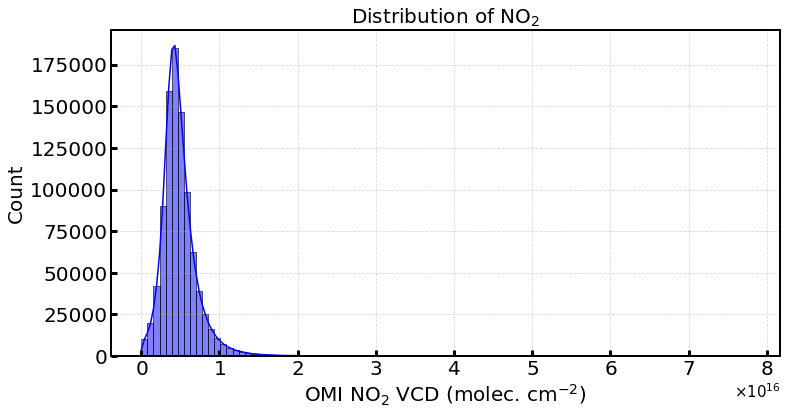

In [0]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(ColumnAmountNO2_array, bins=100, kde=True, color='blue', ax=ax)
plt.title("Distribution of NO$_2$", fontsize=20)
ax.tick_params(labelsize=20)
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_color('black') 
ax.spines['right'].set_color('black')
ax.spines['right'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_color('black')
ax.spines['left'].set_lw(2) 
ax.tick_params(which='both', width=3)
ax.tick_params(which='major', length=6)
ax.tick_params(which='minor', length=6)
ax.tick_params(which = 'both', direction = 'in')
ax.set_ylabel("Count", fontsize=20)
ax.set_xlabel("OMI NO$_2$ VCD (molec. $\mathregular{cm^{-2}}$)", fontsize=20)
ax.xaxis.set_major_formatter(formatter)
ax.ticklabel_format(style='scientific', axis = 'x') 
t = ax.xaxis.get_offset_text()
t.set_size(15)
ax.grid(True, linestyle="--", alpha=0.5)
plt.show()

Well, the NO2 being extremely skewed to the right makes sense as extremely populated places will have high NO2 and there are much more less polluted regions.

In [0]:
from pyspark.sql.functions import to_date, regexp_replace

# Fix date format from "2018m0101" to "20180101" then to date format
df = df.withColumn("date", to_date(regexp_replace("date", "m", ""), "yyyyMMdd"))

In [0]:
df.select("date").show(10)

+----------+
|      date|
+----------+
|2018-01-01|
|2018-01-01|
|2018-01-01|
|2018-01-01|
|2018-01-01|
|2018-01-01|
|2018-01-01|
|2018-01-01|
|2018-01-01|
|2018-01-01|
+----------+
only showing top 10 rows



In [0]:
df.printSchema()

root
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- ColumnAmountNO2: double (nullable = true)
 |-- cloudFraction: double (nullable = true)
 |-- LAT1: double (nullable = true)
 |-- LAT2: double (nullable = true)
 |-- LAT3: double (nullable = true)
 |-- LAT4: double (nullable = true)
 |-- LON1: double (nullable = true)
 |-- LON2: double (nullable = true)
 |-- LON3: double (nullable = true)
 |-- LON4: double (nullable = true)
 |-- date: date (nullable = true)



As we can see, our original date had values like 2018m0101, which have been converted to YYYY-MM-DD format. This is important as we will be doing timeseries data analysis later on. Since our date column now is in actual date data type, I will proceed to extract Year, Month, Day, DayName so that we can do detailed analysis.

In [0]:
from pyspark.sql.functions import year, month, dayofmonth, date_format
from pyspark.sql import functions as F

In [0]:
# getting year month day and day name from date column
df = df.withColumn("year", year("date")) \
       .withColumn("month", month("date")) \
       .withColumn("day", dayofmonth("date")) \
       .withColumn("dayname", date_format("date", "EEEE"))

In [0]:
# convert str date to actual date
df = df.withColumn("date", F.to_date("date"))

In [0]:
df.show(5)

+---------+----------+---------------+-------------------+-------+-------+-------+-------+--------+--------+--------+--------+----------+----+-----+---+-------+
| latitude| longitude|ColumnAmountNO2|      cloudFraction|   LAT1|   LAT2|   LAT3|   LAT4|    LON1|    LON2|    LON3|    LON4|      date|year|month|day|dayname|
+---------+----------+---------------+-------------------+-------+-------+-------+-------+--------+--------+--------+--------+----------+----+-----+---+-------+
|35.054005|-76.120094|   3.5645533E15|              0.185|34.9601|35.0182| 35.147|35.0897|-76.2421|-75.9567|-75.9976|-76.2837|2018-01-01|2018|    1|  1| Monday|
|35.050556|-76.746704|    6.252209E15|              0.123|34.9518|35.0175|35.1481|35.0836|-76.8763| -76.574|-76.6165|-76.9198|2018-01-01|2018|    1|  1| Monday|
|35.113728| -76.44831|   5.0609135E15|               0.17|35.0175|35.0793|35.2089|35.1481| -76.574|-76.2804|-76.3222|-76.6165|2018-01-01|2018|    1|  1| Monday|
|35.173218| -76.15825|   1.2852143

As we can see, we have the new columns extracted. Lets also create YYYY-MM column that way we can compute monthly average for each year from 2018-2024 for multiple cities to see the trend.

In [0]:
# converting date to YYYY-MM format to get year-monthly averages
df = df.withColumn("year_month", date_format("date", "yyyy-MM"))
df.show(10)

+---------+----------+---------------+-------------------+-------+-------+-------+-------+--------+--------+--------+--------+----------+----+-----+---+-------+----------+
| latitude| longitude|ColumnAmountNO2|      cloudFraction|   LAT1|   LAT2|   LAT3|   LAT4|    LON1|    LON2|    LON3|    LON4|      date|year|month|day|dayname|year_month|
+---------+----------+---------------+-------------------+-------+-------+-------+-------+--------+--------+--------+--------+----------+----+-----+---+-------+----------+
|35.054005|-76.120094|   3.5645533E15|              0.185|34.9601|35.0182| 35.147|35.0897|-76.2421|-75.9567|-75.9976|-76.2837|2018-01-01|2018|    1|  1| Monday|   2018-01|
|35.050556|-76.746704|    6.252209E15|              0.123|34.9518|35.0175|35.1481|35.0836|-76.8763| -76.574|-76.6165|-76.9198|2018-01-01|2018|    1|  1| Monday|   2018-01|
|35.113728| -76.44831|   5.0609135E15|               0.17|35.0175|35.0793|35.2089|35.1481| -76.574|-76.2804|-76.3222|-76.6165|2018-01-01|201

Since OMI-NO2 is at around 0.1deg * 0.1deg grid dimension, I will proceed to create a 0.1deg * 0.1deg uniform fishnet(grids) accross the east coast. Then, I will use the data polygons and check their intersection with grid polygons and compute average OMI NO2 for each grid based on the number of data polygons that intersect the corresponding grid. This approach is a linear interpolation approach to make sure that all pixels around the grid are utilized to compute its average. I will use shapely for this. This can also be done in Apache Sedona, which I will continue learning.

In [0]:
import shapely

'''
I've used geopandas and shapely to create a fishnet grid of 0.1 degree x 0.1 degree around the bounding box.
'''

def create_fishnet(polygon: shapely.Polygon, width_degree: float, height_degree: float):
    '''
    Takes in a Shapely Polygon, grid height and width to create uniform 0.1deg x 0.1deg grid cells accross the polygon.
    The function returns a GeoDataFrame of the grid cells that are inside the polygon.

    Also uses Dask-Geopandas to parallize and speed up the GeoPandas spatial join operation.
    '''
    xmin, ymin, xmax, ymax = polygon.total_bounds
    cell_width  = width_degree
    cell_height = height_degree
    grid_cells = []
    
    ''' CREATING PIXELS/GRIDS AROUND THE POLYGON '''
    for x0 in tqdm(np.arange(xmin, xmax+cell_width, cell_width )):
        for y0 in np.arange(ymin, ymax+cell_height, cell_height):
            x1 = x0-cell_width
            y1 = y0+cell_height
            new_cell = shapely.geometry.box(x0, y0, x1, y1)
            grid_cells.append(new_cell)
            
    fishnet_x = gpd.GeoDataFrame({'geometry':grid_cells}).set_geometry('geometry').set_crs('EPSG:4326')
    fishnet_x = fishnet_x[['geometry']]    
    return fishnet_x

fishnet_x = create_fishnet(bounding_box, 0.1, 0.1)
fishnet_x["ID"] =  range(1, len(fishnet_x) + 1)

100%|██████████| 96/96 [00:00<00:00, 282.83it/s]


In [0]:
fishnet_x

,geometry,ID
0,"POLYGON ((-80.1 35, -80.1 35.1, -80 35.1, -80 ...",1
1,"POLYGON ((-80.1 35.1, -80.1 35.2, -80 35.2, -8...",2
2,"POLYGON ((-80.1 35.2, -80.1 35.3, -80 35.3, -8...",3
3,"POLYGON ((-80.1 35.3, -80.1 35.4, -80 35.4, -8...",4
4,"POLYGON ((-80.1 35.4, -80.1 35.5, -80 35.5, -8...",5
...,...,...
6907,"POLYGON ((-70.6 41.7, -70.6 41.8, -70.5 41.8, ...",6908
6908,"POLYGON ((-70.6 41.8, -70.6 41.9, -70.5 41.9, ...",6909
6909,"POLYGON ((-70.6 41.9, -70.6 42, -70.5 42, -70....",6910
6910,"POLYGON ((-70.6 42, -70.6 42.1, -70.5 42.1, -7...",6911


We have a total of 6912 grids accross the selected east-coast region that are all 0.1deg * 0.1deg dimension. Lets plot everything I've build together.

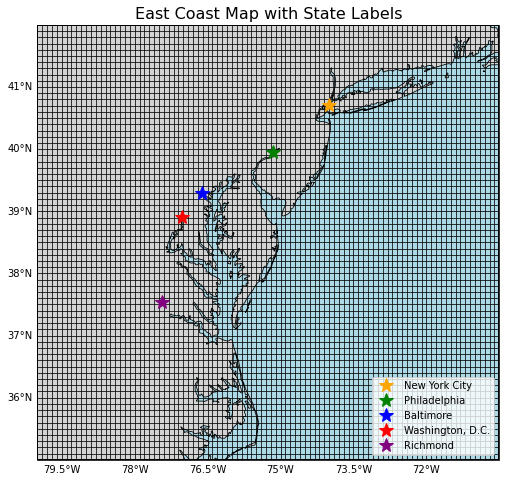

In [0]:
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

fishnet_x.geometry.boundary.plot(ax=ax, color = "black", alpha = 1, linewidth = 0.5, edgecolor = "black")
bounding_box.geometry.boundary.plot(ax=ax, color='black', linewidth=2, alpha=1, transform=ccrs.PlateCarree())

colors = ['blue', 'green', 'red', 'purple', 'orange']
for color, (idx, row) in zip(colors, major_cities_points.iterrows()):
    ax.plot(row.geometry.x, row.geometry.y, marker='*', markersize=15, color=color, alpha=1,
            transform=ccrs.PlateCarree())

from matplotlib.lines import Line2D
city_handles = [
    Line2D([0], [0], marker='*', linestyle='None', markerfacecolor='orange',
              markeredgecolor='orange', label='New York City', markersize=15),

    Line2D([0], [0], marker='*', linestyle='None', markerfacecolor='green',
           markeredgecolor='green', label='Philadelphia', markersize=15),
        
    Line2D([0], [0], marker='*', linestyle='None', markerfacecolor='blue',
           markeredgecolor='blue', label='Baltimore', markersize=15),
    
    Line2D([0], [0], marker='*', linestyle='None', markerfacecolor='red',
           markeredgecolor='red', label='Washington, D.C.', markersize=15),
    Line2D([0], [0], marker='*', linestyle='None', markerfacecolor='purple',
           markeredgecolor='purple', label='Richmond', markersize=15),

]
ax.legend(handles=city_handles, loc='lower right', fontsize=10, frameon=True)
plt.title("East Coast Map with State Labels", fontsize=16)
plt.show()

Now that we have set up the grids and our data, lets do spatial data analysis and check trend of NO2 pollution accross multiple cities from 2018 to 2024. Also, lets zoom in around the lockdowns in 2020 to see the impact of covid-19 on NO2 pollution accross major cities in the east coast of USA.

## 3.1 Covid-19 NO2 Pollution Trend Analysis

In [0]:
from shapely import Polygon

def get_polygon(row):
    '''
    Takes in corner cordinates of Latitude and Longitudes and return a polygon that is roughly 0.1deg * 0.1deg.
    '''
    return Polygon([(row['LON1'], row['LAT1']), (row['LON2'], row['LAT2']),(row['LON3'], row['LAT3']), (row['LON4'], row['LAT4'])])

Unfortunately, using PySpark dataframes to store Shapely Objects is not possible, unless I use Sedona. So, I will convert Spark dataframe to GeoPandas dataframe to do spatial calculations like within, intersection, sjoin_nearest etc. Howeever, all of the other standard operations will be done purely in PySpark.

In [0]:
geopandas_df = df.toPandas() # reverting back to pandas dataframe

In [0]:
%%time

# creating polygons from corner cordinates
geopandas_df['rectangle'] = geopandas_df.apply(get_polygon, axis = 1)
geopandas_df = gpd.GeoDataFrame(geopandas_df, geometry="rectangle", crs="EPSG:4326")

CPU times: user 1min 42s, sys: 1.28 s, total: 1min 43s
Wall time: 1min 44s


In [0]:
geopandas_df.columns

Out[63]: Index(['latitude', 'longitude', 'ColumnAmountNO2', 'cloudFraction', 'LAT1',
       'LAT2', 'LAT3', 'LAT4', 'LON1', 'LON2', 'LON3', 'LON4', 'date', 'year',
       'month', 'day', 'dayname', 'year_month', 'rectangle'],
      dtype='object')

In [0]:
# selecting relevant columns and creating date column from string date in pandas
geopandas_df = geopandas_df[["date", "year", "month", "day", "year_month", "dayname", "rectangle", "ColumnAmountNO2"]].copy()
geopandas_df["date"] = pd.to_datetime(geopandas_df["date"])
geopandas_df.head()

,date,year,month,day,year_month,dayname,rectangle,ColumnAmountNO2
0,2018-01-01,2018,1,1,2018-01,Monday,"POLYGON ((-76.2421 34.9601, -75.9567 35.0182, ...",3.564553e+15
1,2018-01-01,2018,1,1,2018-01,Monday,"POLYGON ((-76.8763 34.9518, -76.574 35.0175, -...",6.252209e+15
2,2018-01-01,2018,1,1,2018-01,Monday,"POLYGON ((-76.574 35.0175, -76.2804 35.0793, -...",5.060914e+15
3,2018-01-01,2018,1,1,2018-01,Monday,"POLYGON ((-76.2804 35.0793, -75.9946 35.1374, ...",1.285214e+15
4,2018-01-01,2018,1,1,2018-01,Monday,"POLYGON ((-77.5533 34.9252, -77.2286 35.0005, ...",2.626494e+15


In [0]:
from collections import OrderedDict

def get_ordered_dict(dx, IDs):
    '''
    This will sort the values in order of the fishnet grid IDs after doing spatial joins;
    If a grid is mssing, it will be allocated NaN value.
    '''
    try:
        for id_ in IDs:
            if id_ not in dx.keys():
                dx[id_] = np.nan
        
        dict1 = dict(OrderedDict(sorted(dx.items())))
        return np.array(list(dict1.values()))
    except Exception as e:
        print("Error while rearranging IDS: ", str(e))

In [0]:
def apply_spatial_join_with_intersection(dataframe: gpd.GeoDataFrame, start_date: str, end_date: str, output_column: str):
    '''
    This function will take in a dataframe and do a spatial join with the fishnet grid cells based on intersection and return average OMI NO2 values for each grid cell.
    '''
    try:
        dataframe = dataframe[(dataframe["date"] >= start_date) & (dataframe["date"] <= end_date)]
        result = fishnet_x.sjoin(dataframe, predicate = 'intersects')
        fishnet_x[output_column]  = get_ordered_dict(dict(result.groupby('ID', dropna = False)['ColumnAmountNO2'].mean()), fishnet_x['ID'])
    except Exception as e:
        print(f"Error in spatial join: {str(e)}")

Based on quick google search, I found that the core lockdowns during Covid-19 happened between March and May of 2020. So, lets only use that date range to do averaging for years 2019, 2020, and 2021. This way, we can directly compare 2020 values with 2019 and 2020 to see how NO2 pollution looked like in 2019, how much reduction we got in 2020 and for the same timeframe in 2021 when everything was normal, the pattern of NO2 pollution recovery.

In [0]:
%%time

# getting average for 2019 per grid
local_data = geopandas_df[geopandas_df.year==2019].copy()
apply_spatial_join_with_intersection(local_data, "2019-03-01", "2019-05-31", "NO2_2019")

CPU times: user 1.08 s, sys: 27.9 ms, total: 1.1 s
Wall time: 1.1 s


In [0]:
%%time

# getting average for 2020 per grid
local_data = geopandas_df[geopandas_df.year==2020].copy()
apply_spatial_join_with_intersection(local_data, "2020-03-01", "2020-05-31", "NO2_2020")

CPU times: user 931 ms, sys: 12 ms, total: 943 ms
Wall time: 942 ms


In [0]:
%%time

# getting average for 2021 per grid
local_data = geopandas_df[geopandas_df.year==2021].copy()
apply_spatial_join_with_intersection(local_data, "2021-03-01", "2021-05-31", "NO2_2021")

CPU times: user 1.27 s, sys: 44 ms, total: 1.31 s
Wall time: 1.32 s


In [0]:
fishnet_x.head()

,geometry,ID,NO2_2019,NO2_2020,NO2_2021
0,"POLYGON ((-80.1 35, -80.1 35.1, -80 35.1, -80 ...",1,5.238502e+15,4.432402e+15,5.185590e+15
1,"POLYGON ((-80.1 35.1, -80.1 35.2, -80 35.2, -8...",2,5.279170e+15,4.504601e+15,4.974318e+15
2,"POLYGON ((-80.1 35.2, -80.1 35.3, -80 35.3, -8...",3,5.222670e+15,4.358271e+15,4.897500e+15
3,"POLYGON ((-80.1 35.3, -80.1 35.4, -80 35.4, -8...",4,5.032398e+15,4.336585e+15,4.818413e+15
4,"POLYGON ((-80.1 35.4, -80.1 35.5, -80 35.5, -8...",5,5.089758e+15,4.450828e+15,4.822299e+15


Now that we have averages for each grid, lets do the spatial plot next.

3it [00:11,  3.92s/it]


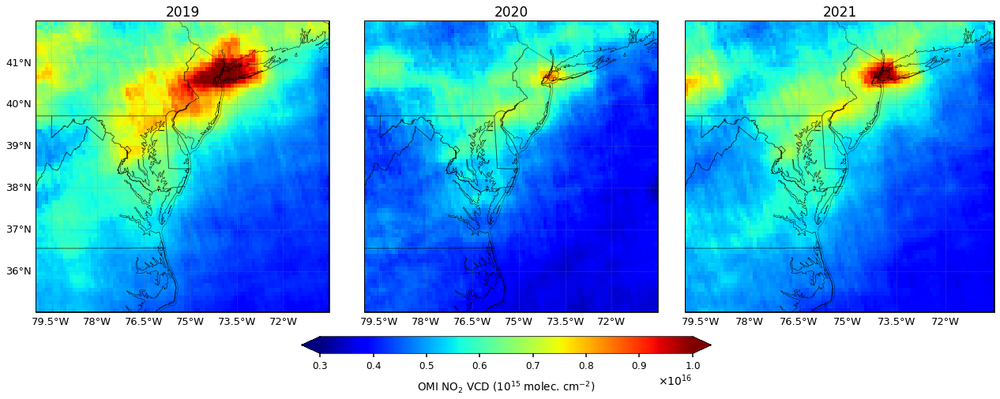

In [0]:
vmin = 3e+15
vmax = 10e+15
cmap = "jet"
alpha = 1

plt.rcParams.update({'font.size': 14})

fig, axes = plt.subplots(1, 3, figsize=(18, 6), 
                        subplot_kw={"projection": ccrs.PlateCarree()},
                        gridspec_kw={'width_ratios': [1, 1, 1]})

years = ['2019', '2020', '2021']
columns = ['NO2_2019', 'NO2_2020', 'NO2_2021']
current_col = 0

for ax, year, col in tqdm(zip(axes, years, columns)):
    ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    # ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=0.5)
    
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    if current_col != 0:
        gl.left_labels = False
    
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 13}
    gl.ylabel_style = {'size': 13}

    
    bounding_box.geometry.boundary.plot(ax=ax, color='black', linewidth=2, alpha=1, transform=ccrs.PlateCarree())
    us_states.geometry.boundary.plot(ax=ax, color='black', linewidth=0.75, alpha=0.45, transform=ccrs.PlateCarree())

    fishnet_x.plot(ax=ax, column=col, alpha=alpha, linewidth=0, edgecolor=None, cmap=cmap,
                   missing_kwds=dict(color='grey', label='No Data'), vmin=vmin, vmax=vmax, legend=False)
    
    ax.set_title(year, fontsize=17)

    ax.tick_params(labelsize=20)
    ax.spines['bottom'].set_color('black')
    ax.spines['top'].set_color('black') 
    ax.spines['right'].set_color('black')
    ax.spines['right'].set_linewidth(2)
    ax.spines['top'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_color('black')
    ax.spines['left'].set_lw(2) 
    ax.tick_params(which='both', width=3)
    ax.tick_params(which='major', length=6)
    ax.tick_params(which='minor', length=6)
    ax.tick_params(which = 'both', direction = 'in')
    current_col += 1

cax = fig.add_axes([0.31, -0.02, 0.4, 0.05])  
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal', extend='both')
cbar.set_label('OMI NO$_2$ VCD ($10^{15}$ molec. $\mathregular{cm^{-2}}$)', 
               fontsize=13.5, labelpad=10, fontweight='normal')
cbar.ax.tick_params(length=5, width=1.5, which="major", direction='out', labelsize=12)
cbar.set_alpha(alpha)
cbar.draw_all()
cbar.formatter.set_useMathText(True)
plt.tight_layout()
plt.subplots_adjust(bottom=0.1, hspace=0.1, wspace=0.05)  
plt.show()  

We can cleary see during 2020, the NO2 pollution has dropped by a significant margin. This figure calculation is done using March-May for 2019, 2020, and 2021. Due to covid lockdowns, stuff like vehicle emissions, industrial process etc reduced by a huge margin, which ultimately led to less NO2 in the atmosphere. Similarly, when lockdowns eased, the same timeframe (March-May) in 2021 shows pollution has recovered by a lot margin as people started driving their cars to go to work, power plants, airplaes etc started operating at normal rate.

In [0]:
import matplotlib.ticker as mticker

In [0]:
geopandas_df

,date,year,month,day,year_month,dayname,rectangle,ColumnAmountNO2
0,2018-01-01,2018,1,1,2018-01,Monday,"POLYGON ((-76.2421 34.9601, -75.9567 35.0182, ...",3.564553e+15
1,2018-01-01,2018,1,1,2018-01,Monday,"POLYGON ((-76.8763 34.9518, -76.574 35.0175, -...",6.252209e+15
2,2018-01-01,2018,1,1,2018-01,Monday,"POLYGON ((-76.574 35.0175, -76.2804 35.0793, -...",5.060914e+15
3,2018-01-01,2018,1,1,2018-01,Monday,"POLYGON ((-76.2804 35.0793, -75.9946 35.1374, ...",1.285214e+15
4,2018-01-01,2018,1,1,2018-01,Monday,"POLYGON ((-77.5533 34.9252, -77.2286 35.0005, ...",2.626494e+15
...,...,...,...,...,...,...,...,...
933307,2024-12-30,2024,12,30,2024-12,Monday,"POLYGON ((-78.507 40.1252, -78.1651 40.2053, -...",4.929410e+15
933308,2024-12-30,2024,12,30,2024-12,Monday,"POLYGON ((-78.1651 40.2053, -77.8351 40.2801, ...",5.846137e+15
933309,2024-12-30,2024,12,30,2024-12,Monday,"POLYGON ((-80.0836 39.8535, -79.6723 39.9631, ...",5.220344e+15
933310,2024-12-30,2024,12,30,2024-12,Monday,"POLYGON ((-80.1322 39.9711, -79.7202 40.0809, ...",4.687105e+15


In [0]:
# getting yearly average for each year for each grid
for year in tqdm(range(2018, 2025)):
    local_data = geopandas_df[geopandas_df.year==year].copy()
    result = fishnet_x[["ID", "geometry"]].sjoin(local_data, predicate = 'intersects')
    fishnet_x[str(year)]  = get_ordered_dict(dict(result.groupby('ID', dropna = False)['ColumnAmountNO2'].mean()), fishnet_x['ID'])

100%|██████████| 7/7 [00:32<00:00,  4.70s/it]


7it [00:37,  5.34s/it]


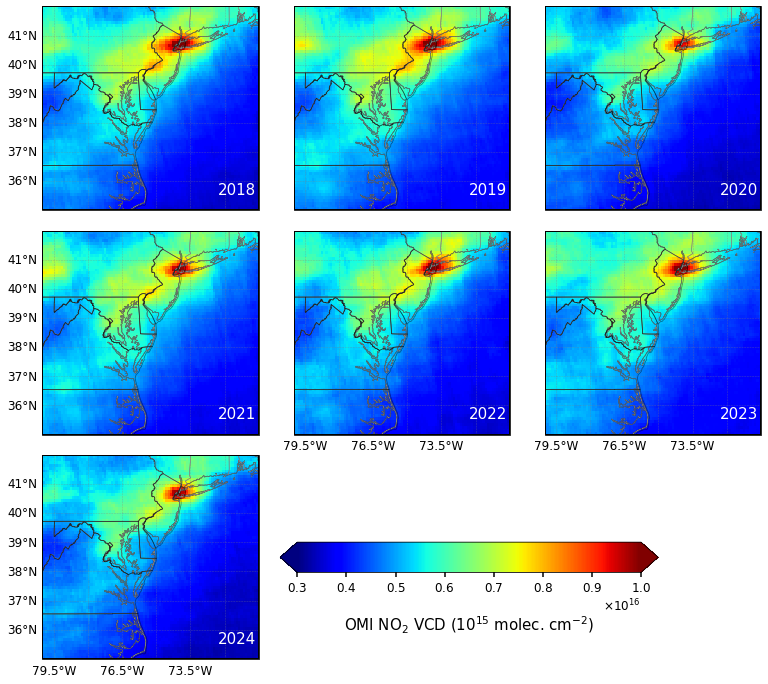

In [0]:
vmin = 3e+15
vmax = 10e+15
cmap = "jet"
alpha = 1

plt.rcParams.update({'font.size': 12})

fig, axes = plt.subplots(3, 3, figsize=(15, 12), subplot_kw={"projection": ccrs.PlateCarree()})
axes = axes.flatten() 

years = ["2018", '2019', '2020', '2021', "2022", "2023", "2024"]
current_col = 0

for ax, year in tqdm(zip(axes[:len(years)], years)):
    ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=0.5)
    
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    if current_col not in [0, 3, 6]:
        gl.left_labels = False

    if current_col not in [4, 5, 6]:
        gl.bottom_labels = False
    
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 12}
    gl.ylabel_style = {'size': 12}

    
    bounding_box.geometry.boundary.plot(ax=ax, color='black', linewidth=2, alpha=1, transform=ccrs.PlateCarree())
    us_states.geometry.boundary.plot(ax=ax, color='black', linewidth=0.75, alpha=0.45, transform=ccrs.PlateCarree())

    fishnet_x.plot(ax=ax, column=year, alpha=alpha, linewidth=0, edgecolor=None, cmap=cmap,
                   missing_kwds=dict(color='grey', label='No Data'), vmin=vmin, vmax=vmax, legend=False)
    
    ax.annotate(year, xy=(0.9, 0.1), xycoords='axes fraction', fontsize=15, ha='center', va='center', color="white", fontweight="normal")

    ax.tick_params(labelsize=15)
    ax.spines['bottom'].set_color('black')
    ax.spines['top'].set_color('black') 
    ax.spines['right'].set_color('black')
    ax.spines['right'].set_linewidth(2)
    ax.spines['top'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_color('black')
    ax.spines['left'].set_lw(2) 
    ax.tick_params(which='both', width=3)
    ax.tick_params(which='major', length=6)
    ax.tick_params(which='minor', length=6)
    ax.tick_params(which = 'both', direction = 'in')
    gl.xlocator = mticker.MaxNLocator(nbins=8) 
    current_col += 1

cax = fig.add_axes([0.4, 0.225, 0.35, 0.035])  
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal', extend='both')
cbar.set_label('OMI NO$_2$ VCD ($10^{15}$ molec. $\mathregular{cm^{-2}}$)', 
               fontsize=15, labelpad=20, fontweight='normal')
cbar.ax.tick_params(length=5, width=1.5, which="major", direction='out', labelsize=12)
cbar.set_alpha(alpha)
cbar.draw_all()
cbar.formatter.set_useMathText(True)

for ax in axes[len(years):]:
    ax.set_visible(False)

plt.subplots_adjust(wspace=-0.25, hspace=0.1)  
plt.show()  

This is yearly average for all years from 2018 to 2024. If we look at this plot in detail, we see NO2 pollution going down overtime. If I had used data from 2000s to 2024 (25 year average), it would have been more clear. But, the concentrated region in NYC is also diluting over the year and same case applies to regional hotspots.

This is due to EV mandates, reduction in use of coal, and cleaner energy sources that are being applied more in recent years.

In [0]:
# lets select relevant columns and convert to spark dataframe to do analysis using spark
spark_df = spark.createDataFrame(fishnet_x[["ID", "NO2_2019", "NO2_2020", "NO2_2021"]])

In [0]:
spark_df.show(5)

+---+--------------------+--------------------+--------------------+
| ID|            NO2_2019|            NO2_2020|            NO2_2021|
+---+--------------------+--------------------+--------------------+
|  1|5.238501805797101E15|4.432401958181818E15|5.185590373333333E15|
|  2|    5.27917002875E15|4.504601460869565E15|4.974317683098592E15|
|  3|5.222670382278481E15|4.358271074027778E15|4.897499590789474E15|
|  4|5.032397821518987E15|4.336584706052631...| 4.81841282109589E15|
|  5|5.089758197435897E15|4.450828495142857E15| 4.82229858084507E15|
+---+--------------------+--------------------+--------------------+
only showing top 5 rows



In [0]:
spark_df.printSchema()

root
 |-- ID: long (nullable = true)
 |-- NO2_2019: double (nullable = true)
 |-- NO2_2020: double (nullable = true)
 |-- NO2_2021: double (nullable = true)



In [0]:
from pyspark.sql.functions import col

# calculating the percent change between 2019 and 2020
spark_df = spark_df.withColumn("percentage_change_2019_2020",
    ((col("NO2_2020") - col("NO2_2019")) / col("NO2_2019")) * 100
)

# calculating the percent change between 2020 and 2021
spark_df = spark_df.withColumn("percentage_change_2020_2021",
    ((col("NO2_2021") - col("NO2_2020")) / col("NO2_2020")) * 100
)

In [0]:
spark_df.select("percentage_change_2019_2020", "percentage_change_2020_2021").describe().show()

+-------+---------------------------+---------------------------+
|summary|percentage_change_2019_2020|percentage_change_2020_2021|
+-------+---------------------------+---------------------------+
|  count|                       6909|                       6910|
|   mean|         -16.31876849291528|          10.27384096308451|
| stddev|          6.307660627792277|           7.62066586753958|
|    min|         -63.67048611245306|         -66.66545475062689|
|    max|         60.849314724331094|         137.42740699817037|
+-------+---------------------------+---------------------------+



Across all grids, from 2019-2020, NO2 reduced by 16% and from 2020-2021 for same march-may period, there is 10% increment in NO2.

In [0]:
results = spark_df.select("percentage_change_2019_2020", "percentage_change_2020_2021").toPandas()
fishnet_x["percentage_change_2019_2020"] = results["percentage_change_2019_2020"].values
fishnet_x["percentage_change_2020_2021"] = results["percentage_change_2020_2021"].values

2it [00:07,  3.67s/it]


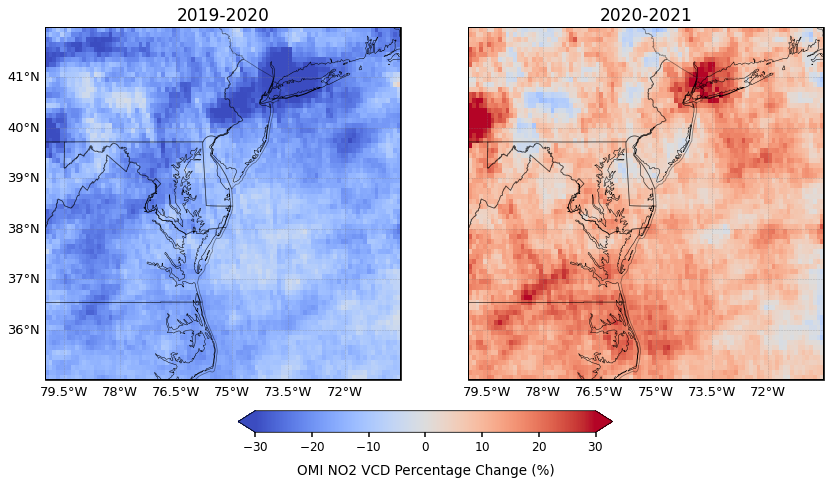

In [0]:
vmin = -30
vmax = 30
cmap = "coolwarm"
alpha = 1

plt.rcParams.update({'font.size': 14})

fig, axes = plt.subplots(1, 2, figsize=(13, 6), 
                        subplot_kw={"projection": ccrs.PlateCarree()},
                        gridspec_kw={'width_ratios': [1, 1]})

years = ["2019-2020", "2020-2021"]
columns = ['percentage_change_2019_2020', 'percentage_change_2020_2021']
current_col = 0

for ax, year, col in tqdm(zip(axes, years, columns)):
    ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    if current_col != 0:
        gl.left_labels = False
    
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 13}
    gl.ylabel_style = {'size': 13}

    
    bounding_box.geometry.boundary.plot(ax=ax, color='black', linewidth=2, alpha=1, transform=ccrs.PlateCarree())
    us_states.geometry.boundary.plot(ax=ax, color='black', linewidth=0.75, alpha=0.45, transform=ccrs.PlateCarree())

    fishnet_x.plot(ax=ax, column=col, alpha=alpha, linewidth=0, edgecolor=None, cmap=cmap,
                   missing_kwds=dict(color='grey', label='No Data'), vmin=vmin, vmax=vmax, legend=False)
    
    ax.set_title(year, fontsize=17)

    ax.tick_params(labelsize=20)
    ax.spines['bottom'].set_color('black')
    ax.spines['top'].set_color('black') 
    ax.spines['right'].set_color('black')
    ax.spines['right'].set_linewidth(2)
    ax.spines['top'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_color('black')
    ax.spines['left'].set_lw(2) 
    ax.tick_params(which='both', width=3)
    ax.tick_params(which='major', length=6)
    ax.tick_params(which='minor', length=6)
    ax.tick_params(which = 'both', direction = 'in')
    current_col += 1

cax = fig.add_axes([0.31, -0.02, 0.4, 0.05])  
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal', extend='both')
cbar.set_label('OMI NO2 VCD Percentage Change (%)', 
               fontsize=13.5, labelpad=10, fontweight='normal')
cbar.ax.tick_params(length=5, width=1.5, which="major", direction='out', labelsize=12)
cbar.set_alpha(alpha)
cbar.draw_all()
cbar.formatter.set_useMathText(True)
plt.tight_layout()
plt.subplots_adjust(bottom=0.1, hspace=0.1, wspace=-0.05)  
plt.show()  

This is essentially percentage change between each grid cell from 2019-2020 and 2020-2021 for NO2. Due to lockdowns, we see huge percentage reduction of OMI NO2 in the atmosphere for core NYC area and other hotspots whereas, in 2021, pollution has almost recovered as lockdowns eased and things went back to normal.

Let's look at each major citie in East Coast: `NYC, Philly, DC, Baltimore and Richmond`.

In [0]:
'''
OpenStreetMap python package is very useful to get the geometries of the cities and their boundaries.
'''

cities = ["Baltimore, Maryland, USA", 
          "Richmond, Virginia, USA", 
          "Philadelphia, Pennsylvania, USA", 
          "New York City, New York, USA", 
          "Washington D.C, USA"]

city_geometries = []
for city in cities:
    city_name = city.split(",")[0]
    city_geometries.append(ox.geocode_to_gdf(city)["geometry"].values[0]) # OSM python package returns a GeoDataFrame

city_geometries = gpd.GeoDataFrame({"City": cities}, geometry=city_geometries, crs="EPSG:4326")
city_geometries["City"] = city_geometries["City"].str.split(",").str[0]

In [0]:
city_geometries

,City,geometry
0,Baltimore,"POLYGON ((-76.7113 39.37193, -76.71129 39.3675..."
1,Richmond,"POLYGON ((-77.60117 37.54516, -77.60077 37.544..."
2,Philadelphia,"POLYGON ((-75.2803 39.975, -75.28022 39.97489,..."
3,New York City,"MULTIPOLYGON (((-74.25884 40.49888, -74.25814 ..."
4,Washington D.C,"POLYGON ((-77.11979 38.93435, -77.11977 38.934..."


In [0]:
def filter_data_for_city(local_df: gpd.GeoDataFrame, city_name: str):
    '''
    Given a city Name, filter the data for that city and return the filtered dataframe for the corresponding city.
    '''
    try:
        local_df = local_df.copy()
        local_df = local_df.sjoin(city_geometries[city_geometries["City"] == city_name], predicate = 'intersects')
        local_df = local_df[["date", "year", "month", "day", "year_month", "dayname", "ColumnAmountNO2"]].copy()
        return local_df
    except Exception as e:
        print("error occured while filtering data for city: ", str(e))

In [0]:
# filtering OMI NO2 data for each city
baltimore_df = filter_data_for_city(geopandas_df, "Baltimore")
richmond_df = filter_data_for_city(geopandas_df, "Richmond")
philadelphia_df = filter_data_for_city(geopandas_df, "Philadelphia")
newyork_df = filter_data_for_city(geopandas_df, "New York City")
washington_df = filter_data_for_city(geopandas_df, "Washington D.C") 

baltimore_df.shape, richmond_df.shape, philadelphia_df.shape, newyork_df.shape, washington_df.shape

Out[86]: ((4743, 7), (4476, 7), (5672, 7), (10223, 7), (4754, 7))

In [0]:
selected_columns = ["date", "year", "month", "day", "year_month", "dayname", "ColumnAmountNO2"]

# recreating spark dataframes for each of the cities
baltimore_spark_df = spark.createDataFrame(baltimore_df[selected_columns])
richmond_spark_df = spark.createDataFrame(richmond_df[selected_columns])
philadelphia_spark_df = spark.createDataFrame(philadelphia_df[selected_columns])
newyork_spark_df = spark.createDataFrame(newyork_df[selected_columns])
washington_spark_df = spark.createDataFrame(washington_df[selected_columns])

In [0]:
baltimore_spark_df.show(5)

+-------------------+----+-----+---+----------+---------+---------------+
|               date|year|month|day|year_month|  dayname|ColumnAmountNO2|
+-------------------+----+-----+---+----------+---------+---------------+
|2018-01-02 00:00:00|2018|    1|  2|   2018-01|  Tuesday|    7.739733E15|
|2018-01-02 00:00:00|2018|    1|  2|   2018-01|  Tuesday|    5.155923E15|
|2018-01-02 00:00:00|2018|    1|  2|   2018-01|  Tuesday|   4.5008847E15|
|2018-01-02 00:00:00|2018|    1|  2|   2018-01|  Tuesday|   5.5946684E15|
|2018-01-03 00:00:00|2018|    1|  3|   2018-01|Wednesday|   1.3068163E16|
+-------------------+----+-----+---+----------+---------+---------------+
only showing top 5 rows



Now that we have spark dataframes for each city, lets compute average NO2 per YEAR-MONTH and plot a lineplot to check the NO2 pattern overtime.

In [0]:
# getting year-month average and standard error for all years for baltimore
baltimore_city_summary = baltimore_spark_df.groupBy("year_month").agg(
    F.mean("ColumnAmountNO2").alias("mean"),
    (F.stddev("ColumnAmountNO2") / F.sqrt(F.count("ColumnAmountNO2"))).alias("std_error")
).orderBy(F.asc("year_month"))

In [0]:
baltimore_city_summary.show(5)

+----------+--------------------+--------------------+
|year_month|                mean|           std_error|
+----------+--------------------+--------------------+
|   2018-01| 8.02008446744186E15|4.180340182335334...|
|   2018-02|9.590144479310344E15|6.646565663019616E14|
|   2018-03|      9.843674192E15|7.291387882204655E14|
|   2018-04|6.257140395918367E15| 1.95212487168931E14|
|   2018-05|6.660900498734177E15|1.657644340757767E14|
+----------+--------------------+--------------------+
only showing top 5 rows



Here, standard error is standard deviation divided by square root of the number of samples. I am plotting error bar and using standard deviation only would show huge spikes that would disturb the plot. That's why I used standard error instead. Now, lets calculate the mean and standard error for other cities.

In [0]:
# getting values for richmond for OMI NO2
richmond_city_summary = richmond_spark_df.groupBy("year_month").agg(
    F.mean("ColumnAmountNO2").alias("mean"),
    (F.stddev("ColumnAmountNO2") / F.sqrt(F.count("ColumnAmountNO2"))).alias("std_error")
).orderBy(F.asc("year_month"))

# getting values for DC for OMI NO2
washingtonDC_city_summary = washington_spark_df.groupBy("year_month").agg(
    F.mean("ColumnAmountNO2").alias("mean"),
    (F.stddev("ColumnAmountNO2") / F.sqrt(F.count("ColumnAmountNO2"))).alias("std_error")
).orderBy(F.asc("year_month"))

# getting values for philly for OMI NO2
philadelphia_city_summary = philadelphia_spark_df.groupBy("year_month").agg(
    F.mean("ColumnAmountNO2").alias("mean"),
    (F.stddev("ColumnAmountNO2") / F.sqrt(F.count("ColumnAmountNO2"))).alias("std_error")
).orderBy(F.asc("year_month"))

# getting values for new york for OMI NO2
newyork_city_summary = newyork_spark_df.groupBy("year_month").agg(
    F.mean("ColumnAmountNO2").alias("mean"),
    (F.stddev("ColumnAmountNO2") / F.sqrt(F.count("ColumnAmountNO2"))).alias("std_error")
).orderBy(F.asc("year_month"))

In [0]:
# keeping each summary in a dictionary to reuse in plotting
city_dfs = {
    "New York City": newyork_city_summary,
    "Baltimore": baltimore_city_summary,
    "Washington D.C": washingtonDC_city_summary,
}

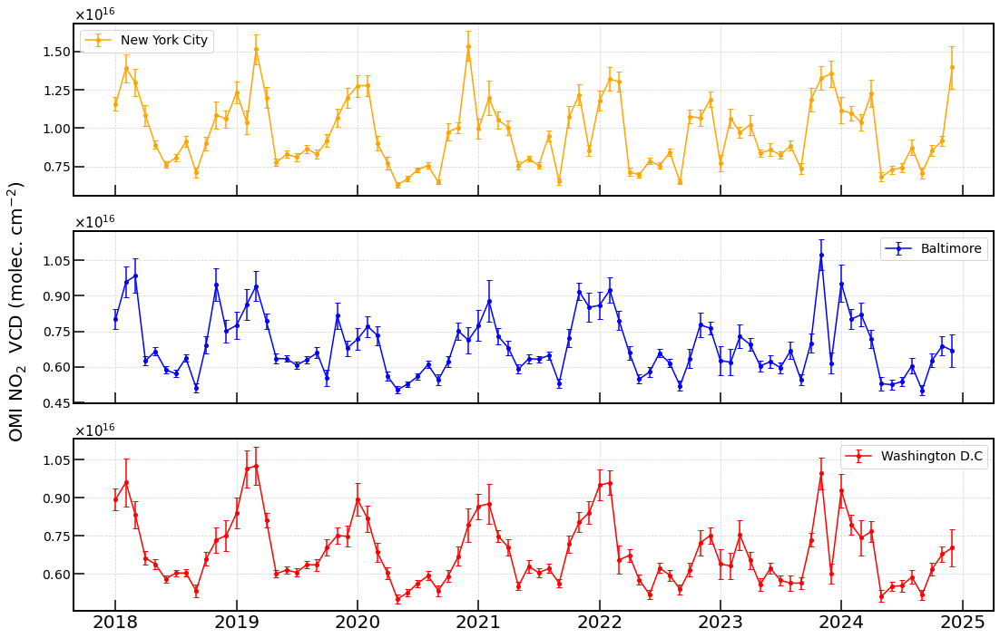

In [0]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10))  
col = 1
city_and_colors = {
    "New York City": "orange",
    "Baltimore": "blue",
    "Richmond": "purple",    
    "Washington D.C": "red",
    "Philadelphia": "green",
}

for ax, (city_name, city_df) in zip(axes, city_dfs.items()):
    city_summary = city_df.toPandas() # reverting back to pandas for matplotlib integration
    city_summary["year_month"] = pd.to_datetime(city_summary["year_month"])
    city_summary.sort_values(by="year_month", inplace=True)
    color = city_and_colors[city_name]

    ax.errorbar(
        city_summary["year_month"],
        city_summary["mean"],
        yerr=city_summary["std_error"],
        fmt="o-", 
        capsize=3, 
        markersize=4,
        color=color,
        label=city_name
    )
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend()
    if col != 3:
        plt.setp(ax.get_xticklabels(), visible=False)

    ax.yaxis.set_major_locator(plt.MaxNLocator(5))
    ax.spines['bottom'].set_color('black')
    ax.spines['top'].set_color('black') 
    ax.spines['right'].set_color('black')
    ax.spines['right'].set_linewidth(2)
    ax.spines['top'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_color('black')
    ax.spines['left'].set_lw(2)
    ax.tick_params(which='minor', width=.8)
    ax.tick_params(which='major', width=1.5)
    ax.tick_params(which='major', length=12)
    ax.tick_params(which='minor', length=6.5)
    ax.tick_params(which = 'both', direction = 'in')
    ax.xaxis.set_tick_params(labelsize=20)
    ax.yaxis.set_major_formatter(formatter)
    ax.ticklabel_format(style='scientific', axis = 'y') 
    t = ax.yaxis.get_offset_text()
    t.set_size(15)
    col += 1

fig.text(-0.01, 0.512, 'OMI NO$_2$  VCD (molec. $\mathregular{cm^{-2}}$)', ha='center', va='center', rotation='vertical', fontsize = 20)
plt.subplots_adjust(bottom=0.1, hspace=-1, wspace=-0.3)  
plt.tight_layout()
plt.show()

Well, if we look here, there is a huge dip on March/April/May of 2020 as compared to same months in 2019. Similarly, the reduction in NO2 has recovered for the same time in 2021.

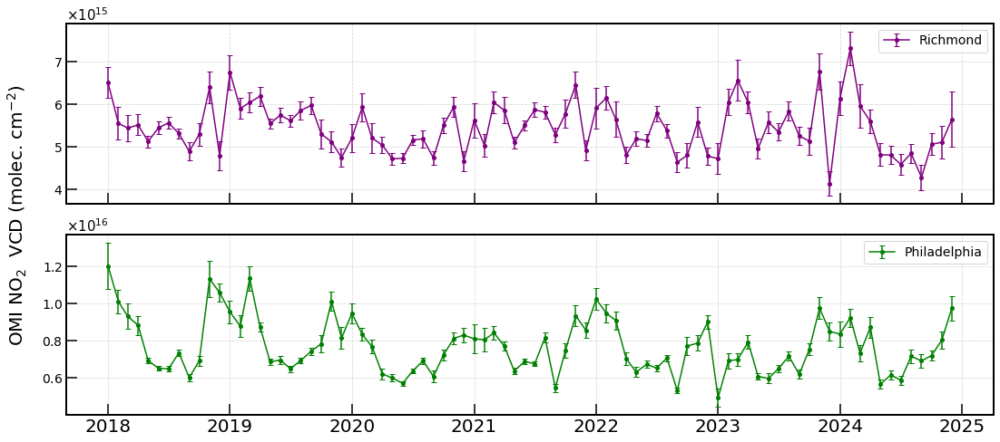

In [0]:
# plotting for Richmond and Philly
city_dfs = {
    "Richmond": richmond_city_summary,
    "Philadelphia": philadelphia_city_summary,
}

fig, axes = plt.subplots(2, 1, figsize=(15, 7))  
col = 1

for ax, (city_name, city_df) in zip(axes, city_dfs.items()):
    city_summary = city_df.toPandas() # reverting back to pandas for matplotlib integration
    city_summary["year_month"] = pd.to_datetime(city_summary["year_month"])
    color = city_and_colors[city_name]

    ax.errorbar(
        city_summary["year_month"],
        city_summary["mean"],
        yerr=city_summary["std_error"],
        fmt="o-", 
        capsize=3, 
        markersize=4,
        color=color,
        label=city_name
    )
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend()
    if col != 2:
        plt.setp(ax.get_xticklabels(), visible=False)

    ax.yaxis.set_major_locator(plt.MaxNLocator(5))
    ax.spines['bottom'].set_color('black')
    ax.spines['top'].set_color('black') 
    ax.spines['right'].set_color('black')
    ax.spines['right'].set_linewidth(2)
    ax.spines['top'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_color('black')
    ax.spines['left'].set_lw(2)
    ax.tick_params(which='minor', width=.8)
    ax.tick_params(which='major', width=1.5)
    ax.tick_params(which='major', length=12)
    ax.tick_params(which='minor', length=6.5)
    ax.tick_params(which = 'both', direction = 'in')
    ax.xaxis.set_tick_params(labelsize=20)
    ax.yaxis.set_major_formatter(formatter)
    ax.ticklabel_format(style='scientific', axis = 'y') 
    t = ax.yaxis.get_offset_text()
    t.set_size(15)
    col += 1

fig.text(-0.01, 0.512, 'OMI NO$_2$  VCD (molec. $\mathregular{cm^{-2}}$)', ha='center', va='center', rotation='vertical', fontsize = 20)
plt.subplots_adjust(bottom=0.1, hspace=-1, wspace=-0.3)  
plt.tight_layout()
plt.show()

If we look for these two cities as well, there is a dip during covid lockdowns and recovery for the same period in 2021, just like for other cities.

<b> Let's compare the monthly average NO2 for all cities for 2019, 2020, and 2021.

In [0]:
from pyspark.sql.functions import substring

def get_monthly_value_for_3_years(spark_dataframe: pyspark.sql.DataFrame, city_name: str):
    '''
    Given a spark dataframe and city name, this function will return the monthly values for the given city.
    '''
    try:
        filtered_df = spark_dataframe.filter(
            F.col("year_month").isin(["2019-03", "2019-04", "2019-05", 
                                    "2020-03", "2020-04", "2020-05",
                                    "2021-03", "2021-04", "2021-05"])
        )
        
        # get year and month from year-month using slicing the string
        filtered_df = filtered_df.withColumn("year", substring("year_month", 1, 4)) \
                            .withColumn("month", substring("year_month", 6, 2))

        filtered_df = filtered_df.groupBy("year").pivot("month").agg(F.first("mean")).orderBy("year")
        filtered_df = filtered_df.withColumnRenamed("year", f"Year ({city_name})")
        return filtered_df
    
    except Exception as e:
        print("error occurred while getting monthly values: ", str(e))

In [0]:
baltimore_city_summary = get_monthly_value_for_3_years(baltimore_city_summary, "Baltimore")
print(baltimore_city_summary.show())

+----------------+--------------------+--------------------+--------------------+
|Year (Baltimore)|                  03|                  04|                  05|
+----------------+--------------------+--------------------+--------------------+
|            2019|9.418311165714286E15|7.928413916666667E15|6.354189433846154E15|
|            2020|7.331136017857143E15|5.599459872340426E15|5.034874495454545E15|
|            2021|7.295491713636364E15|6.795088129166667E15|    5.90934469375E15|
+----------------+--------------------+--------------------+--------------------+

None


In [0]:
washingtonDC_city_summary = get_monthly_value_for_3_years(washingtonDC_city_summary, "Washington DC")
print(washingtonDC_city_summary.show())

+--------------------+--------------------+--------------------+--------------------+
|Year (Washington DC)|                  03|                  04|                  05|
+--------------------+--------------------+--------------------+--------------------+
|                2019|    1.02656703265E16|8.117745289361702E15|6.010647337142857E15|
|                2020|6.854541896226415E15|6.029382919148936E15|5.009493387931034E15|
|                2021|7.490342270422535E15|7.043635525490196E15|5.514093628169014E15|
+--------------------+--------------------+--------------------+--------------------+

None


In [0]:
richmond_city_summary = get_monthly_value_for_3_years(richmond_city_summary, "Richmond")
print(richmond_city_summary.show())

+---------------+--------------------+--------------------+--------------------+
|Year (Richmond)|                  03|                  04|                  05|
+---------------+--------------------+--------------------+--------------------+
|           2019| 6.04468492244898E15|       6.19542452E15|5.550297784722222E15|
|           2020|5.210141494871795E15|5.042064910416667E15|4.718381185483871E15|
|           2021|6.047454551785714E15|5.864383388135593E15|5.100400864285714E15|
+---------------+--------------------+--------------------+--------------------+

None


In [0]:
philadelphia_city_summary = get_monthly_value_for_3_years(philadelphia_city_summary, "Philadelphia")
print(philadelphia_city_summary.show())

+-------------------+--------------------+--------------------+--------------------+
|Year (Philadelphia)|                  03|                  04|                  05|
+-------------------+--------------------+--------------------+--------------------+
|               2019|1.136701087049180...|8.750736730882353E15| 6.87853364939759E15|
|               2020|7.696638510416667E15|     6.2273016625E15|6.005477635087719E15|
|               2021|8.433521672307692E15|7.726886998387097E15|6.381291722340426E15|
+-------------------+--------------------+--------------------+--------------------+

None


In [0]:
newyork_city_summary = get_monthly_value_for_3_years(newyork_city_summary, "New York City")
print(newyork_city_summary.show())

+--------------------+--------------------+--------------------+--------------------+
|Year (New York City)|                  03|                  04|                  05|
+--------------------+--------------------+--------------------+--------------------+
|                2019|1.513335509333333...|1.199201139759036...|      7.760381768E15|
|                2020|9.009616150515464E15|7.719058853333333E15|6.290899798850575E15|
|                2021|1.052455728854961...|1.003212074036697...|7.563603449411765E15|
+--------------------+--------------------+--------------------+--------------------+

None


If we look here, for each city's corresponding monthly value from 2019-2020 is down significantly whereas from 2020-2021, it has increased representing the recovery of NO2 pollution in 2021.

In [0]:
def get_percentage_change(spark_dataframe, city: str) -> pd.DataFrame: 
    try:
        pandas_df = spark_dataframe.toPandas().set_index(f"Year ({city})")
        pandas_df = pandas_df[["03","04","05"]].pct_change() * 100
        return pandas_df
    except Exception as e:
        print("error occurred while computing percentage change: ", str(e))

In [0]:
# percentage change for same period accross 2019-2021 for baltimore
get_percentage_change(baltimore_city_summary, "Baltimore").rename(columns={"03": "March", "04": "April", "05": "May"})

,March,April,May
Year (Baltimore),,,
2019,NaN,NaN,NaN
2020,-22.160822,-29.374779,-20.762915
2021,-0.486204,21.352564,17.368262


In [0]:
# percentage change for same period accross 2019-2021 for DC
get_percentage_change(washingtonDC_city_summary, "Washington DC").rename(columns={"03": "March", "04": "April", "05": "May"})

,March,April,May
Year (Washington DC),,,
2019,NaN,NaN,NaN
2020,-33.228502,-25.725892,-16.656342
2021,9.275607,16.821831,10.072880


In [0]:
# percantage change for same period accross 2019-2021 for richmond
get_percentage_change(richmond_city_summary, "Richmond").rename(columns={"03": "March", "04": "April", "05": "May"})

,March,April,May
Year (Richmond),,,
2019,NaN,NaN,NaN
2020,-13.806235,-18.616313,-14.988684
2021,16.070831,16.309161,8.096414


In [0]:
# percantage change for same period accross 2019-2021 for philly
get_percentage_change(philadelphia_city_summary, "Philadelphia").rename(columns={"03": "March", "04": "April", "05": "May"})

,March,April,May
Year (Philadelphia),,,
2019,NaN,NaN,NaN
2020,-32.289688,-28.836830,-12.692473
2021,9.574091,24.080821,6.257855


In [0]:
# percantage change for same period accross 2019-2021 for NYC
get_percentage_change(newyork_city_summary, "New York City").rename(columns={"03": "March", "04": "April", "05": "May"})

,March,April,May
Year (New York City),,,
2019,NaN,NaN,NaN
2020,-40.465177,-35.631658,-18.935692
2021,16.814713,29.965595,20.230868


If we look here, for each city's corresponding monthly value from 2019-2020 is down significantly whereas from 2020-2021, it has increased representing the recovery of NO2 pollution in 2021.

<b> Let's create a barplot that shows yearly average NO2 for each city.

In [0]:
baltimore_spark_df.show(5)

+-------------------+----+-----+---+----------+---------+---------------+
|               date|year|month|day|year_month|  dayname|ColumnAmountNO2|
+-------------------+----+-----+---+----------+---------+---------------+
|2018-01-02 00:00:00|2018|    1|  2|   2018-01|  Tuesday|    7.739733E15|
|2018-01-02 00:00:00|2018|    1|  2|   2018-01|  Tuesday|    5.155923E15|
|2018-01-02 00:00:00|2018|    1|  2|   2018-01|  Tuesday|   4.5008847E15|
|2018-01-02 00:00:00|2018|    1|  2|   2018-01|  Tuesday|   5.5946684E15|
|2018-01-03 00:00:00|2018|    1|  3|   2018-01|Wednesday|   1.3068163E16|
+-------------------+----+-----+---+----------+---------+---------------+
only showing top 5 rows



In [0]:
from pyspark.sql.functions import col, lit

In [0]:
# compute yearly average for each city from 2018-2024
baltimore_yearly_average = baltimore_spark_df.groupBy("year").agg(F.mean("ColumnAmountNO2").alias("yearly_mean")).orderBy(F.asc("year"))
baltimore_yearly_average = baltimore_yearly_average.withColumn("city", lit("Baltimore"))

In [0]:
baltimore_yearly_average.show()

+----+--------------------+---------+
|year|         yearly_mean|     city|
+----+--------------------+---------+
|2018|6.999369119968257E15|Baltimore|
|2019|6.825789696690747E15|Baltimore|
|2020|6.227863188278934E15|Baltimore|
|2021|6.958089628790199E15|Baltimore|
|2022|6.792614336583851E15|Baltimore|
|2023| 6.76553763673759E15|Baltimore|
|2024|6.389840182697985E15|Baltimore|
+----+--------------------+---------+



In [0]:
# lets calculate for other cities
richmond_yearly_average = richmond_spark_df.groupBy("year").agg(F.mean("ColumnAmountNO2").alias("yearly_mean")).orderBy(F.asc("year"))
richmond_yearly_average = richmond_yearly_average.withColumn("city", lit("Richmond"))

philadelphia_yearly_average = philadelphia_spark_df.groupBy("year").agg(F.mean("ColumnAmountNO2").alias("yearly_mean")).orderBy(F.asc("year"))
philadelphia_yearly_average = philadelphia_yearly_average.withColumn("city", lit("Philadelphia"))

newyork_yearly_average = newyork_spark_df.groupBy("year").agg(F.mean("ColumnAmountNO2").alias("yearly_mean")).orderBy(F.asc("year"))
newyork_yearly_average = newyork_yearly_average.withColumn("city", lit("New York City"))

washington_yearly_average = washington_spark_df.groupBy("year").agg(F.mean("ColumnAmountNO2").alias("yearly_mean")).orderBy(F.asc("year"))
washington_yearly_average = washington_yearly_average.withColumn("city", lit("Washington D.C"))

In [0]:
from functools import reduce
from pyspark.sql import DataFrame

dataframes = [
    baltimore_yearly_average,
    richmond_yearly_average,
    philadelphia_yearly_average,
    newyork_yearly_average,
    washington_yearly_average
]

# combining all dataframes (equivalent to pd.concat([df1, df2, df3]))
dataframes = reduce(DataFrame.unionAll, dataframes)
dataframes.show(10)

+----+--------------------+---------+
|year|         yearly_mean|     city|
+----+--------------------+---------+
|2018|6.999369119968257E15|Baltimore|
|2019|6.825789696690747E15|Baltimore|
|2020|6.227863188278934E15|Baltimore|
|2021|6.958089628790199E15|Baltimore|
|2022|6.792614336583851E15|Baltimore|
|2023| 6.76553763673759E15|Baltimore|
|2024|6.389840182697985E15|Baltimore|
|2018|5.498621911702505E15| Richmond|
|2019|5.692822893625729E15| Richmond|
|2020| 5.14038313502455E15| Richmond|
+----+--------------------+---------+
only showing top 10 rows



In [0]:
city_yearly_df = dataframes.toPandas() # reverting back to pandas dataframe

In [0]:
city_yearly_df.head()

,year,yearly_mean,city
0,2018,6.999369e+15,Baltimore
1,2019,6.825790e+15,Baltimore
2,2020,6.227863e+15,Baltimore
3,2021,6.958090e+15,Baltimore
4,2022,6.792614e+15,Baltimore


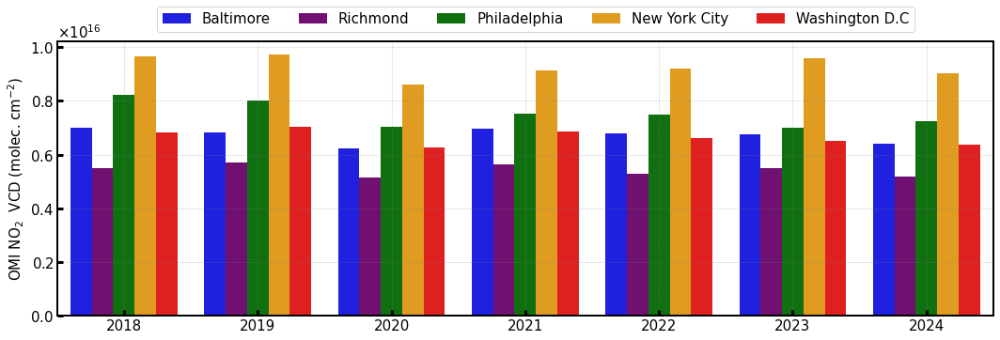

In [0]:
# barplot to show yearly average for each city from 2018-2024
cities_ordered = city_yearly_df['city'].unique()
palette = [city_and_colors[city] for city in cities_ordered]

fig, ax = plt.subplots(figsize=(15, 5))
sns.barplot(data=city_yearly_df, x="year", y="yearly_mean", hue="city", ax=ax, palette=palette)
ax.set_ylabel('OMI NO$_2$  VCD (molec. $\mathregular{cm^{-2}}$)', fontsize=15)
ax.set_xlabel('')
ax.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)

ax.tick_params(labelsize=15)
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_color('black') 
ax.spines['right'].set_color('black')
ax.spines['right'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_color('black')
ax.spines['left'].set_lw(2) 
ax.tick_params(which='both', width=3)
ax.tick_params(which='major', length=6)
ax.grid(True, linestyle="--", alpha=0.5)
ax.tick_params(which='minor', length=6)
ax.tick_params(which = 'both', direction = 'in')
ax.yaxis.set_major_formatter(formatter)
ax.ticklabel_format(style='scientific', axis = 'y') 
t = ax.yaxis.get_offset_text()
t.set_size(15)

handles, labels = ax.get_legend_handles_labels()
ax.legend_.remove()  
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.535, 1.03),  ncol=5,  fontsize=15,  frameon=True)  

plt.tight_layout()  
plt.show()

<b> Lets look at weekly pattern for New York City. 

In [0]:
newyork_spark_df.show(5)

+-------------------+----+-----+---+----------+-------+---------------+
|               date|year|month|day|year_month|dayname|ColumnAmountNO2|
+-------------------+----+-----+---+----------+-------+---------------+
|2018-01-02 00:00:00|2018|    1|  2|   2018-01|Tuesday|   1.5205864E16|
|2018-01-02 00:00:00|2018|    1|  2|   2018-01|Tuesday|    7.829908E15|
|2018-01-02 00:00:00|2018|    1|  2|   2018-01|Tuesday|     1.80972E16|
|2018-01-02 00:00:00|2018|    1|  2|   2018-01|Tuesday|   7.4386944E15|
|2018-01-02 00:00:00|2018|    1|  2|   2018-01|Tuesday|   1.3893254E16|
+-------------------+----+-----+---+----------+-------+---------------+
only showing top 5 rows



In [0]:
from pyspark.sql import functions as F

# this will be the order ihe barplot; weekends are at the end
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

In [0]:
'''
This is the mapping format to sort the dataframe based on day names. For instance, Monday is assigned 1, Tuesday as 2 and Sunday as 7.
So, when we do ascending order, our dataframe becomes Monday to Saturday
'''

mapping_expr = F.create_map(
    *sum(
        ([F.lit(d), F.lit(i+1)] for i, d in enumerate(day_order)),
        []
    )
)
mapping_expr

Out[118]: Column<'map(Monday, 1, Tuesday, 2, Wednesday, 3, Thursday, 4, Friday, 5, Saturday, 6, Sunday, 7)'>

In [0]:
# get average OMI NO2 for each day of the week and sort from Monday to Sunday
weekday_averages = (
    newyork_spark_df
      .groupBy("dayname")
      .agg(F.mean("ColumnAmountNO2").alias("ColumnAmountNO2"))
      .withColumn("sort_order", mapping_expr[F.col("dayname")])
      .orderBy("sort_order")
      .drop("sort_order") # don't need this column anymore; only used to sort based on day names
)

weekday_averages.show()

+---------+--------------------+
|  dayname|     ColumnAmountNO2|
+---------+--------------------+
|   Monday|9.154675971680218E15|
|  Tuesday|  9.6006062925608E15|
|Wednesday|1.020543889935858...|
| Thursday|9.652670841749092E15|
|   Friday|1.045324939298050...|
| Saturday|7.984665539845615E15|
|   Sunday|7.734370690650406E15|
+---------+--------------------+



In [0]:
# checking if a day is weekend or not
weekday_averages = weekday_averages.withColumn("is_weekend", col("dayname").isin("Saturday", "Sunday").cast("integer"))

In [0]:
weekday_averages.show()

+---------+--------------------+----------+
|  dayname|     ColumnAmountNO2|is_weekend|
+---------+--------------------+----------+
|   Monday|9.154675971680218E15|         0|
|  Tuesday|  9.6006062925608E15|         0|
|Wednesday|1.020543889935858...|         0|
| Thursday|9.652670841749092E15|         0|
|   Friday|1.045324939298050...|         0|
| Saturday|7.984665539845615E15|         1|
|   Sunday|7.734370690650406E15|         1|
+---------+--------------------+----------+



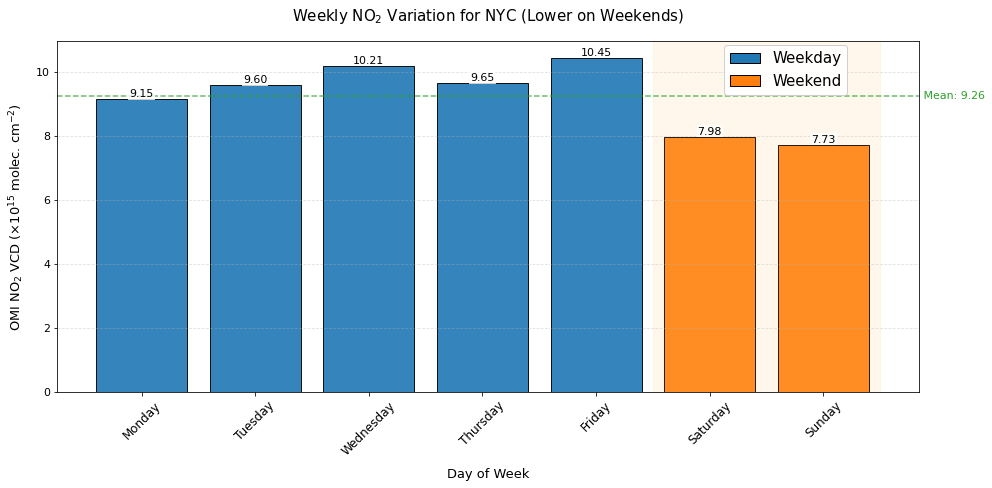

In [0]:
plt.figure(figsize=(14, 7))

weekday_averages = weekday_averages.toPandas() # reverting back to pandas for matplotlib integration
colors = ['#1f77b4' if not weekend else '#ff7f0e' for weekend in weekday_averages['is_weekend']]
bars = plt.bar(
    weekday_averages['dayname'],
    weekday_averages['ColumnAmountNO2'] / 1e15,
    color=colors,
    edgecolor='black',
    linewidth=1,
    alpha=0.9
)

plt.title('Weekly NO$_2$ Variation for NYC (Lower on Weekends)', 
          fontsize=15, pad=20, fontweight='normal')
plt.xlabel('Day of Week', fontsize=13, labelpad=10)
plt.ylabel('OMI NO$_2$ VCD ($\\times10^{15}$ molec. $\mathregular{cm^{-2}}$)', 
           fontsize=13, labelpad=10)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=11)

plt.axvspan(4.5, 6.5, color='orange', alpha=0.08, label='Weekend')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.2f}',
             ha='center', va='bottom', fontsize=11,
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))

weekday_patch = plt.Rectangle((0,0),1,1, fc='#1f77b4', edgecolor='black')
weekend_patch = plt.Rectangle((0,0),1,1, fc='#ff7f0e', edgecolor='black')
plt.legend([weekday_patch, weekend_patch], ['Weekday', 'Weekend'], 
           frameon=True, framealpha=0.9, fontsize=15, loc='upper right',
           bbox_to_anchor=(0.925, 1.01))

overall_mean = (weekday_averages['ColumnAmountNO2'].mean()) / 1e15
plt.axhline(y=overall_mean, color='#2ca02c', linestyle='--', linewidth=1.5, alpha=0.7)
plt.text(6.85, overall_mean, f' Mean: {overall_mean:.2f}', 
         va='center', ha='left', color='#2ca02c', fontsize=11)

plt.tight_layout()
plt.show()

As we can see, the NO2 during weekends is very low relatively compared to the weekdays. This is primarily because there is less commuter traffic during weekdays and during weekends, industrial activity is much lower.

In [0]:
def assign_season(month: int):
    '''
    Given a month, this function will return the season for that month.
    '''
    try:
        if month in [12, 1, 2]:
            return "DJF"
        elif month in [3, 4, 5]:
            return "MAM"
        elif month in [6, 7, 8]:
            return "JJA"
        elif month in [9, 10, 11]:
            return "SON"
        
    except Exception as e:
        print("error occurred while assigning season: ", str(e))

In [0]:
geopandas_df["season"] = geopandas_df["month"].apply(assign_season) # get season based on month

In [0]:
def get_monthly_average_spatial(local_df: gpd.GeoDataFrame, season: str) -> gpd.GeoDataFrame:
    '''
    Given a local dataframe and season, this function will return the monthly average for the given season.
    '''
    try:
        local_df = local_df[local_df["season"] == season]
        result = fishnet_x[["ID", "geometry"]].sjoin(local_df, predicate = 'intersects')
        fishnet_x[season]  = get_ordered_dict(dict(result.groupby('ID', dropna = False)['ColumnAmountNO2'].mean()), fishnet_x['ID'])
    except Exception as e:
        print("error occurred while getting monthly average for season: ", str(e))

In [0]:
%%time

get_monthly_average_spatial(geopandas_df, "DJF") # get average for each grid for December-Jan-Feb

CPU times: user 5.14 s, sys: 307 ms, total: 5.45 s
Wall time: 5.54 s


In [0]:
%%time

get_monthly_average_spatial(geopandas_df, "MAM") # get average for each grid for March-April-May

CPU times: user 8.34 s, sys: 608 ms, total: 8.95 s
Wall time: 9.08 s


In [0]:
%%time

get_monthly_average_spatial(geopandas_df, "JJA") # get average for each grid for June-July-August

CPU times: user 11.9 s, sys: 916 ms, total: 12.8 s
Wall time: 13.1 s


In [0]:
%%time

get_monthly_average_spatial(geopandas_df, "SON") # get average for each grid for September-October-November

CPU times: user 8.16 s, sys: 291 ms, total: 8.45 s
Wall time: 9.26 s


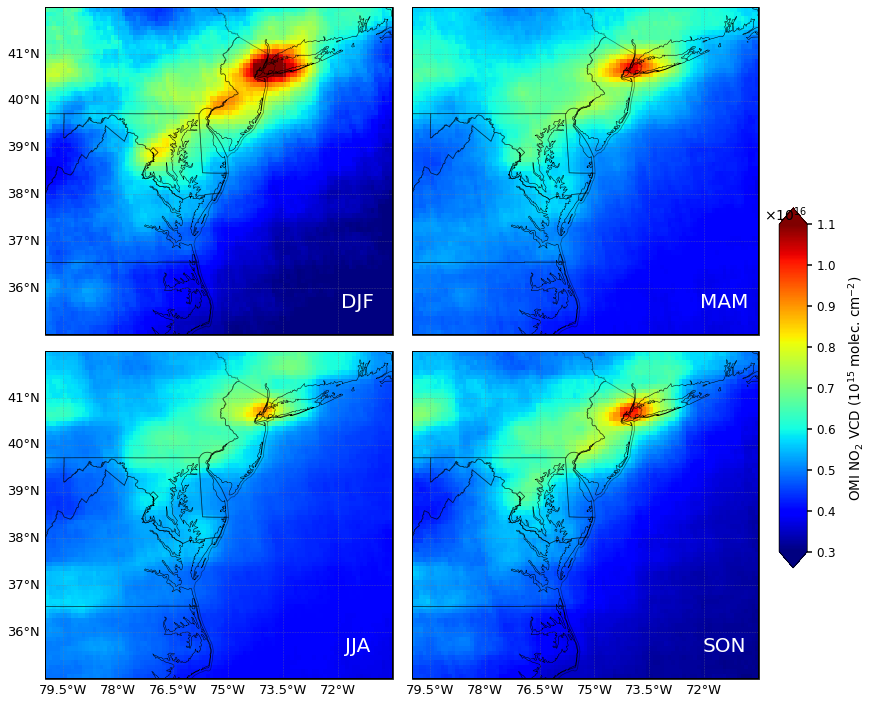

In [0]:
vmin = 3e+15
vmax = 11e+15
cmap = "jet"
alpha = 1

plt.rcParams.update({'font.size': 14})

fig, axes = plt.subplots(2, 2, figsize=(13, 10), 
                        subplot_kw={"projection": ccrs.PlateCarree()})
columns = ['DJF', 'MAM', "JJA", "SON"]
current_col = 0

for ax, col in zip(axes.ravel(), columns):
    ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    if current_col not in [0, 2]:
        gl.left_labels = False

    if current_col not in [2, 3]:
        gl.bottom_labels = False
    
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 13}
    gl.ylabel_style = {'size': 13}

    
    bounding_box.geometry.boundary.plot(ax=ax, color='black', linewidth=2, alpha=1, transform=ccrs.PlateCarree())
    us_states.geometry.boundary.plot(ax=ax, color='black', linewidth=0.75, alpha=0.45, transform=ccrs.PlateCarree())

    fishnet_x.plot(ax=ax, column=col, alpha=alpha, linewidth=0, edgecolor=None, cmap=cmap,
                   missing_kwds=dict(color='grey', label='No Data'), vmin=vmin, vmax=vmax, legend=False)
    
    ax.annotate(col, xy=(0.9, 0.1), xycoords='axes fraction', fontsize=20, ha='center', va='center', color="white", fontweight="normal")

    ax.tick_params(labelsize=20)
    ax.spines['bottom'].set_color('black')
    ax.spines['top'].set_color('black') 
    ax.spines['right'].set_color('black')
    ax.spines['right'].set_linewidth(2)
    ax.spines['top'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_color('black')
    ax.spines['left'].set_lw(2) 
    ax.tick_params(which='both', width=3)
    ax.tick_params(which='major', length=6)
    ax.tick_params(which='minor', length=6)
    ax.tick_params(which = 'both', direction = 'in')
    current_col += 1

cax = fig.add_axes([0.905, 0.2, 0.03, 0.5])  
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []
cbar = fig.colorbar(sm, cax=cax, orientation='vertical', extend='both')
cbar.set_label('OMI NO$_2$ VCD ($10^{15}$ molec. $\mathregular{cm^{-2}}$)', 
               fontsize=13.5, labelpad=10, fontweight='normal')
cbar.ax.tick_params(length=5, width=1.5, which="major", direction='out', labelsize=12)
cbar.set_alpha(alpha)
cbar.draw_all()
cbar.formatter.set_useMathText(True)
plt.tight_layout()
plt.subplots_adjust(hspace=0.05, wspace=-0.315)  
plt.show()  

If we look at this plot, we see that NO2 pollution is very high during winter and less during summer season. During winter, people use more fossil fuel for heating their homes, their cars, buildings, and the cold traps NO2 and prevents it from reacting with sun and that way, less NO2 converts to Ozone. In summer, more sunglight leads to faster/higher NO2 conversion to ozone. This is a very important pattern of NO2. Lets look for each month by calculating monthly average. We should see similar pattern.

In [0]:
newyork_spark_df.show(5)

+-------------------+----+-----+---+----------+-------+---------------+
|               date|year|month|day|year_month|dayname|ColumnAmountNO2|
+-------------------+----+-----+---+----------+-------+---------------+
|2018-01-02 00:00:00|2018|    1|  2|   2018-01|Tuesday|   1.5205864E16|
|2018-01-02 00:00:00|2018|    1|  2|   2018-01|Tuesday|    7.829908E15|
|2018-01-02 00:00:00|2018|    1|  2|   2018-01|Tuesday|     1.80972E16|
|2018-01-02 00:00:00|2018|    1|  2|   2018-01|Tuesday|   7.4386944E15|
|2018-01-02 00:00:00|2018|    1|  2|   2018-01|Tuesday|   1.3893254E16|
+-------------------+----+-----+---+----------+-------+---------------+
only showing top 5 rows



In [0]:
from pyspark.sql.functions import when, col

In [0]:
# extracting season based on month
newyork_spark_df = newyork_spark_df.withColumn(
    "season",
    when(col("month").isin(12, 1, 2), "Winter")
    .when(col("month").between(3, 5),  "Spring")
    .when(col("month").between(6, 8),  "Summer")
    .otherwise("Fall")
)

In [0]:
newyork_spark_df.show(10)

+-------------------+----+-----+---+----------+-------+---------------+------+
|               date|year|month|day|year_month|dayname|ColumnAmountNO2|season|
+-------------------+----+-----+---+----------+-------+---------------+------+
|2018-01-02 00:00:00|2018|    1|  2|   2018-01|Tuesday|   1.5205864E16|Winter|
|2018-01-02 00:00:00|2018|    1|  2|   2018-01|Tuesday|    7.829908E15|Winter|
|2018-01-02 00:00:00|2018|    1|  2|   2018-01|Tuesday|     1.80972E16|Winter|
|2018-01-02 00:00:00|2018|    1|  2|   2018-01|Tuesday|   7.4386944E15|Winter|
|2018-01-02 00:00:00|2018|    1|  2|   2018-01|Tuesday|   1.3893254E16|Winter|
|2018-01-02 00:00:00|2018|    1|  2|   2018-01|Tuesday|   6.9005114E15|Winter|
|2018-01-02 00:00:00|2018|    1|  2|   2018-01|Tuesday|   1.2546138E16|Winter|
|2018-01-02 00:00:00|2018|    1|  2|   2018-01|Tuesday|   1.2216347E16|Winter|
|2018-01-02 00:00:00|2018|    1|  2|   2018-01|Tuesday|   7.5599456E15|Winter|
|2018-01-02 00:00:00|2018|    1|  2|   2018-01|Tuesd

In [0]:
newyork_PDF = newyork_spark_df.toPandas() 

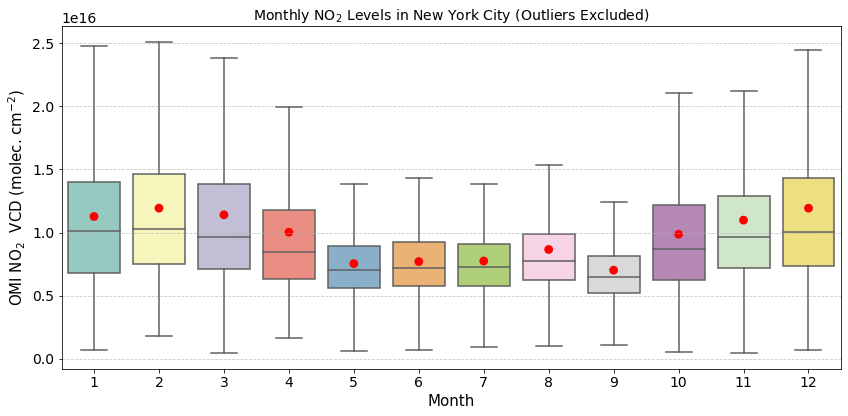

In [0]:
# monthly boxplot for OMI NO2 for all years for NYC

plt.figure(figsize=(12, 6))
sns.boxplot(data=newyork_PDF, x="month", y="ColumnAmountNO2", palette="Set3", showfliers=False)
sns.pointplot(data=newyork_PDF, x="month", y="ColumnAmountNO2", color="red", markers="o", linestyles="", ci=None, estimator=np.mean)
plt.title("Monthly NO$_2$ Levels in New York City (Outliers Excluded)", fontsize=14)
plt.xlabel("Month", fontsize=15)
plt.ylabel('OMI NO$_2$  VCD (molec. $\mathregular{cm^{-2}}$)', fontsize=15)
plt.grid(axis="y", linestyle="--", alpha=0.7)
ax.tick_params(labelsize=20)
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_color('black') 
ax.spines['right'].set_color('black')
ax.spines['right'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_color('black')
ax.spines['left'].set_lw(2) 
ax.tick_params(which='both', width=3)
ax.tick_params(which='major', length=6)
ax.grid(True, linestyle="--", alpha=0.5)
ax.tick_params(which='minor', length=6)
ax.tick_params(which = 'both', direction = 'in')
ax.yaxis.set_major_formatter(formatter)
ax.ticklabel_format(style='scientific', axis = 'y') 
t = ax.yaxis.get_offset_text()
t.set_size(15)
plt.tight_layout()
plt.show()

## 3.2 NO2 Pollution and Traffic Frequency Relation

For the Traffic Station Hourly Vehicle count data, we can download these from Federal Highway Administration data portal at: https://www.fhwa.dot.gov/policyinformation/tables/tmasdata/#y20.

The data is available for each month for Traffic stations accross the US highways at hourly level. These stations can be tolling stations, sensors on top of bridges, cameras etc. 

<b> I could not figure out how to put screenshots of data in my notebook on databricks. So, I uploaded those to drive and downloaded and included them in code cells instead.

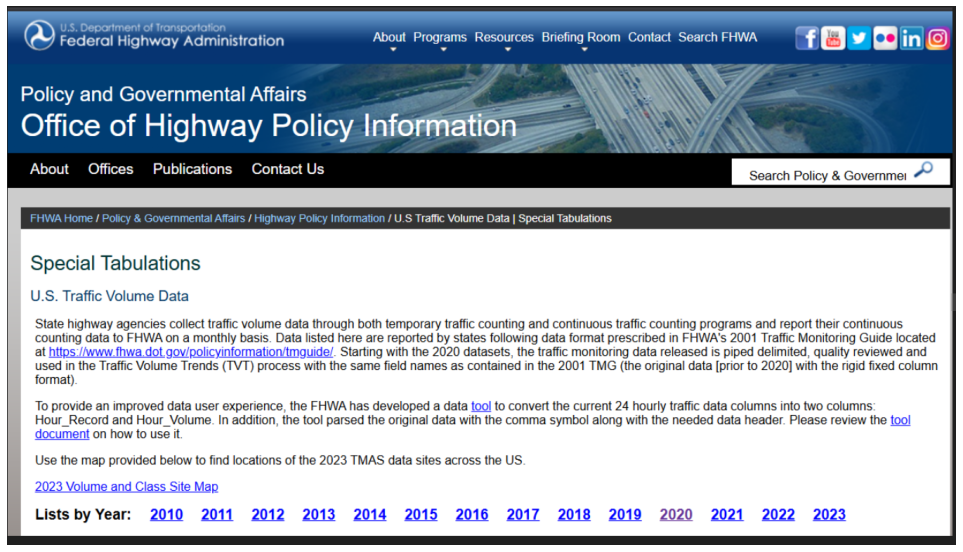

In [0]:
img = mpimg.imread('/databricks/driver/3.png')
plt.figure(figsize=(17, 10))
plt.imshow(img)
plt.axis('off') 
plt.show()

The data format looks like this:

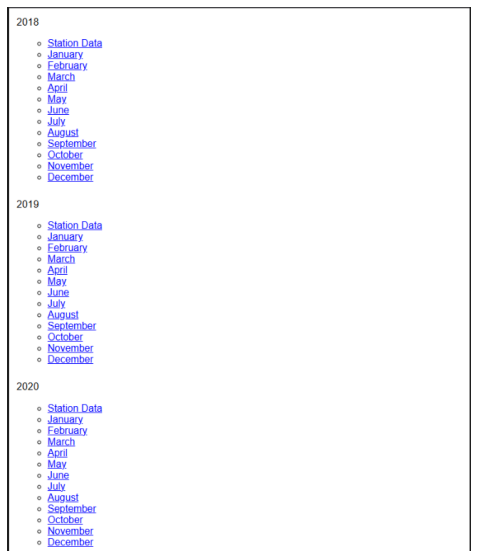

In [0]:
img = mpimg.imread('/databricks/driver/4.png')
plt.figure(figsize=(17, 10))
plt.imshow(img)
plt.axis('off') 
plt.show()

For each year, there is a distinct station data file, and data for each month. The station data file is a metadata file that contains location of stations, and their unique IDs, which can be joined to monthly file.

In [0]:
def process_station_data(filepath: str) :
    try:
        # reading the data using spark, doing some minor preprocessings
        station_data = spark.read.table(filepath)
        station_data = station_data.filter(station_data.Sample_Type_Volume == "T")
        station_data = station_data.withColumn("Latitude", col("Latitude") / 1000000)
        station_data = station_data.withColumn("Longitude", -col("Longitude") / 1000000)
        station_data = station_data.select(["Station_Id", "State_Code", "F_System", "Sample_Type_Volume", "Latitude", "Longitude", "County_Code", "Method_Volume"])
        station_data = station_data.toPandas()

        # creating shapely Point objects from geocordinates
        station_data["geometry"] = gpd.points_from_xy(station_data["Longitude"], station_data["Latitude"])
        station_data = gpd.GeoDataFrame(station_data, geometry="geometry", crs="EPSG:4326")  

        # only select the stations within the bounding box that is of interest to us
        station_data = gpd.sjoin(station_data, bounding_box, predicate="within")
        try:
            station_data.drop(columns=["index_right"], inplace=True)
        except:
            pass

        station_data.drop_duplicates(inplace=True)
        station_data.reset_index(drop=True, inplace=True)  
        return station_data
    
    except Exception as e:
        print("error occurred while processing station data: ", str(e))

In [0]:
%sql
SHOW TABLES;

database,tableName,isTemporary
default,epa_2019_hourly_no2_2_csv,false
default,epa_2020_hourly_no2_1_csv,false
default,epa_2021_hourly_no2_1_csv,false
default,omi_no2_1_csv,false
default,station_data_extract_pipe_delimited_cleandata_2019_1_txt,false
default,station_data_extract_pipe_delimited_cleandata_2020_1_txt,false
default,station_data_extract_pipe_delimited_cleandata_2021_1_txt,false
default,trafficdata_2019_eastcoast_1_csv,false
default,trafficdata_2020_eastcoast_1_csv,false
default,trafficdata_2020_eastcoast_2_csv,false


In [0]:
station_data_2019 = "station_data_extract_pipe_delimited_cleandata_2019_1_txt"
station_data_2020 = "station_data_extract_pipe_delimited_cleandata_2020_1_txt"
station_data_2021 = "station_data_extract_pipe_delimited_cleandata_2021_1_txt"

# reading station metadata for each year
station_data_2019 = process_station_data(station_data_2019)
station_data_2020 = process_station_data(station_data_2020)
station_data_2021 = process_station_data(station_data_2021)

In [0]:
station_data_2019

,Station_Id,State_Code,F_System,Sample_Type_Volume,Latitude,Longitude,County_Code,Method_Volume,geometry
0,004108,9,2U,T,41.544034,-73.033709,5,2,POINT (-73.03371 41.54403)
1,004204,9,2U,T,41.784930,-72.455197,13,2,POINT (-72.4552 41.78493)
2,004347,9,2U,T,41.372946,-72.430859,3,2,POINT (-72.43086 41.37295)
3,004933,9,1U,T,41.455102,-72.374396,3,2,POINT (-72.3744 41.4551)
4,004934,9,1U,T,41.454723,-72.380331,3,2,POINT (-72.38033 41.45472)
...,...,...,...,...,...,...,...,...,...
1934,840078,51,1R,T,37.676000,-77.655860,75,3,POINT (-77.65586 37.676)
1935,880032,51,1R,T,37.906020,-79.262630,163,3,POINT (-79.26263 37.90602)
1936,890045,51,1R,T,38.847860,-77.766100,61,3,POINT (-77.7661 38.84786)
1937,980188,51,1R,T,38.909970,-78.048930,61,3,POINT (-78.04893 38.90997)


In [0]:
# we will be filtering stations based on the states that fall inside our boundinng box
available_state_codes = station_data_2019["State_Code"].unique()

The monthly file contain hourly level vehicle count for each traffic station for number of vehicles (cars, trucks etc) that pass through it. This is daily data at hourly level. 
Each monthly folder contains individual files for each state. Concatenating everything becomes fairly large quickly. For instance, data files for all 50 states for 2020 is 1.07GB.

Up until 2020, the data files are stored in fixed-width format. Meaning, first few columns are metadata like station_id, date etc then, the remaining columns are hourly counts of traffic passing through the station. For this project, I have utilized data from 2019-2021 to see the trend of vehicle count versus NO2 pollution. 

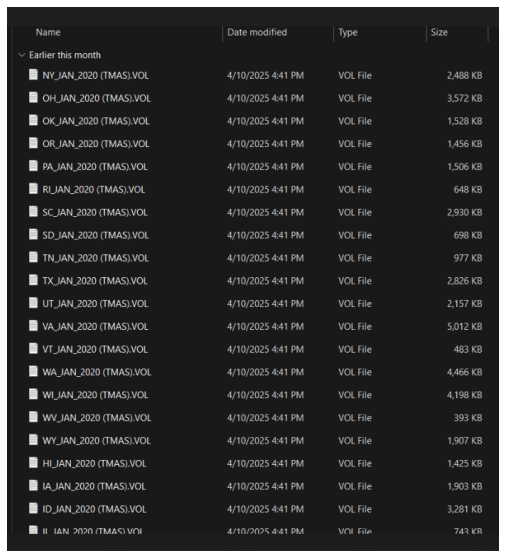

In [0]:
img = mpimg.imread('/databricks/driver/5.png')
plt.figure(figsize=(17, 10))
plt.imshow(img)
plt.axis('off') 
plt.show()

This is how the data for 2019/2020 looks like:

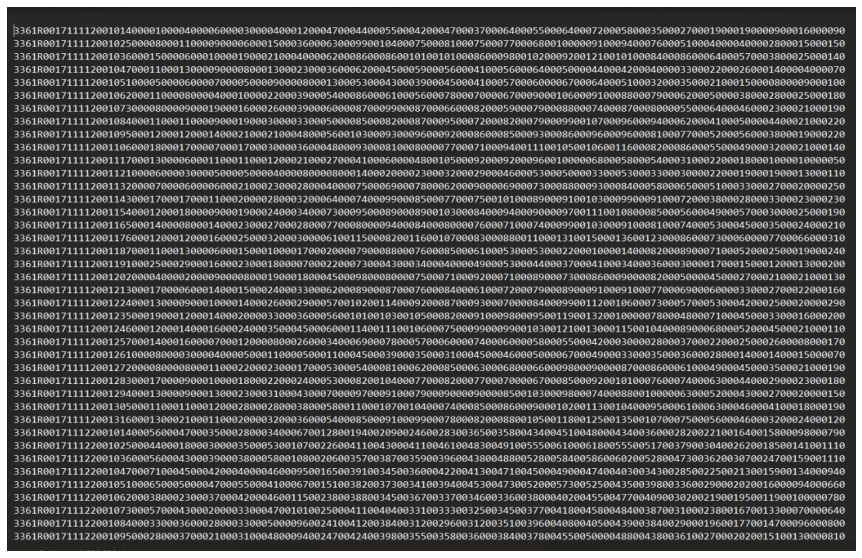

In [0]:
img = mpimg.imread('/databricks/driver/6.png')
plt.figure(figsize=(17, 10))
plt.imshow(img)
plt.axis('off') 
plt.show()

This is for 2021: 

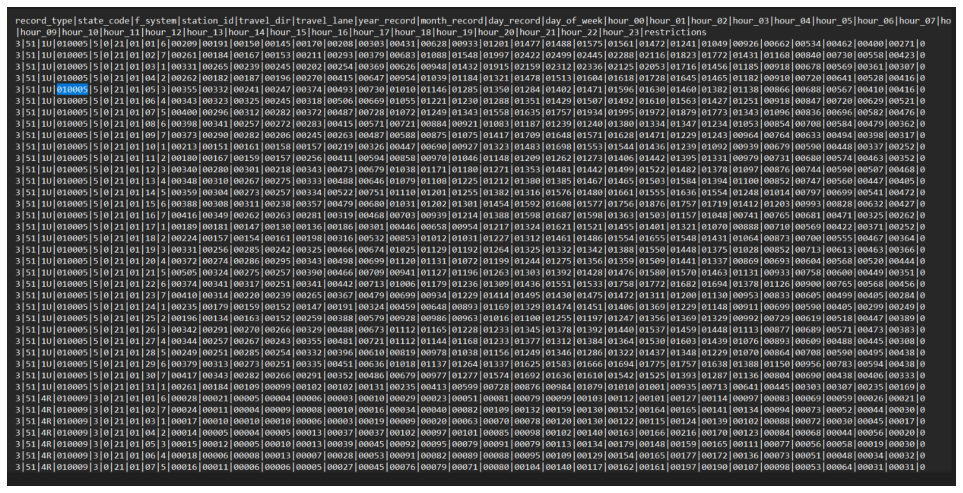

In [0]:
img = mpimg.imread('/databricks/driver/7.png')
plt.figure(figsize=(17, 10))
plt.imshow(img)
plt.axis('off') 
plt.show()

It is easy to work with data beyond 2020 as it is seperated by `|`. For 2019 and 2020, we need to do additional preprocessing to bring data to manageble state.

In [0]:
def process_data(filepath: str) -> pd.DataFrame:
    '''
    The hourly traffic frequency data is stored in a fixed-width format for years up to 2020. After 2020, the data is stored in seperated by |.
    Therefore, I will use this function to process data for 2019 and 2020. But, for 2021, I will directly use pd.read_csv() with sep = "|".
    '''
    try:
        widths = (
            [1, 2, 2, 6, 1, 1, 2, 2, 2, 1] +  # Metadata fields
            [5] * 24 +                         # 24 hourly counts (5 characters each)
            [1]                                # Restrictions field (no idea what it means; I did not find its meaning anywhere
        )

        col_names = (['record_type', 'state_code', 'functional_classification', 'station_id', 'direction_of_travel', 'lane_of_travel', 'year', 'month', 'day', 'day_of_week'] +
            [f'hour_{i:02d}' for i in range(24)] +  # Hourly counts from hour_00 to hour_23
            ['restrictions'] 
        )


        traffic_frequency_df = pd.read_fwf(filepath, widths=widths, header=None, names=col_names)
        traffic_frequency_df['year'] = traffic_frequency_df['year'].apply(lambda x: 2000 + int(x) if str(x).isdigit() else x)

        for col in [f'hour_{i:02d}' for i in range(24)]:
            traffic_frequency_df[col] = pd.to_numeric(traffic_frequency_df[col], errors='coerce')

        traffic_frequency_df = traffic_frequency_df[traffic_frequency_df.state_code.isin(available_state_codes)]

        useful_cols = [
            "station_id",
            "year",
            "month",
            "day",
            "day_of_week",
            ] + [
                f"hour_{i:02d}" for i in range(24)
        ]
        traffic_frequency_df = traffic_frequency_df[useful_cols]
        return traffic_frequency_df
    
    except Exception as e:
        print("error occurred while processing data: ", str(e))

In [0]:
def process_traffic_frequency_data_for_year(file_path: str) -> pd.DataFrame:
    '''
    Given a file path, this function will process the traffic frequency data for the given year.
    '''
    try:
        files = os.listdir(file_path)
        files = [os.path.join(file_path, file) for file in files]

        traffic_df = pd.DataFrame()

        for file in tqdm(files):
            temp_df = process_data(file)
            traffic_df = pd.concat([traffic_df, temp_df], ignore_index=True)

        traffic_df.reset_index(drop=True, inplace=True)

        return traffic_df
    
    except Exception as e:
        print("error occurred while processing traffic frequency data for year: ", str(e))

<B> Each year has 50 states and territories * 12 Months number of files, which is 600+ files. Reading through files and processing them takes ~5 minutes. Therefore, I used the function above to process files and then export them as parquet files for 2019 and 2020 for ease. You can download files and run the above function to process in case you want to test for other days. Since I will need to run this notebook multiple times (this project cannot be completed in one sitting), I will read the exported parquet file for ease.

In [0]:
# file_path = r"C:\Users\neupa\Downloads\Traffic Data\2019\Traffic_Frequency"
# traffic_df_2019 = process_traffic_frequency_data_for_year(file_path)
# traffic_df_2019["station_id"] = traffic_df_2019["station_id"].astype(str)
# traffic_df_2019.to_parquet("TrafficData_2019_EastCoast.parquet")

In [0]:
# file_path = r"C:\Users\neupa\Downloads\Traffic Data\2020\Traffic_Frequency"
# traffic_df_2020 = process_traffic_frequency_data_for_year(file_path)
# traffic_df_2020["station_id"] = traffic_df_2020["station_id"].astype(str)
# traffic_df_2020.to_parquet("TrafficData_2020_EastCoast.parquet")

In [0]:
# this is the column format for data beyong 2020
header = "record_type|state_code|f_system|station_id|travel_dir|travel_lane|year_record|month_record|day_record|day_of_week|hour_00|hour_01|hour_02|hour_03|hour_04|hour_05|hour_06|hour_07|hour_08|hour_09|hour_10|hour_11|hour_12|hour_13|hour_14|hour_15|hour_16|hour_17|hour_18|hour_19|hour_20|hour_21|hour_22|hour_23|restrictions"
header = header.split("|")
header = [col.strip() for col in header]

def read_traffic_file(file_path: str) -> pd.DataFrame:
    '''
    Given a file path, this function will read the traffic data for the given year.
    '''
    try:
        files = os.listdir(file_path)
        files = [os.path.join(file_path, file) for file in files]
        traffic_df = pd.DataFrame()    
        
        for file in tqdm(files):
            try:
                df = pd.read_csv(file, sep="|")
            except:
                df = pd.read_csv(file, sep="|", header=None, names=header)
            
            df = df[df.state_code.isin(available_state_codes)]
            traffic_df = pd.concat([traffic_df, df], ignore_index=True)

        traffic_df.reset_index(drop=True, inplace=True)
        traffic_df["station_id"] = traffic_df["station_id"].astype(str)
        return traffic_df
    
    except Exception as e:
        print("error occurred while reading traffic file: ", str(e))

<b> The same applies to 2021 data. The only difference is that we already have data in seperated format. All we need to do is read them individually and concatenate them, which takes ~5 minutes. Therefore, for this year as well, I ran the function once and exported the dataframe as parquet file, and will read that file for ease.

In [0]:
# file_path = r"C:\Users\neupa\Downloads\Traffic Data\2021\Traffic_Frequency"
# traffic_df_2021 = read_traffic_file(file_path)
# traffic_df_2021.to_parquet("TrafficData_2021_EastCoast.parquet")

In [0]:
from pyspark.sql.types import IntegerType

In [0]:
%sql
SHOW TABLES;

database,tableName,isTemporary
default,epa_2019_hourly_no2_2_csv,false
default,epa_2020_hourly_no2_1_csv,false
default,epa_2021_hourly_no2_1_csv,false
default,omi_no2_1_csv,false
default,station_data_extract_pipe_delimited_cleandata_2019_1_txt,false
default,station_data_extract_pipe_delimited_cleandata_2020_1_txt,false
default,station_data_extract_pipe_delimited_cleandata_2021_1_txt,false
default,trafficdata_2019_eastcoast_1_csv,false
default,trafficdata_2020_eastcoast_1_csv,false
default,trafficdata_2020_eastcoast_2_csv,false


In [0]:
# reading exported traffic parquet file for 2019
traffic_df_2019 = spark.read.table("trafficdata_2019_eastcoast_1_csv")
traffic_df_2019 = traffic_df_2019.withColumnRenamed("station_id", "Station_Id")

In [0]:
traffic_df_2019.show(5)

+----------+----+-----+---+-----------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+
|Station_Id|year|month|day|day_of_week|hour_00|hour_01|hour_02|hour_03|hour_04|hour_05|hour_06|hour_07|hour_08|hour_09|hour_10|hour_11|hour_12|hour_13|hour_14|hour_15|hour_16|hour_17|hour_18|hour_19|hour_20|hour_21|hour_22|hour_23|
+----------+----+-----+---+-----------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+
|      9007|2019|    1|  2|          4|  235.0|  164.0|  128.0|  144.0|  222.0|  391.0|  731.0|  910.0|  878.0|  828.0|  904.0|  894.0|  950.0| 1078.0| 1202.0| 1330.0| 1363.0| 1251.0|  876.0|  632.0|  562.0|  464.0|  344.0|  350.0|
|      9007|2019|    1|  3|          5|  226.0|  167.0|  144.0|  141.0| 

This is how our traffic frequency data looks like. Since we have station_id, we can join this with our station data.

In [0]:
# reading exported traffic parquet file for 2020
traffic_df_2020 = spark.read.table("trafficdata_2020_eastcoast_2_csv")
traffic_df_2020 = traffic_df_2020.withColumnRenamed("station_id", "Station_Id")

In [0]:
traffic_df_2020.show()

+----------+----+-----+---+-----------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+
|Station_Id|year|month|day|day_of_week|hour_00|hour_01|hour_02|hour_03|hour_04|hour_05|hour_06|hour_07|hour_08|hour_09|hour_10|hour_11|hour_12|hour_13|hour_14|hour_15|hour_16|hour_17|hour_18|hour_19|hour_20|hour_21|hour_22|hour_23|
+----------+----+-----+---+-----------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+
|      9024|2020|    4|  2|          5|  178.0|  128.0|  138.0|  162.0|  199.0|  324.0|  556.0|  655.0|  659.0|  614.0|  642.0|  708.0|  692.0|  746.0|  774.0|  865.0|  866.0|  788.0|  623.0|  502.0|  362.0|  271.0|  224.0|  229.0|
|      9024|2020|    4|  3|          6|  186.0|  125.0|  143.0|  166.0| 

In [0]:
# reading exported traffic parquet file for 2021
traffic_df_2021 = spark.read.table('trafficdata_2021_eastcoast_1_csv')
traffic_df_2021 = traffic_df_2021.withColumnRenamed("station_id", "Station_Id")
traffic_df_2021.show(5)

+-----------+----------+--------+----------+----------+-----------+-----------+------------+----------+-----------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+------------+
|record_type|state_code|f_system|Station_Id|travel_dir|travel_lane|year_record|month_record|day_record|day_of_week|hour_00|hour_01|hour_02|hour_03|hour_04|hour_05|hour_06|hour_07|hour_08|hour_09|hour_10|hour_11|hour_12|hour_13|hour_14|hour_15|hour_16|hour_17|hour_18|hour_19|hour_20|hour_21|hour_22|hour_23|restrictions|
+-----------+----------+--------+----------+----------+-----------+-----------+------------+----------+-----------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+------------+
|          3|         9|      4R|    

If we look here, the year_record column is 21. The FHA seems to be keeping the number of years beyond 2000 to identify the year. So, we can add 2000 to this to bring it to the actual year value.

In [0]:
# for some reason, the year in 2021 FHA data contains value 21 instead of 2021. So, adding 2000 to it to get the correct year
traffic_df_2021 = traffic_df_2021.withColumn("year_record", col("year_record").cast(IntegerType()))
traffic_df_2021 = traffic_df_2021.withColumn("year_record", col("year_record") + 2000)

In [0]:
traffic_df_2021.show(5)

+-----------+----------+--------+----------+----------+-----------+-----------+------------+----------+-----------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+------------+
|record_type|state_code|f_system|Station_Id|travel_dir|travel_lane|year_record|month_record|day_record|day_of_week|hour_00|hour_01|hour_02|hour_03|hour_04|hour_05|hour_06|hour_07|hour_08|hour_09|hour_10|hour_11|hour_12|hour_13|hour_14|hour_15|hour_16|hour_17|hour_18|hour_19|hour_20|hour_21|hour_22|hour_23|restrictions|
+-----------+----------+--------+----------+----------+-----------+-----------+------------+----------+-----------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+------------+
|          3|         9|      4R|    

Perfect. Now lets bring in EPA NO2 data.

<b> Why EPA? OMI NO2 is satellite measurement that is only available at daily level (not hourly level). Furthermore, each NO2 measurement is for almost 100KM square area. That is pretty big area by itself and trying to see how each traffic station is contributing to NO2 becomes very difficult to quantify as there will be way many NO2 sources besides traffic in that big of an area. 

EPA refers to Environmental Protection Agency. They have NO2 measurements through their network of ground based sensors. So, what I will do is, select a FHA station (or multiple), choose EPA NO2 sensors nearest to the FHA station, and compare traffic frequency with NO2. This is the closest we can do the comparision between Traffic and NO2 pollution in this project. Still, the FHA station counts the number of traffic passing through it. There can be multiple NO2 emitting sources nearby. And, i there are 2 FHA stations very close, a vehicle passing through both of them will be counted twice. Therefore, it is impossible to quantify the sole impact of traffic with respect to NO2 pollution in this project. However, it is a general estimate we can use to understand the relationship.

You can download EPA daily Hourly/Daily ground sensor-based NO2 data from their official website: https://aqs.epa.gov/aqsweb/airdata/download_files.html

In [0]:
from pyspark.sql.functions import col, substring

In [0]:
min_lat, max_lat, min_lon, max_lat

Out[163]: (35, 42, -80, 42)

In [0]:
from pyspark.sql.functions import hour

In [0]:
# for some reason, Databricks PySpark does not acces numpy arrays to do comparision
# I waas able to do those in my local PC. So, converting these to raw python list and integers for state_ids in east coast.
available_state_codes = list(available_state_codes)
available_state_codes = [int(x) for x in available_state_codes]

In [0]:
def process_EPA_NO2_data(tableName: str) -> pyspark.sql.DataFrame:
    '''
    Given a file path, this function will process the EPA NO2 data for the given year.
    '''
    try:
        epa_df = spark.read.table(tableName)
        epa_df = epa_df.withColumn("Hour", hour("Time Local"))
        epa_df = epa_df.filter(col("Sample Measurement") >= 0)

        # spark is reading cordinates as double, but we need them as float
        epa_df = epa_df.withColumn("Latitude", col("Latitude").cast("float"))
        epa_df = epa_df.withColumn("Longitude", col("Longitude").cast("float"))

        # we only need EPA NO2 sensors for our bounding box
        epa_df = epa_df.filter(
            (col("Latitude") >= min_lat) & (col("Latitude") <= max_lat) &
            (col("Longitude") >= min_lon) & (col("Longitude") <= max_lon)
        )
        epa_df = epa_df.select(["Site Num", "Date Local", "Time Local", "Hour", "Date GMT", "Time GMT", "Latitude", "Longitude", "Sample Measurement"])
        return epa_df
    
    except Exception as e:
        print("error occurred while processing EPA NO2 data: ", str(e))

In [0]:
%sql

SHOW TABLES;

database,tableName,isTemporary
default,epa_2019_hourly_no2_2_csv,false
default,epa_2020_hourly_no2_1_csv,false
default,epa_2021_hourly_no2_1_csv,false
default,omi_no2_1_csv,false
default,station_data_extract_pipe_delimited_cleandata_2019_1_txt,false
default,station_data_extract_pipe_delimited_cleandata_2020_1_txt,false
default,station_data_extract_pipe_delimited_cleandata_2021_1_txt,false
default,trafficdata_2019_eastcoast_1_csv,false
default,trafficdata_2020_eastcoast_1_csv,false
default,trafficdata_2020_eastcoast_2_csv,false


In [0]:
epa_2019_path = "epa_2019_hourly_no2_2_csv"
epa_2020_path = "epa_2020_hourly_no2_1_csv"
epa_2021_path = "epa_2021_hourly_no2_1_csv"

In [0]:
# reading and processing EPA NO2 data for 2020, 2021 and 2019
epa_2019_spark_df = process_EPA_NO2_data(epa_2019_path)

In [0]:
epa_2019_spark_df.show(1)

+--------+----------+----------+----+----------+--------+---------+---------+------------------+
|Site Num|Date Local|Time Local|Hour|  Date GMT|Time GMT| Latitude|Longitude|Sample Measurement|
+--------+----------+----------+----+----------+--------+---------+---------+------------------+
|    9003|2019-01-01|     00:00|   0|2019-01-01|   05:00|41.118332|-73.33667|               2.3|
+--------+----------+----------+----+----------+--------+---------+---------+------------------+
only showing top 1 row



In [0]:
# reading and processing EPA NO2 data for 2020, 2021 and 2019
epa_2020_spark_df = process_EPA_NO2_data(epa_2020_path)

In [0]:
epa_2020_spark_df.show(1)

+--------+----------+----------+----+----------+--------+---------+---------+------------------+
|Site Num|Date Local|Time Local|Hour|  Date GMT|Time GMT| Latitude|Longitude|Sample Measurement|
+--------+----------+----------+----+----------+--------+---------+---------+------------------+
|    9003|2020-01-01|     00:00|   0|2020-01-01|   05:00|41.118332|-73.33667|               4.0|
+--------+----------+----------+----+----------+--------+---------+---------+------------------+
only showing top 1 row



In [0]:
# reading and processing EPA NO2 data for 2020, 2021 and 2019
epa_2021_spark_df = process_EPA_NO2_data(epa_2021_path) 

In [0]:
epa_2021_spark_df.show(1)

+--------+----------+----------+----+----------+--------+---------+---------+------------------+
|Site Num|Date Local|Time Local|Hour|  Date GMT|Time GMT| Latitude|Longitude|Sample Measurement|
+--------+----------+----------+----+----------+--------+---------+---------+------------------+
|    9003|2021-01-01|     00:00|   0|2021-01-01|   05:00|41.118332|-73.33667|              18.2|
+--------+----------+----------+----+----------+--------+---------+---------+------------------+
only showing top 1 row



In [0]:
# these unique epa stations will be used to collocate nearest FHA stations
unique_epa_stations = epa_2020_spark_df.select(["Site Num", "Latitude", "Longitude"]).dropDuplicates(["Site Num", "Latitude", "Longitude"])
unique_epa_stations.show()

+--------+---------+----------+
|Site Num| Latitude| Longitude|
+--------+---------+----------+
|      43| 38.92185|-77.013176|
|      50|38.970093|-77.016716|
|      25|41.771442|-72.679924|
|       9|39.371677| -76.74681|
|      41|38.895573| -76.95807|
|    2004|39.739464|-75.557556|
|    9003|41.118332| -73.33667|
|    1003| 41.78472| -72.63167|
|      27|  41.3014| -72.90287|
|      51| 38.89477| -76.95342|
|       2| 39.70595|   -79.012|
|       6| 39.14313| -76.84611|
|    3001|39.310833| -76.47444|
|      40|39.297733| -76.60461|
|      30| 39.05528|-76.878334|
|       7| 39.42227| -75.02521|
|       6| 40.67025| -74.12608|
|       3| 40.72099|-74.192894|
|      11| 40.46218|-74.429436|
|      10| 40.85355| -73.96618|
+--------+---------+----------+
only showing top 20 rows



In [0]:
epa_2019_spark_df.select("Sample Measurement").describe().show()

+-------+------------------+
|summary|Sample Measurement|
+-------+------------------+
|  count|            487816|
|   mean| 9.600482355138434|
| stddev| 9.110583484459518|
|    min|               0.0|
|    max|             110.2|
+-------+------------------+



In [0]:
epa_2020_spark_df.select("Sample Measurement").describe().show()

+-------+------------------+
|summary|Sample Measurement|
+-------+------------------+
|  count|            510771|
|   mean|  8.58233474514237|
| stddev|  8.37753650864048|
|    min|               0.0|
|    max|              91.7|
+-------+------------------+



In [0]:
epa_2020_spark_df.select("Sample Measurement").describe().show()

+-------+------------------+
|summary|Sample Measurement|
+-------+------------------+
|  count|            510771|
|   mean|  8.58233474514237|
| stddev|  8.37753650864048|
|    min|               0.0|
|    max|              91.7|
+-------+------------------+



In [0]:
unique_epa_stations = unique_epa_stations.toPandas() # need to revert back to geopandas
unique_epa_stations["geometry"] = gpd.points_from_xy(unique_epa_stations["Longitude"], unique_epa_stations["Latitude"])
unique_epa_stations = gpd.GeoDataFrame(unique_epa_stations, geometry="geometry", crs="EPSG:4326")

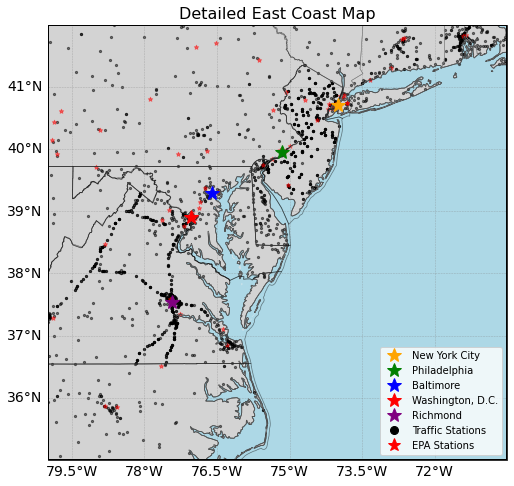

In [0]:
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=0.5)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# Plot Maryland boundary
us_states.geometry.boundary.plot(ax=ax, color='black', linewidth=0.75, alpha=0.45, transform=ccrs.PlateCarree())
bounding_box.geometry.boundary.plot(ax=ax, color='black', linewidth=2, alpha=1, transform=ccrs.PlateCarree())

colors = ['blue', 'green', 'red', 'purple', 'orange']
for color, (idx, row) in zip(colors, major_cities_points.iterrows()):
    ax.plot(row.geometry.x, row.geometry.y, marker='*', markersize=15, color=color, alpha=1,
            transform=ccrs.PlateCarree())

from matplotlib.lines import Line2D
city_handles = [
    Line2D([0], [0], marker='*', linestyle='None', markerfacecolor='orange',
              markeredgecolor='orange', label='New York City', markersize=15),

    Line2D([0], [0], marker='*', linestyle='None', markerfacecolor='green',
           markeredgecolor='green', label='Philadelphia', markersize=15),
        
    Line2D([0], [0], marker='*', linestyle='None', markerfacecolor='blue',
           markeredgecolor='blue', label='Baltimore', markersize=15),
    
    Line2D([0], [0], marker='*', linestyle='None', markerfacecolor='red',
           markeredgecolor='red', label='Washington, D.C.', markersize=15),
    Line2D([0], [0], marker='*', linestyle='None', markerfacecolor='purple',
           markeredgecolor='purple', label='Richmond', markersize=15),

]
station_data_2020.plot(ax=ax, color='black', markersize=5, alpha=0.5, label="Traffic Stations")
station_legend = Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='black',
                                          markeredgecolor='black', label='Traffic Stations', markersize=8)


unique_epa_stations.plot(ax=ax, color='red', markersize=20, alpha=0.5, label="EPA Stations", marker="*")
epa_legend = Line2D([0], [0], marker='*', linestyle='None', markerfacecolor='red',
                                          markeredgecolor='red', label='EPA Stations', markersize=13.5)
city_handles.append(station_legend)
city_handles.append(epa_legend)
ax.legend(handles=city_handles, loc='lower right', fontsize=10, frameon=True)
plt.title("Detailed East Coast Map", fontsize=16)
plt.show()

<b> For this particular analysis, I will only focus on FHA-Traffic and EPA-NO2 stations in New York City Area.

In [0]:
# getting unique EPA stations that fall inside NYC
nyc_gdf = city_geometries[city_geometries["City"] == "New York City"]

# selecting only the unique EPA stations that fall inside NYC Polygon
epa_sensor_within_nyc = gpd.sjoin(unique_epa_stations, nyc_gdf, predicate="within")

try:
    epa_sensor_within_nyc.drop(columns=["index_right"], inplace=True)
except:
    pass

In [0]:
epa_sensor_within_nyc

,Site Num,Latitude,Longitude,geometry,City
23,110,40.816002,-73.902000,POINT (-73.902 40.816),New York City
26,133,40.867901,-73.878090,POINT (-73.87809 40.8679),New York City
27,125,40.739265,-73.817696,POINT (-73.8177 40.73927),New York City
28,124,40.736141,-73.821533,POINT (-73.82153 40.73614),New York City


In [0]:
# getting closest FHA station to the EPA stations within NYC using geopandas
closest_FHA_station_near_EPA_Station = gpd.sjoin_nearest(epa_sensor_within_nyc, station_data_2020[["Station_Id", "geometry", "Latitude",    "Longitude"]], how='left', distance_col='distance_meters')

In [0]:
# creating point object from lat and lon
closest_FHA_station_near_EPA_Station["geometry"] = gpd.points_from_xy(closest_FHA_station_near_EPA_Station["Longitude_right"], \
                                closest_FHA_station_near_EPA_Station["Latitude_right"])

In [0]:
# getting the closest FHA stations to the ground based EPA NO2 stations inside NYC
closest_FHA_station_near_EPA_Station = gpd.GeoDataFrame(closest_FHA_station_near_EPA_Station, geometry="geometry", crs="EPSG:4326")

try:
    closest_FHA_station_near_EPA_Station.drop(columns=["index_right"], inplace=True)
except:
    pass

In [0]:
closest_FHA_station_near_EPA_Station

,Site Num,Latitude_left,Longitude_left,geometry,City,Station_Id,Latitude_right,Longitude_right,distance_meters
23,110,40.816002,-73.902000,POINT (-73.9063 40.84513),New York City,000199,40.845130,-73.90630,0.029444
26,133,40.867901,-73.878090,POINT (-73.88471 40.89246),New York City,000180,40.892460,-73.88471,0.025436
27,125,40.739265,-73.817696,POINT (-73.82038 40.74045),New York City,000580,40.740446,-73.82038,0.002933
28,124,40.736141,-73.821533,POINT (-73.82038 40.74045),New York City,000580,40.740446,-73.82038,0.004457


In [0]:
epa_sensor_within_nyc

,Site Num,Latitude,Longitude,geometry,City
23,110,40.816002,-73.902000,POINT (-73.902 40.816),New York City
26,133,40.867901,-73.878090,POINT (-73.87809 40.8679),New York City
27,125,40.739265,-73.817696,POINT (-73.8177 40.73927),New York City
28,124,40.736141,-73.821533,POINT (-73.82153 40.73614),New York City


Out[188]: <matplotlib.legend.Legend at 0x7f7f64351400>

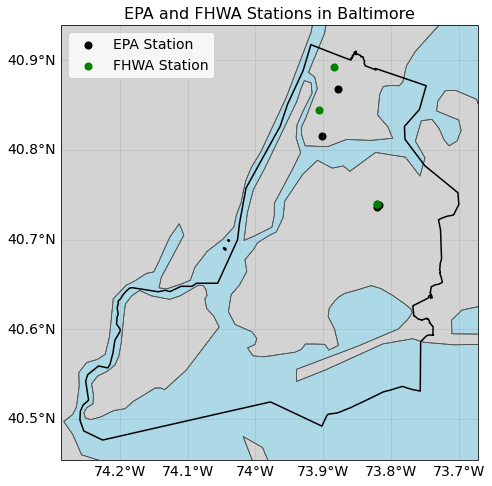

In [0]:
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=0.5)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

nyc_gdf.geometry.boundary.plot(ax=ax, color='black')
epa_sensor_within_nyc.plot(ax=ax, color="black", markersize=50, alpha=1, label="EPA Station")
closest_FHA_station_near_EPA_Station.plot(ax=ax, color="green", markersize=50, alpha=1, label="FHWA Station")    
ax.set_title("EPA and FHWA Stations in Baltimore", fontsize=16)
ax.legend(loc="upper left")

In [0]:
unique_FHA_stations = closest_FHA_station_near_EPA_Station["Station_Id"].map(int).map(str)

In [0]:
traffic_df_2019.show(5)

+----------+----+-----+---+-----------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+
|Station_Id|year|month|day|day_of_week|hour_00|hour_01|hour_02|hour_03|hour_04|hour_05|hour_06|hour_07|hour_08|hour_09|hour_10|hour_11|hour_12|hour_13|hour_14|hour_15|hour_16|hour_17|hour_18|hour_19|hour_20|hour_21|hour_22|hour_23|
+----------+----+-----+---+-----------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+
|      9007|2019|    1|  2|          4|  235.0|  164.0|  128.0|  144.0|  222.0|  391.0|  731.0|  910.0|  878.0|  828.0|  904.0|  894.0|  950.0| 1078.0| 1202.0| 1330.0| 1363.0| 1251.0|  876.0|  632.0|  562.0|  464.0|  344.0|  350.0|
|      9007|2019|    1|  3|          5|  226.0|  167.0|  144.0|  141.0| 

In [0]:
from pyspark.sql.functions import concat_ws, to_date

In [0]:
# get station data for only the stations inside NYC
traffic_df_2019_within_NY = traffic_df_2019.filter(col("Station_Id").isin(list(unique_FHA_stations)))

# concat year-month-day and make it date object
traffic_df_2019_within_NY = traffic_df_2019_within_NY.withColumn("date", to_date(concat_ws("-", col("year"), col("month"), col("day")), "yyyy-M-d"))

In [0]:
traffic_df_2019_within_NY.show(5)

+----------+----+-----+---+-----------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+----------+
|Station_Id|year|month|day|day_of_week|hour_00|hour_01|hour_02|hour_03|hour_04|hour_05|hour_06|hour_07|hour_08|hour_09|hour_10|hour_11|hour_12|hour_13|hour_14|hour_15|hour_16|hour_17|hour_18|hour_19|hour_20|hour_21|hour_22|hour_23|      date|
+----------+----+-----+---+-----------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+----------+
|       180|2019|    1|  1|          3|  606.0|  932.0|  795.0|  645.0|  578.0|  450.0|  467.0|  469.0|  444.0|  450.0|  556.0|  668.0|  879.0|  900.0| 1081.0| 1210.0| 1160.0| 1095.0|  978.0|  946.0|  927.0|  745.0|  705.0|  565.0|2019-01-01|
|       180|2019|    1|  2| 

Lets do the same for other years.

In [0]:
# getting   unique FHA stations that fall inside NYC
traffic_df_2020_within_NY = traffic_df_2020.filter(col("Station_Id").isin(list(unique_FHA_stations)))

# renaming columns to match names with other years which is essential as I will be concatenating these together
traffic_df_2020_within_NY = traffic_df_2020_within_NY.withColumnRenamed("year_record", "year")
traffic_df_2020_within_NY = traffic_df_2020_within_NY.withColumnRenamed("month_record", "month")
traffic_df_2020_within_NY = traffic_df_2020_within_NY.withColumnRenamed("day_record", "day")
traffic_df_2020_within_NY = traffic_df_2020_within_NY.withColumn("date", to_date(concat_ws("-", col("year"), col("month"), col("day")), "yyyy-M-d")) # get YYYY-MM-DD format
traffic_df_2020_within_NY.show(5)

+----------+----+-----+---+-----------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+----------+
|Station_Id|year|month|day|day_of_week|hour_00|hour_01|hour_02|hour_03|hour_04|hour_05|hour_06|hour_07|hour_08|hour_09|hour_10|hour_11|hour_12|hour_13|hour_14|hour_15|hour_16|hour_17|hour_18|hour_19|hour_20|hour_21|hour_22|hour_23|      date|
+----------+----+-----+---+-----------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+----------+
|       199|2020|    4|  1|          4|  412.0|  257.0|  202.0|  210.0|  332.0|  579.0|  888.0| 1031.0| 1030.0|  885.0|  918.0|  922.0|  963.0| 1045.0| 1121.0| 1128.0| 1215.0| 1128.0|  991.0|  825.0|  805.0|  603.0|  561.0|  547.0|2020-04-01|
|       199|2020|    4|  2| 

In [0]:
# getting unique FHA stations that fall inside NYC for 2021
traffic_df_2021_within_NY = traffic_df_2021.filter(col("Station_Id").isin(list(unique_FHA_stations)))

# renaming these columns for consistency
traffic_df_2021_within_NY = traffic_df_2021_within_NY.withColumnRenamed("year_record", "year")
traffic_df_2021_within_NY = traffic_df_2021_within_NY.withColumnRenamed("month_record", "month")
traffic_df_2021_within_NY = traffic_df_2021_within_NY.withColumnRenamed("day_record", "day")
traffic_df_2021_within_NY = traffic_df_2021_within_NY.withColumn("date", to_date(concat_ws("-", col("year"), col("month"), col("day")), "yyyy-M-d")) # get YYYY-MM-DD format
traffic_df_2021_within_NY.show(5)

+-----------+----------+--------+----------+----------+-----------+----+-----+---+-----------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+------------+----------+
|record_type|state_code|f_system|Station_Id|travel_dir|travel_lane|year|month|day|day_of_week|hour_00|hour_01|hour_02|hour_03|hour_04|hour_05|hour_06|hour_07|hour_08|hour_09|hour_10|hour_11|hour_12|hour_13|hour_14|hour_15|hour_16|hour_17|hour_18|hour_19|hour_20|hour_21|hour_22|hour_23|restrictions|      date|
+-----------+----------+--------+----------+----------+-----------+----+-----+---+-----------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+------------+----------+
|          3|        36|      1U|       180|         1|          1|

In [0]:
# no idea why this is happening
# for some reason, I need to typecast the result of a numpy array to original python integer. I did not get this error locally
# I got this  error: AttributeError: 'numpy.int32' object has no attribute '_get_object_id'
unique_epa_sites_within_NYC = [int(i) for i in epa_sensor_within_nyc["Site Num"].unique()]

In [0]:
# only selecting epa data for the EPA stations that are inside NYC 
epa_2020_within_NY = epa_2020_spark_df.filter(col("Site Num").isin(unique_epa_sites_within_NYC))
epa_2019_within_NY = epa_2019_spark_df.filter(col("Site Num").isin(unique_epa_sites_within_NYC))
epa_2021_within_NY = epa_2021_spark_df.filter(col("Site Num").isin(unique_epa_sites_within_NYC))

In [0]:
epa_2020_within_NY.show(5)

+--------+----------+----------+----+----------+--------+--------+---------+------------------+
|Site Num|Date Local|Time Local|Hour|  Date GMT|Time GMT|Latitude|Longitude|Sample Measurement|
+--------+----------+----------+----+----------+--------+--------+---------+------------------+
|     110|2020-01-01|     00:00|   0|2020-01-01|   05:00|  40.816|  -73.902|               9.7|
|     110|2020-01-01|     01:00|   1|2020-01-01|   06:00|  40.816|  -73.902|              10.1|
|     110|2020-01-01|     02:00|   2|2020-01-01|   07:00|  40.816|  -73.902|              10.0|
|     110|2020-01-01|     03:00|   3|2020-01-01|   08:00|  40.816|  -73.902|               9.8|
|     110|2020-01-01|     04:00|   4|2020-01-01|   09:00|  40.816|  -73.902|               9.7|
+--------+----------+----------+----+----------+--------+--------+---------+------------------+
only showing top 5 rows



Now, this is epa no2 data for 2020 for NYC only.

Let's get Year-Month-Day-Hour average NO2 for each year.

In [0]:
from pyspark.sql.functions import year, avg, count

In [0]:
def get_hourly_average_EPA_NO2(spark_dataframe: pyspark.sql.DataFrame) -> pyspark.sql.DataFrame:
    '''
    Given a spark dataframe, return the hourly average for the given year.
    '''
    try:
        # extractting year month and day from the date column
        spark_dataframe = spark_dataframe.withColumn("year", year("Date Local"))
        spark_dataframe = spark_dataframe.withColumn("month", month("Date Local")) 
        spark_dataframe = spark_dataframe.withColumn("day", dayofmonth("Date Local"))
        epa_hourly_average = spark_dataframe.groupBy("year", "month", "day", "Hour").agg(avg("Sample Measurement").alias("Sample Measurement"))\    
            .orderBy("year", "month", "day", "Hour")
        return epa_hourly_average
    
    except Exception as e:
        print("error occurred while getting hourly average for EPA NO2: ", str(e))

In [0]:
# get hourly averaged EPA for the selected stations inside NYC
epa_hourly_average_2020 = get_hourly_average_EPA_NO2(epa_2020_within_NY)
epa_hourly_average_2019 = get_hourly_average_EPA_NO2(epa_2019_within_NY)
epa_hourly_average_2021 = get_hourly_average_EPA_NO2(epa_2021_within_NY)

In [0]:
epa_hourly_average_2021.show()

+----+-----+---+----+------------------+
|year|month|day|Hour|Sample Measurement|
+----+-----+---+----+------------------+
|2021|    1|  1|   0|19.999999523162842|
|2021|    1|  1|   1| 21.47499990463257|
|2021|    1|  1|   2|23.949999809265137|
|2021|    1|  1|   3|23.074999809265137|
|2021|    1|  1|   4|25.075000286102295|
|2021|    1|  1|   5|             21.75|
|2021|    1|  1|   6|20.049999952316284|
|2021|    1|  1|   7|19.825000047683716|
|2021|    1|  1|   8|16.649999856948853|
|2021|    1|  1|   9|11.025000095367432|
|2021|    1|  1|  10|             7.375|
|2021|    1|  1|  11| 8.725000023841858|
|2021|    1|  1|  12| 8.450000166893005|
|2021|    1|  1|  13| 9.424999713897705|
|2021|    1|  1|  14|10.300000190734863|
|2021|    1|  1|  15|12.475000143051147|
|2021|    1|  1|  16| 14.02500033378601|
|2021|    1|  1|  17| 17.62500023841858|
|2021|    1|  1|  18|16.100000619888306|
|2021|    1|  1|  19|16.925000190734863|
+----+-----+---+----+------------------+
only showing top

Now that we have hourly/daily average EPA NO2 for our selected region, let get traffic frequency statistics as well.

In [0]:
traffic_df_2019_within_NY.show(5)

+----------+----+-----+---+-----------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+----------+
|Station_Id|year|month|day|day_of_week|hour_00|hour_01|hour_02|hour_03|hour_04|hour_05|hour_06|hour_07|hour_08|hour_09|hour_10|hour_11|hour_12|hour_13|hour_14|hour_15|hour_16|hour_17|hour_18|hour_19|hour_20|hour_21|hour_22|hour_23|      date|
+----------+----+-----+---+-----------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+----------+
|       180|2019|    1|  1|          3|  606.0|  932.0|  795.0|  645.0|  578.0|  450.0|  467.0|  469.0|  444.0|  450.0|  556.0|  668.0|  879.0|  900.0| 1081.0| 1210.0| 1160.0| 1095.0|  978.0|  946.0|  927.0|  745.0|  705.0|  565.0|2019-01-01|
|       180|2019|    1|  2| 

Since all the hours are in columns and wide format, lets melt it to bring in to row format such that each hour and value will be in rows inside two new columns.

In [0]:
from pyspark.sql.functions import regexp_extract

In [0]:
def melt_spark_dataframe(spark_dataframe: pyspark.sql.DataFrame) -> pyspark.sql.DataFrame:
    '''
    Given a spark dataframe, this function will melt the dataframe to get the hourly average for each day from wide format to row format.
    '''
    try:
        melted_dataframe = spark_dataframe.melt(
                ids= ['Station_Id', 'year', 'month', 'day', 'day_of_week', 'date'],
                values= [f'hour_{h:02d}' for h in range(24)],
                variableColumnName='hour_str',
                valueColumnName='traffic_count'
        )
        
        # extract hour from hour_str: hour_00 = 0
        melted_dataframe = melted_dataframe.withColumn('Hour', regexp_extract('hour_str', r'hour_(\d+)', 1).cast('int'))
        return melted_dataframe
    except Exception as e:
        print(f"Error in melting dataframe: {e}")
        return None

In [0]:
# convert the traffic data from wide format to row format
traffic_long_2019 = melt_spark_dataframe(traffic_df_2019_within_NY)

In [0]:
traffic_long_2019.show(5)

+----------+----+-----+---+-----------+----------+--------+-------------+----+
|Station_Id|year|month|day|day_of_week|      date|hour_str|traffic_count|Hour|
+----------+----+-----+---+-----------+----------+--------+-------------+----+
|       180|2019|    1|  1|          3|2019-01-01| hour_00|        606.0|   0|
|       180|2019|    1|  1|          3|2019-01-01| hour_01|        932.0|   1|
|       180|2019|    1|  1|          3|2019-01-01| hour_02|        795.0|   2|
|       180|2019|    1|  1|          3|2019-01-01| hour_03|        645.0|   3|
|       180|2019|    1|  1|          3|2019-01-01| hour_04|        578.0|   4|
+----------+----+-----+---+-----------+----------+--------+-------------+----+
only showing top 5 rows



Lets melt the dataframes for next 2 years as well.

In [0]:
# convert the traffic data from wide format to row format for 2020
traffic_long_2020 = melt_spark_dataframe(traffic_df_2020_within_NY)
traffic_long_2020.show(5)

+----------+----+-----+---+-----------+----------+--------+-------------+----+
|Station_Id|year|month|day|day_of_week|      date|hour_str|traffic_count|Hour|
+----------+----+-----+---+-----------+----------+--------+-------------+----+
|       199|2020|    4|  1|          4|2020-04-01| hour_00|        412.0|   0|
|       199|2020|    4|  1|          4|2020-04-01| hour_01|        257.0|   1|
|       199|2020|    4|  1|          4|2020-04-01| hour_02|        202.0|   2|
|       199|2020|    4|  1|          4|2020-04-01| hour_03|        210.0|   3|
|       199|2020|    4|  1|          4|2020-04-01| hour_04|        332.0|   4|
+----------+----+-----+---+-----------+----------+--------+-------------+----+
only showing top 5 rows



In [0]:
traffic_df_2021_within_NY.show(5)

+-----------+----------+--------+----------+----------+-----------+----+-----+---+-----------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+------------+----------+
|record_type|state_code|f_system|Station_Id|travel_dir|travel_lane|year|month|day|day_of_week|hour_00|hour_01|hour_02|hour_03|hour_04|hour_05|hour_06|hour_07|hour_08|hour_09|hour_10|hour_11|hour_12|hour_13|hour_14|hour_15|hour_16|hour_17|hour_18|hour_19|hour_20|hour_21|hour_22|hour_23|restrictions|      date|
+-----------+----------+--------+----------+----------+-----------+----+-----+---+-----------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+------------+----------+
|          3|        36|      1U|       180|         1|          1|

In [0]:
# convert the traffic data from wide format to row format for 2021
traffic_long_2021 = melt_spark_dataframe(traffic_df_2021_within_NY)
traffic_long_2021.show(5)

+----------+----+-----+---+-----------+----------+--------+-------------+----+
|Station_Id|year|month|day|day_of_week|      date|hour_str|traffic_count|Hour|
+----------+----+-----+---+-----------+----------+--------+-------------+----+
|       180|2021|    4|  4|          1|2021-04-04| hour_00|          713|   0|
|       180|2021|    4|  4|          1|2021-04-04| hour_01|          490|   1|
|       180|2021|    4|  4|          1|2021-04-04| hour_02|          318|   2|
|       180|2021|    4|  4|          1|2021-04-04| hour_03|          238|   3|
|       180|2021|    4|  4|          1|2021-04-04| hour_04|          208|   4|
+----------+----+-----+---+-----------+----------+--------+-------------+----+
only showing top 5 rows



In [0]:
# concatenate all traffic melted dataframes together to create a lineplot later on
traffic_long = traffic_long_2019.union(traffic_long_2020).union(traffic_long_2021)

In [0]:
epa_hourly_average_2020.show(1)

+----+-----+---+----+------------------+
|year|month|day|Hour|Sample Measurement|
+----+-----+---+----+------------------+
|2020|    1|  1|   0| 8.174999952316284|
+----+-----+---+----+------------------+
only showing top 1 row



In [0]:
# concatenate all epa dataframes together to craeate a line plot later on
epa_no2 = epa_hourly_average_2019.union(epa_hourly_average_2020).union(epa_hourly_average_2021)

In [0]:
# get average traffic frequency for each hour
traffic = traffic_long.groupBy("Hour").agg(avg("traffic_count").alias("traffic_count")).orderBy("Hour")

In [0]:
# get average EPA NO2 for each hour
no2 = epa_no2.groupBy("Hour").agg(avg("Sample Measurement").alias("Sample Measurement")).orderBy("Hour")

In [0]:
no2.show()

+----+------------------+
|Hour|Sample Measurement|
+----+------------------+
|   0|14.736093357649526|
|   1|14.387792998525105|
|   2|  14.3458066873173|
|   3|14.856339421999875|
|   4|16.518713855108345|
|   5|18.759216134415738|
|   6|19.529292236624606|
|   7|18.226445960544925|
|   8|15.643028929380522|
|   9|13.315745807410735|
|  10|11.683858454853432|
|  11|10.587587519332516|
|  12|  9.91769406157723|
|  13|  9.71971080666082|
|  14| 9.791377473966174|
|  15|10.269269405643325|
|  16|11.564710817707184|
|  17|13.386057819714104|
|  18|14.922815836101908|
|  19|15.880928470545888|
+----+------------------+
only showing top 20 rows



In [0]:
# reverting back to pandas for plotting
traffic = traffic.toPandas()
no2 = no2.toPandas()

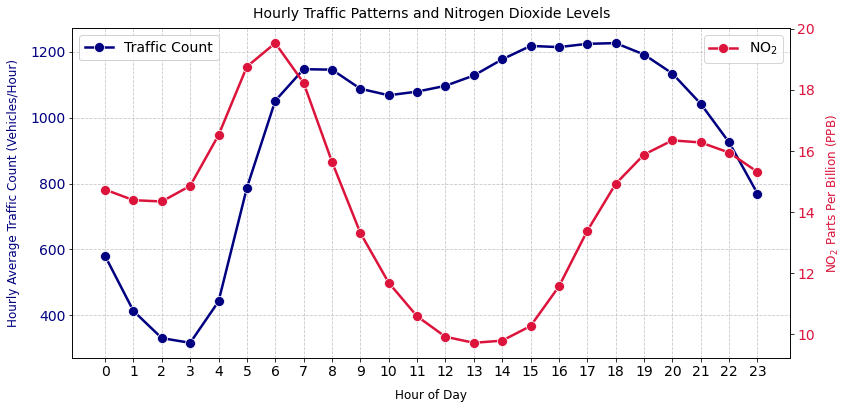

In [0]:
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.lineplot(data=traffic, x="Hour", y="traffic_count", label="Traffic Count", color="navy", linewidth=2.5, ax=ax1, marker="o", markersize=10)
ax1.set_ylabel("Hourly Average Traffic Count (Vehicles/Hour)", color="navy", fontsize=12, labelpad=10)
ax1.tick_params(axis='y', labelcolor="navy")
ax1.set_xlabel("Hour of Day", fontsize=12, labelpad=10)
ax1.set_xticks(range(0, 24)) 
ax1.grid(True, linestyle='--', alpha=0.7)

ax2 = ax1.twinx()
sns.lineplot(data=no2, x="Hour", y="Sample Measurement", label="NO$_2$", color="crimson", linewidth=2.5, ax=ax2, marker="o", markersize=10)
ax2.set_ylabel("NO$_2$ Parts Per Billion (PPB)", color="crimson", fontsize=12, labelpad=10)
ax2.tick_params(axis='y', labelcolor="crimson")

plt.title("Hourly Traffic Patterns and Nitrogen Dioxide Levels", fontsize=14, pad=10, fontweight='normal')

lines1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(lines1 , labels1, loc='upper left', frameon=True, framealpha=0.9)

# ax1.tick_params(labelsize=20)

ax2.ticklabel_format(style='scientific', axis = 'y') 
t = ax.yaxis.get_offset_text()
t.set_size(20)
plt.tight_layout()
plt.subplots_adjust(top=0.9)  
plt.show()


Lets look at this. This is interesting actually. The reason we see sharp increase in NO2 in the morning is people go to their work in their cars. As afternoon approaches, there is full-fledged sunlight everywhere, and NO2 reacts with sunlight to form Ozone. The rate of NO2 disintegration is much higher during the afternoon than the rate at which it is being produces. That is why after ~8 AM in the morning, NO2 starts to go down is is minimum during peak afternoon.

In [0]:
from pyspark.sql.functions import lpad, to_date

In [0]:
# getting EPA NO2 average for each YYYY-MM 
epa_no2 = epa_no2.withColumn("month_str", lpad(col("month").cast("string"), 2, "0"))
epa_no2 = epa_no2.withColumn("year_month", concat_ws("-", col("year").cast("string"), col("month_str")))
EPA_year_month_avg = epa_no2.groupBy("year_month").agg(avg("Sample Measurement").alias("Sample Measurement"))
EPA_year_month_avg = EPA_year_month_avg.withColumn("year_month", to_date("year_month", "yyyy-MM"))

In [0]:
traffic_long.show(5)

+----------+----+-----+---+-----------+----------+--------+-------------+----+
|Station_Id|year|month|day|day_of_week|      date|hour_str|traffic_count|Hour|
+----------+----+-----+---+-----------+----------+--------+-------------+----+
|       180|2019|    1|  1|          3|2019-01-01| hour_00|        606.0|   0|
|       180|2019|    1|  1|          3|2019-01-01| hour_01|        932.0|   1|
|       180|2019|    1|  1|          3|2019-01-01| hour_02|        795.0|   2|
|       180|2019|    1|  1|          3|2019-01-01| hour_03|        645.0|   3|
|       180|2019|    1|  1|          3|2019-01-01| hour_04|        578.0|   4|
+----------+----+-----+---+-----------+----------+--------+-------------+----+
only showing top 5 rows



In [0]:
# it will add 0 string until the value in the row is 2 characters so that we can concatenate Year Month togerther to compute year-month averages
traffic_long = traffic_long.withColumn("month_str", lpad(col("month").cast("string"), 2, "0")) 
traffic_long = traffic_long.withColumn("year_month", concat_ws("-", col("year").cast("string"), col("month_str")))

# calculating avergae traffic per hour per YEAR-MONTH
Traffic_year_month_avg = traffic_long.groupBy("year_month").agg(avg("traffic_count").alias("Average_Traffic_Count"))
Traffic_year_month_avg = Traffic_year_month_avg.withColumn("year_month", to_date("year_month", "yyyy-MM"))

In [0]:
# reverting back to pandas
Traffic_year_month_avg = Traffic_year_month_avg.toPandas()

In [0]:
# reverting back to pandas
EPA_year_month_avg = EPA_year_month_avg.toPandas()

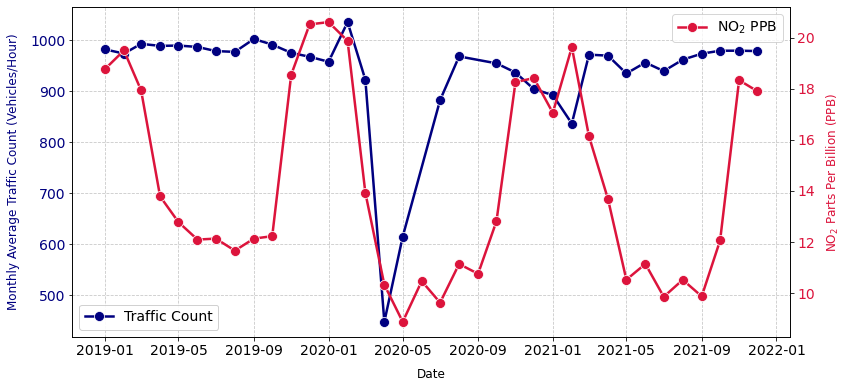

In [0]:
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.lineplot(data=Traffic_year_month_avg, x="year_month", y="Average_Traffic_Count", label="Traffic Count", color="navy", linewidth=2.5, ax=ax1, marker="o", markersize=10)
ax1.set_ylabel("Monthly Average Traffic Count (Vehicles/Hour)", color="navy", fontsize=12, labelpad=10)
ax1.tick_params(axis='y', labelcolor="navy")
ax1.set_xlabel("Date", fontsize=12, labelpad=10)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.ticklabel_format(style='scientific', axis = 'y') 
t = ax1.yaxis.get_offset_text()
t.set_size(20)

ax2 = ax1.twinx()
sns.lineplot(data=EPA_year_month_avg, x="year_month", y="Sample Measurement", label="NO$_2$ PPB", color="crimson", linewidth=2.5, ax=ax2, marker="o", markersize=10)
ax2.set_ylabel("NO$_2$ Parts Per Billion (PPB)", color="crimson", fontsize=12, labelpad=10)
ax2.tick_params(axis='y', labelcolor="crimson")


lines1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(lines1 , labels1, loc='lower left', frameon=True, framealpha=0.9)

ax2.ticklabel_format(style='scientific', axis = 'y') 
t = ax2.yaxis.get_offset_text()
t.set_size(20)
plt.tight_layout()
plt.subplots_adjust(top=0.9)  
plt.show()

Lets look at this. During covid lockdowns in 2020 in NYC which started from March to May (peak), the number of vehcile count is down significantly (more than 50%), and so is the NO2. As the lockdowns eased, the NO2 started recovering and so did the vehicle count.

In [0]:
# lets get average traffic for each hour for each year-month-day. 
# this way, we can join it to hourly EPA data
traffic_long1 = traffic_long.groupBy(["year", "month", "day", "hour"]).agg(avg("traffic_count").alias("Average_Traffic_Count"))

In [0]:
epa_no2.show(5)

+----+-----+---+----+------------------+---------+----------+
|year|month|day|Hour|Sample Measurement|month_str|year_month|
+----+-----+---+----+------------------+---------+----------+
|2019|    1|  1|   0|18.700000286102295|       01|   2019-01|
|2019|    1|  1|   1|             25.25|       01|   2019-01|
|2019|    1|  1|   2| 30.27500009536743|       01|   2019-01|
|2019|    1|  1|   3| 20.47499990463257|       01|   2019-01|
|2019|    1|  1|   4|             15.75|       01|   2019-01|
+----+-----+---+----+------------------+---------+----------+
only showing top 5 rows



In [0]:
# joininng hourly average traffic data with hourly EPA data
joined = epa_no2.join(traffic_long1, on=["year", "month", "day", "Hour"], how="inner")

In [0]:
joined.show(10)

+----+-----+---+----+------------------+---------+----------+---------------------+
|year|month|day|Hour|Sample Measurement|month_str|year_month|Average_Traffic_Count|
+----+-----+---+----+------------------+---------+----------+---------------------+
|2019|    1|  5|  10|             10.75|       01|   2019-01|   1188.1666666666667|
|2019|    1|  6|   2|11.975000023841858|       01|   2019-01|    438.9166666666667|
|2019|    1| 12|   2|14.174999952316284|       01|   2019-01|                414.0|
|2019|    1| 21|  12| 8.025000095367432|       01|   2019-01|   1070.6666666666667|
|2019|    2|  4|   2|45.166666666666664|       02|   2019-02|               263.75|
|2019|    2| 28|  23|15.725000381469727|       02|   2019-02|    754.5833333333334|
|2019|    2|  8|   8|29.866666158040363|       02|   2019-02|   1289.6666666666667|
|2019|    2| 12|  15|17.266666730244953|       02|   2019-02|   1030.2222222222222|
|2019|    3| 14|  12|11.650000095367432|       03|   2019-03|   1062.0833333

In [0]:
from scipy.stats import pearsonr

In [0]:
# converting to pandas dataframe for plotting and correlation calculation
joined = joined.toPandas()

In [0]:
joined.head()

,year,month,day,Hour,Sample Measurement,month_str,year_month,Average_Traffic_Count
0,2019,1,5,10,10.750000,01,2019-01,1188.166667
1,2019,1,6,2,11.975000,01,2019-01,438.916667
2,2019,1,12,2,14.175000,01,2019-01,414.000000
3,2019,1,21,12,8.025000,01,2019-01,1070.666667
4,2019,2,4,2,45.166667,02,2019-02,263.750000


In [0]:
# getting correlation between traffic and EPA NO2 for each hour
hourly_correlations = []
for hour in range(24):
    temp_df = joined[joined["Hour"] == hour].copy()
    correlation = temp_df[["Sample Measurement", "Average_Traffic_Count"]].corr(method="pearson").iloc[0, 1]
    hourly_correlations.append(correlation)

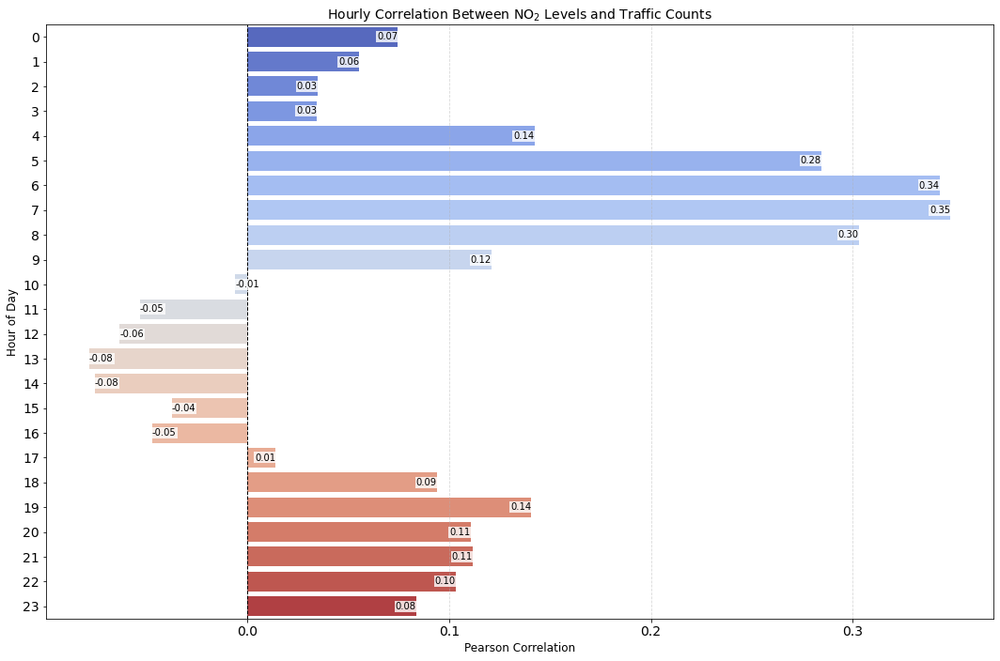

In [0]:
plt.figure(figsize=(15, 10))
ax = sns.barplot(x=hourly_correlations, y=list(range(24)), palette="coolwarm", orient="h")

for i, correlation in enumerate(hourly_correlations):
    ax.text(correlation, i, f"{correlation:.2f}", va='center', ha='left' if correlation < 0 else 'right', 
            color="black", fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))

plt.xlabel("Pearson Correlation", fontsize=12)
plt.ylabel("Hour of Day", fontsize=12)
plt.title("Hourly Correlation Between NO$_2$ Levels and Traffic Counts", fontsize=14)
plt.axvline(0, color="black", linestyle="--", linewidth=1) 
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

If we look at morining peak/rush hours, the correlation is slightly higher. It goes down later and also starts to pick slightly during the late evening. This is due to photochemistry.  Also, it is not within the scope of the project to identify the magnitute of emission of NO2 based on traffic alone. As, there can be multiple NO2 emission sources besides fossil fuel burning in the nearby area.

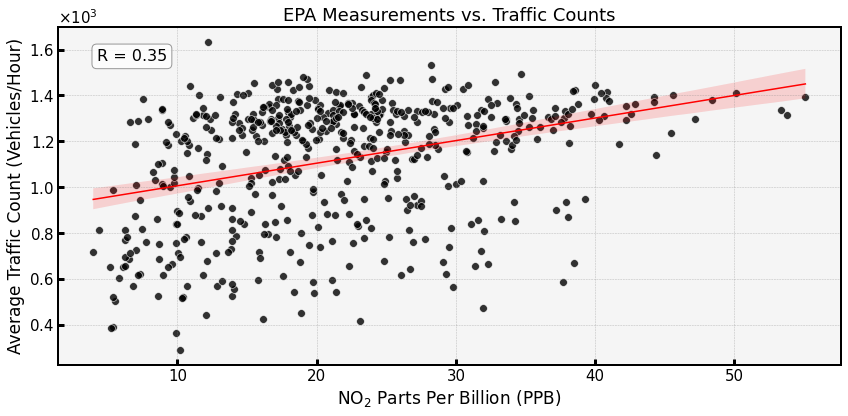

In [0]:
# I selected these combinations as they are peak hours and during winter months, NO2 is generally higher.
hour_combination = [6, 7, 8]
month_combination = [10, 11, 12, 1, 2, 3]
year_combination = [2020, 2021, 2019]

joined1 = joined[(joined.Hour.isin(hour_combination)) & (joined.month.isin(month_combination)) & (joined.year.isin(year_combination))].copy()
joined1 = joined1.groupby(["year", "month", "day"])[["Sample Measurement", "Average_Traffic_Count"]].mean().reset_index()
corr, __annotations__ = pearsonr(joined1["Sample Measurement"], joined1["Average_Traffic_Count"])

fig, ax = plt.subplots(figsize=(12, 6))

scatter = sns.scatterplot(ax=ax, data=joined1, x="Sample Measurement", y="Average_Traffic_Count", color="black", alpha=0.8, s=60)
ax.text(0.05, 0.9, f'R = {corr:.2f}', transform=ax.transAxes, fontsize=16, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round'))
ax.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
ax.set_facecolor('whitesmoke')  

# this is the regression line
sns.regplot(data=joined1, x="Sample Measurement", y="Average_Traffic_Count", scatter=False, color='red', line_kws={'linewidth': 1.5}, ax=ax)

for spine in ax.spines.values():
    spine.set_edgecolor('gray')
    spine.set_linewidth(0.8)

ax.tick_params(labelsize=15)
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_color('black') 
ax.spines['right'].set_color('black')
ax.spines['right'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_color('black')
ax.spines['left'].set_lw(2) 
ax.tick_params(which='both', width=3)
ax.tick_params(which='major', length=6)
ax.grid(True, linestyle="--", alpha=0.5)
ax.tick_params(which='minor', length=6)
ax.tick_params(which = 'both', direction = 'in')
ax.yaxis.set_major_formatter(formatter)
ax.ticklabel_format(style='scientific', axis = 'y') 
t = ax.yaxis.get_offset_text()
t.set_size(15)
ax.set_xlabel("NO$_2$ Parts Per Billion (PPB)", fontsize=17)
ax.set_ylabel("Average Traffic Count (Vehicles/Hour)", fontsize=17)
ax.set_title("EPA Measurements vs. Traffic Counts", fontsize=18)
plt.tight_layout()
plt.show()

Again, the correlation is not strong as there are more sources of NO2 around the selected reason. Given that NYC was choosen for this study, given the number of sources for NO2 pollution in such high population density region, it becomes impossible to quantify the amount of NO2  released in the atmosphere solely by the vehicle count. This is not possible within the scope of this project.

## 3. Isolated FHA Station Traffic Frequency vs EPA NO2

Instead of choosing such densely populated area like NYC, I decided to conduct this experiment one more time. I choose a relatively remote area in the map and selected nearest EPA sensor to the remote FHA station. This is the most accurate way to quantify the NO2 emission purely with traffic frequency posssible in this study.

In [0]:
from shapely.geometry import box

# this is the new zoomed in bounding box for the remote EPA FHA stations
min_lon_isolated, min_lat_isolated = -77, 41
max_lon_isolated, max_lat_isolated = -75, 42
EPA_FHA_bounding_box = box(min_lon_isolated, min_lat_isolated, max_lon_isolated, max_lat_isolated)
EPA_FHA_bounding_box = gpd.GeoDataFrame(index=[0], crs="EPSG:4326", geometry=[EPA_FHA_bounding_box])

In [0]:
# Step 1: Project to meters
gdf_meters = gpd.GeoDataFrame(index=[0], geometry =[Point((-76.5, 41.7))], crs="EPSG:4326").to_crs(epsg=32618)
gdf_meters["geometry"] = gdf_meters.buffer(15000)
gdf_with_buffer = gdf_meters[["geometry"]].set_geometry("geometry").to_crs(epsg=4326)
gdf_with_buffer

,geometry
0,"POLYGON ((-76.31978 41.70221, -76.32037 41.688..."


In [0]:
# only selecting epa stations in the boundibg box
selected_epa_station = unique_epa_stations.sjoin(gdf_with_buffer, predicate="within")
selected_epa_station

,Site Num,Latitude,Longitude,geometry,index_right
35,11,41.705227,-76.512726,POINT (-76.51273 41.70523),0


In [0]:
# only selecting FHA station in the bounding box
selected_FHW_station = station_data_2019.sjoin(gdf_with_buffer, predicate="within")
selected_FHW_station = selected_FHW_station[["Station_Id", "geometry"]].drop_duplicates()
selected_FHW_station = selected_FHW_station.reset_index(drop=True)
selected_FHW_station

,Station_Id,geometry
0,000005,POINT (-76.44277 41.79339)


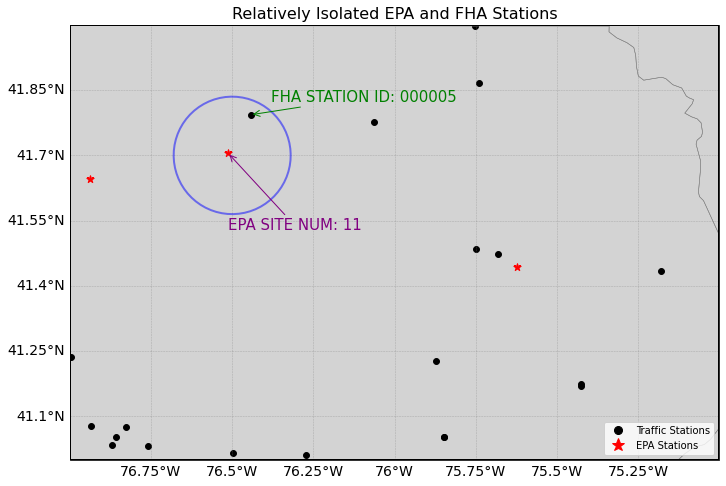

In [0]:
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([min_lon_isolated, max_lon_isolated, min_lat_isolated, max_lat_isolated], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=0.5)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# Plot Maryland boundary
EPA_FHA_bounding_box.geometry.boundary.plot(ax=ax, color='black', linewidth=2, alpha=1, transform=ccrs.PlateCarree())

station_data_2019.plot(ax=ax, color='black', markersize=35, alpha=1, label="Traffic Stations")
station_legend = [Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='black',
                                          markeredgecolor='black', label='Traffic Stations', markersize=8)]

for idx, (i, row) in enumerate(selected_FHW_station.iterrows()):
    ax.annotate(
        "FHA STATION ID: " + str(row["Station_Id"]),
        xy=(row.geometry.x, row.geometry.y),
        xytext=(20, 10),
        textcoords="offset points",
        fontsize=15,
        color='green',
        ha='left',
        va='bottom',
        arrowprops=dict(arrowstyle="->", color='green', lw=1)
    )


unique_epa_stations.plot(ax=ax, color='red', markersize=60, alpha=1, label="EPA Stations", marker="*")
epa_legend = Line2D([0], [0], marker='*', linestyle='None', markerfacecolor='red',
                                          markeredgecolor='red', label='EPA Stations', markersize=13.5)

for idx, row in selected_epa_station.iterrows():
    ax.annotate(
        "EPA SITE NUM: " + str(row["Site Num"]),
        xy=(row.geometry.x, row.geometry.y),
        xytext=(0, -80),  # Larger offset for more separation (pixels)
        textcoords="offset points",
        fontsize=15,
        color='purple',
        ha='left',
        va='bottom',
        arrowprops=dict(arrowstyle="->", color='purple', lw=1)
    )

gdf_with_buffer.geometry.boundary.plot(ax=ax, color='blue', linewidth=2, alpha=0.5)

station_legend.append(epa_legend)
ax.legend(handles=station_legend, loc='lower right', fontsize=10, frameon=True)
plt.title("Relatively Isolated EPA and FHA Stations", fontsize=16)
plt.show()

In [0]:
selected_FHW_station

,Station_Id,geometry
0,000005,POINT (-76.44277 41.79339)


In [0]:
selected_epa_station

,Site Num,Latitude,Longitude,geometry,index_right
35,11,41.705227,-76.512726,POINT (-76.51273 41.70523),0


Now that we know the ID of the isolated EPA and FHA station, I will filter the original dataframes to get data for these two stations only.

In [0]:
# this is our concatenated epa data 
epa_no2 = epa_2019_spark_df.union(epa_2020_spark_df).union(epa_2021_spark_df)
epa_no2.show()

+--------+----------+----------+----+----------+--------+---------+---------+------------------+
|Site Num|Date Local|Time Local|Hour|  Date GMT|Time GMT| Latitude|Longitude|Sample Measurement|
+--------+----------+----------+----+----------+--------+---------+---------+------------------+
|    9003|2019-01-01|     00:00|   0|2019-01-01|   05:00|41.118332|-73.33667|               2.3|
|    9003|2019-01-01|     01:00|   1|2019-01-01|   06:00|41.118332|-73.33667|               3.8|
|    9003|2019-01-01|     02:00|   2|2019-01-01|   07:00|41.118332|-73.33667|               6.7|
|    9003|2019-01-01|     03:00|   3|2019-01-01|   08:00|41.118332|-73.33667|              10.4|
|    9003|2019-01-01|     04:00|   4|2019-01-01|   09:00|41.118332|-73.33667|               8.3|
|    9003|2019-01-01|     05:00|   5|2019-01-01|   10:00|41.118332|-73.33667|               8.4|
|    9003|2019-01-01|     06:00|   6|2019-01-01|   11:00|41.118332|-73.33667|               7.1|
|    9003|2019-01-01|     07:0

In [0]:
# 11 is the isolated EPA station id as shown in the previous geodataframe
epa_isolated = epa_no2.filter(col("Site Num") == 11)
epa_isolated.show(5)

+--------+----------+----------+----+----------+--------+--------+----------+------------------+
|Site Num|Date Local|Time Local|Hour|  Date GMT|Time GMT|Latitude| Longitude|Sample Measurement|
+--------+----------+----------+----+----------+--------+--------+----------+------------------+
|      11|2019-01-01|     00:00|   0|2019-01-01|   05:00|40.46218|-74.429436|               4.7|
|      11|2019-01-01|     01:00|   1|2019-01-01|   06:00|40.46218|-74.429436|               5.9|
|      11|2019-01-01|     02:00|   2|2019-01-01|   07:00|40.46218|-74.429436|              11.8|
|      11|2019-01-01|     03:00|   3|2019-01-01|   08:00|40.46218|-74.429436|               5.3|
|      11|2019-01-01|     04:00|   4|2019-01-01|   09:00|40.46218|-74.429436|               2.9|
+--------+----------+----------+----+----------+--------+--------+----------+------------------+
only showing top 5 rows



In [0]:
# only selecting station data where station id is 11 (our isolated FHA station)
traffic_df_2019_isolated = traffic_df_2019.filter(col("Station_Id") == "000005")
traffic_df_2020_isolated = traffic_df_2020.filter(col("Station_Id") == "000005")

I excluded 2021 data because, for this particular FHA station, there seems to be data missing.

In [0]:
# concatentating all FHA isolated station data together
traffic_isolated = traffic_df_2019_isolated.union(traffic_df_2020_isolated)

In [0]:
# melt the combined dataframe from wide format to row format
traffic_isolated = traffic_isolated.melt(
    ids=['Station_Id', 'year', 'month', 'day'], 
    values=[f'hour_{h:02d}' for h in range(24)],
    variableColumnName='hour_str',
    valueColumnName='traffic_count'
)

In [0]:
# extract hour
traffic_isolated = traffic_isolated.withColumn('Hour', regexp_extract('hour_str', r'hour_(\d+)', 1).cast('int'))

In [0]:
# convert Date Local from string to date format
epa_isolated = epa_isolated.withColumn("Date Local", to_date("Date Local", "yyyy-MM-dd"))
epa_isolated = epa_isolated.withColumn("year", year("Date Local"))
epa_isolated = epa_isolated.withColumn("month", month("Date Local")) 
epa_isolated = epa_isolated.withColumn("day", dayofmonth("Date Local"))

In [0]:
epa_isolated.show(1)

+--------+----------+----------+----+----------+--------+--------+----------+------------------+----+-----+---+
|Site Num|Date Local|Time Local|Hour|  Date GMT|Time GMT|Latitude| Longitude|Sample Measurement|year|month|day|
+--------+----------+----------+----+----------+--------+--------+----------+------------------+----+-----+---+
|      11|2019-01-01|     00:00|   0|2019-01-01|   05:00|40.46218|-74.429436|               4.7|2019|    1|  1|
+--------+----------+----------+----+----------+--------+--------+----------+------------------+----+-----+---+
only showing top 1 row



In [0]:
epa_isolated = epa_isolated.select(["year", "month", "day", "Hour", "Sample Measurement"])

In [0]:
epa_isolated.show()

+----+-----+---+----+------------------+
|year|month|day|Hour|Sample Measurement|
+----+-----+---+----+------------------+
|2019|    1|  1|   0|               4.7|
|2019|    1|  1|   1|               5.9|
|2019|    1|  1|   2|              11.8|
|2019|    1|  1|   3|               5.3|
|2019|    1|  1|   4|               2.9|
|2019|    1|  1|   5|               2.6|
|2019|    1|  1|   6|               2.9|
|2019|    1|  1|   7|               2.7|
|2019|    1|  1|   8|               2.3|
|2019|    1|  1|   9|               2.1|
|2019|    1|  1|  10|               2.0|
|2019|    1|  1|  11|               1.8|
|2019|    1|  1|  12|               1.9|
|2019|    1|  1|  13|               1.4|
|2019|    1|  1|  14|               1.4|
|2019|    1|  1|  15|               1.6|
|2019|    1|  1|  16|               2.0|
|2019|    1|  1|  17|               2.3|
|2019|    1|  1|  18|               2.8|
|2019|    1|  1|  19|               4.4|
+----+-----+---+----+------------------+
only showing top

In [0]:
# join the traffic and epa dataframes where we have hourly data on both sides
combined_isolated_df = traffic_isolated.join(epa_isolated, on=["year", "month", "day", "Hour"], how="inner")

In [0]:
combined_isolated_df.show(5)

+----+-----+---+----+----------+--------+-------------+------------------+
|year|month|day|Hour|Station_Id|hour_str|traffic_count|Sample Measurement|
+----+-----+---+----+----------+--------+-------------+------------------+
|2019|    2|  4|   2|    000005| hour_02|          0.0|              24.3|
|2019|    2|  8|   8|    000005| hour_08|        360.0|              21.0|
|2019|    2| 12|  15|    000005| hour_15|        252.0|              17.7|
|2019|    2| 28|  23|    000005| hour_23|         51.0|              19.9|
|2019|    3| 14|  12|    000005| hour_12|        313.0|               7.7|
+----+-----+---+----+----------+--------+-------------+------------------+
only showing top 5 rows



In [0]:
# i've selected these combinations as they are peak hours for traffic and peak months for NO2
hour_combination = [0, 1, 2, 3, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 24, 23]
month_combination = [1, 2, 3, 4]
year_combination = [2020, 2021, 2019]

In [0]:
# selecting only rows for the above condition
finaliized_dataframe = combined_isolated_df.filter((col("Hour").isin(hour_combination)) & (col("month").isin(month_combination)) & (col("year").isin(year_combination)))

In [0]:
# getting Year-Month-Day average EPA NO2 and average traffic count
finaliized_dataframe = finaliized_dataframe.groupBy("year", "month", "day").agg(avg("Sample Measurement")\
                        .alias("average_EPA_NO2"), avg("traffic_count").alias("averaege_traffic"))

In [0]:
finaliized_dataframe = finaliized_dataframe.toPandas() # reverting back to pandas dataframe

In [0]:
corr, _ = pearsonr(finaliized_dataframe["average_EPA_NO2"], finaliized_dataframe["averaege_traffic"])
print(f"Correlation between average EPA NO2 and average traffic count: {corr:.2f}")

Correlation between average EPA NO2 and average traffic count: 0.50


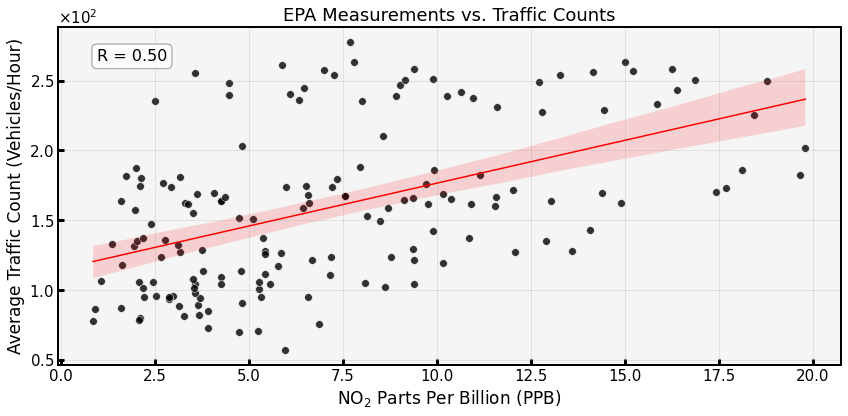

In [0]:
fig, ax = plt.subplots(figsize=(12, 6))
scatter = sns.scatterplot(ax=ax, data=finaliized_dataframe, x="average_EPA_NO2", y="averaege_traffic", color="black", alpha=0.8, s=60)
ax.text(0.05, 0.9, f'R = {corr:.2f}', transform=ax.transAxes, fontsize=16, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round'))

ax.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
ax.set_facecolor('whitesmoke')  

sns.regplot(data=finaliized_dataframe, x="average_EPA_NO2", y="averaege_traffic", scatter=False, color='red', line_kws={'linewidth': 1.5}, ax=ax)

for spine in ax.spines.values():
    spine.set_edgecolor('gray')
    spine.set_linewidth(0.8)

ax.tick_params(labelsize=15)
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_color('black') 
ax.spines['right'].set_color('black')
ax.spines['right'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_color('black')
ax.spines['left'].set_lw(2) 
ax.tick_params(which='both', width=3)
ax.tick_params(which='major', length=6)
ax.grid(True, linestyle="--", alpha=0.5)
ax.tick_params(which='minor', length=6)
ax.tick_params(which = 'both', direction = 'in')
ax.yaxis.set_major_formatter(formatter)
ax.ticklabel_format(style='scientific', axis = 'y') 
t = ax.yaxis.get_offset_text()
t.set_size(15)
ax.set_xlabel("NO$_2$ Parts Per Billion (PPB)", fontsize=17)
ax.set_ylabel("Average Traffic Count (Vehicles/Hour)", fontsize=17)
ax.set_title("EPA Measurements vs. Traffic Counts", fontsize=18)
plt.tight_layout()
plt.show()

The correlation is slightly higher for this relatively isolated station. This is the most optimal comparision we can do within the scope of this project. But, it would be interesting to see how traffic purely affects NO2, which can be done in the future experiments.

# Conclusion

The correlation increased at daily level slightly for the isolated stations. Still, it is very difficult to seperate out NO2 emitted by traffic sources. Regardless, we can see that there is a linear relationship between the traffic frequency and NO2. We used NO2 data from both ground based measurements and satellite measurements to identify trends, and relationship with traffic frequency count. 

I used GeoPandas for spatial operations, which can be replaced with Apache Sedona to fully remain on Apache ecosystem. Furthermore, it is also better to use Sedona when I have 100s of GBs of spatial data that I need to work with. GeoPandas will become a bottleneck at that point.